In [311]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.impute import KNNImputer
from sklearn.feature_selection import SelectKBest, f_regression, RFE, SelectFromModel
import seaborn as sns


# **TASK 1. Load and explore the dataset, visualizing the results of the exploration. Analyze the quality of the dataset and handle eventual quality issues.**

In [312]:
data = pd.read_csv('weight_change_dataset.csv')

In [397]:
(data)

,Age,Gender,BMR (Calories),Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change (lbs),Duration (weeks),Smoking,Physical Activity Level,Sleep Quality,Stress Level,Work Sector,Final Weight (lbs)
1,46.0,M,2275.50,3823.00,1547.50,-1.224,6.0,False,Very Active,Excellent,6,Public,167.80
2,32.0,M,2119.40,2785.40,666.00,-0.426,7.0,True,Sedentary,Good,3,Self-Employed,144.20
3,25.0,M,2181.30,2587.30,406.00,3.370,8.0,False,Sedentary,Fair,2,Private,146.30
4,38.0,M,2463.80,3312.80,849.00,3.900,10.0,False,Lightly Active,Good,1,Unemployed,157.50
10,35.6,M,2839.10,4000.00,1160.90,2.320,5.0,False,Very Active,Poor,5,Self-Employed,189.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,39.0,F,2526.30,3557.27,1030.97,-12.840,4.0,False,Lightly Active,Good,5,Unemployed,166.73
596,41.0,F,2699.57,3546.90,847.33,4.580,8.0,False,Moderately Active,Good,6,Public,188.03
597,39.0,M,2651.40,3393.60,742.20,-7.530,9.0,False,Lightly Active,Fair,5,Private,189.50
598,41.0,F,2230.70,3442.70,1212.00,4.610,6.0,False,Lightly Active,Fair,4,Self-Employed,159.03


In [314]:
print(data.info())
print(f"Number of (rows,columns)\n{data.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Participant ID                 600 non-null    int64  
 1   Age                            600 non-null    int64  
 2   Gender                         600 non-null    object 
 3   BMR (Calories)                 600 non-null    float64
 4   Daily Calories Consumed        544 non-null    float64
 5   Daily Caloric Surplus/Deficit  540 non-null    float64
 6   Weight Change (lbs)            544 non-null    float64
 7   Duration (weeks)               600 non-null    int64  
 8   Smoking                        600 non-null    object 
 9   Physical Activity Level        600 non-null    object 
 10  Sleep Quality                  600 non-null    object 
 11  Stress Level                   600 non-null    int64  
 12  Work Sector                    540 non-null    obj

In [315]:
# Drop the Participant ID column
data = data.drop('Participant ID', axis=1)

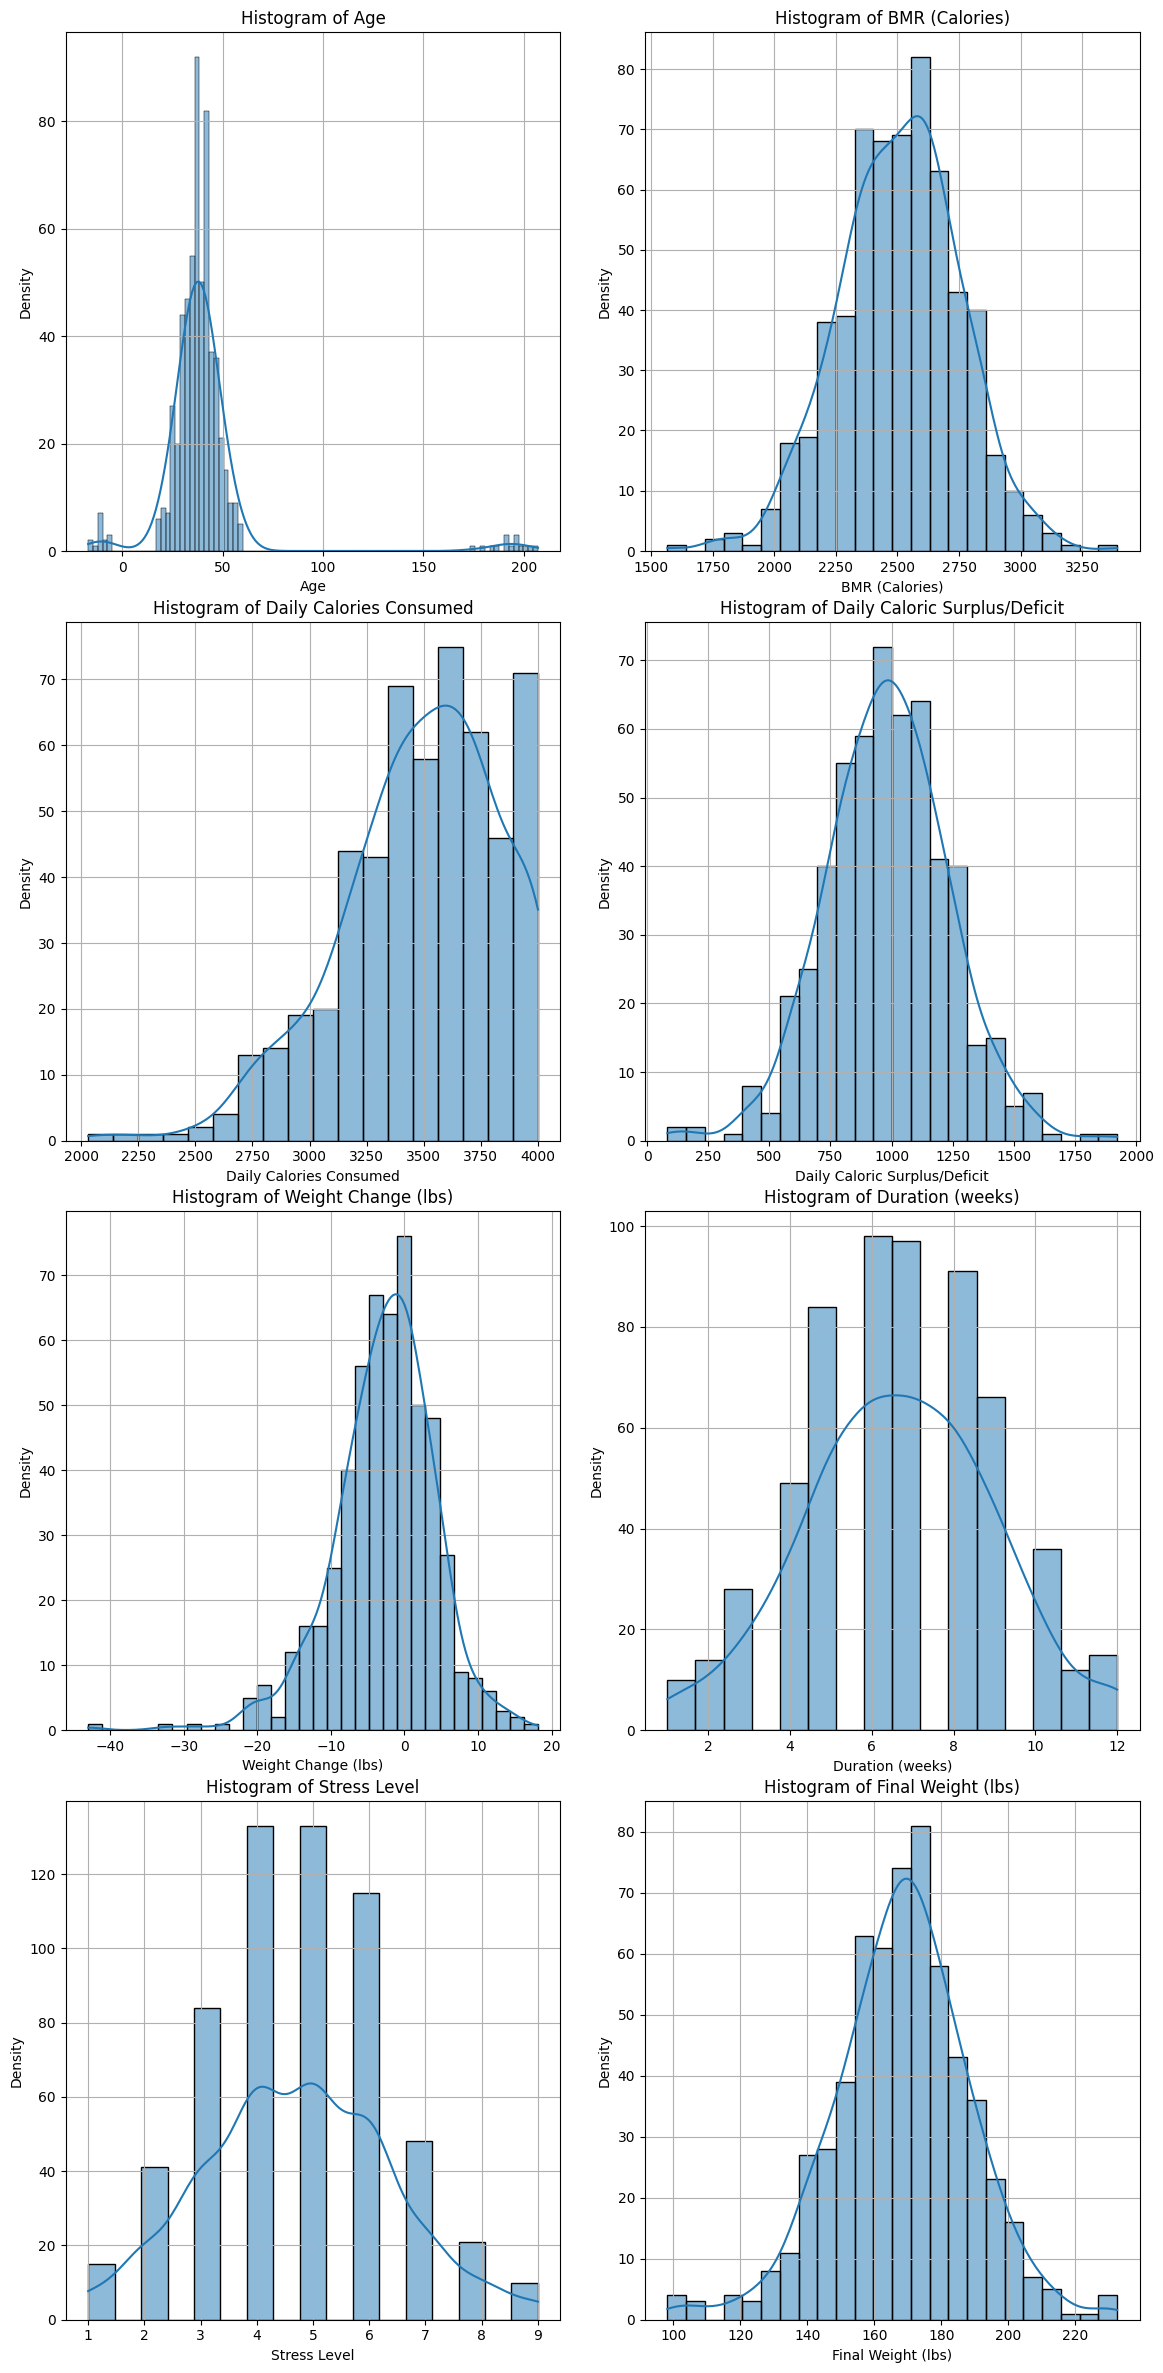

In [316]:
#plot all the numerical columns

numerical_columns = data.select_dtypes(include=['int', 'float'])

# Determine the number of rows and columns for subplots
num_cols = numerical_columns.shape[1]
num_rows = num_cols // 2 + num_cols % 2  

fig, axes = plt.subplots(num_rows, 2, figsize=(12, 6*num_rows))
fig.tight_layout(pad=3.0)

# Loop through each numerical column and create a histogram
for i, column in enumerate(numerical_columns.columns):
    row_idx = i // 2
    col_idx = i % 2
    ax = axes[row_idx, col_idx]

    sns.histplot(data[column], kde=True, ax=ax)
    ax.set_title(f'Histogram of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.grid('on')

plt.show()

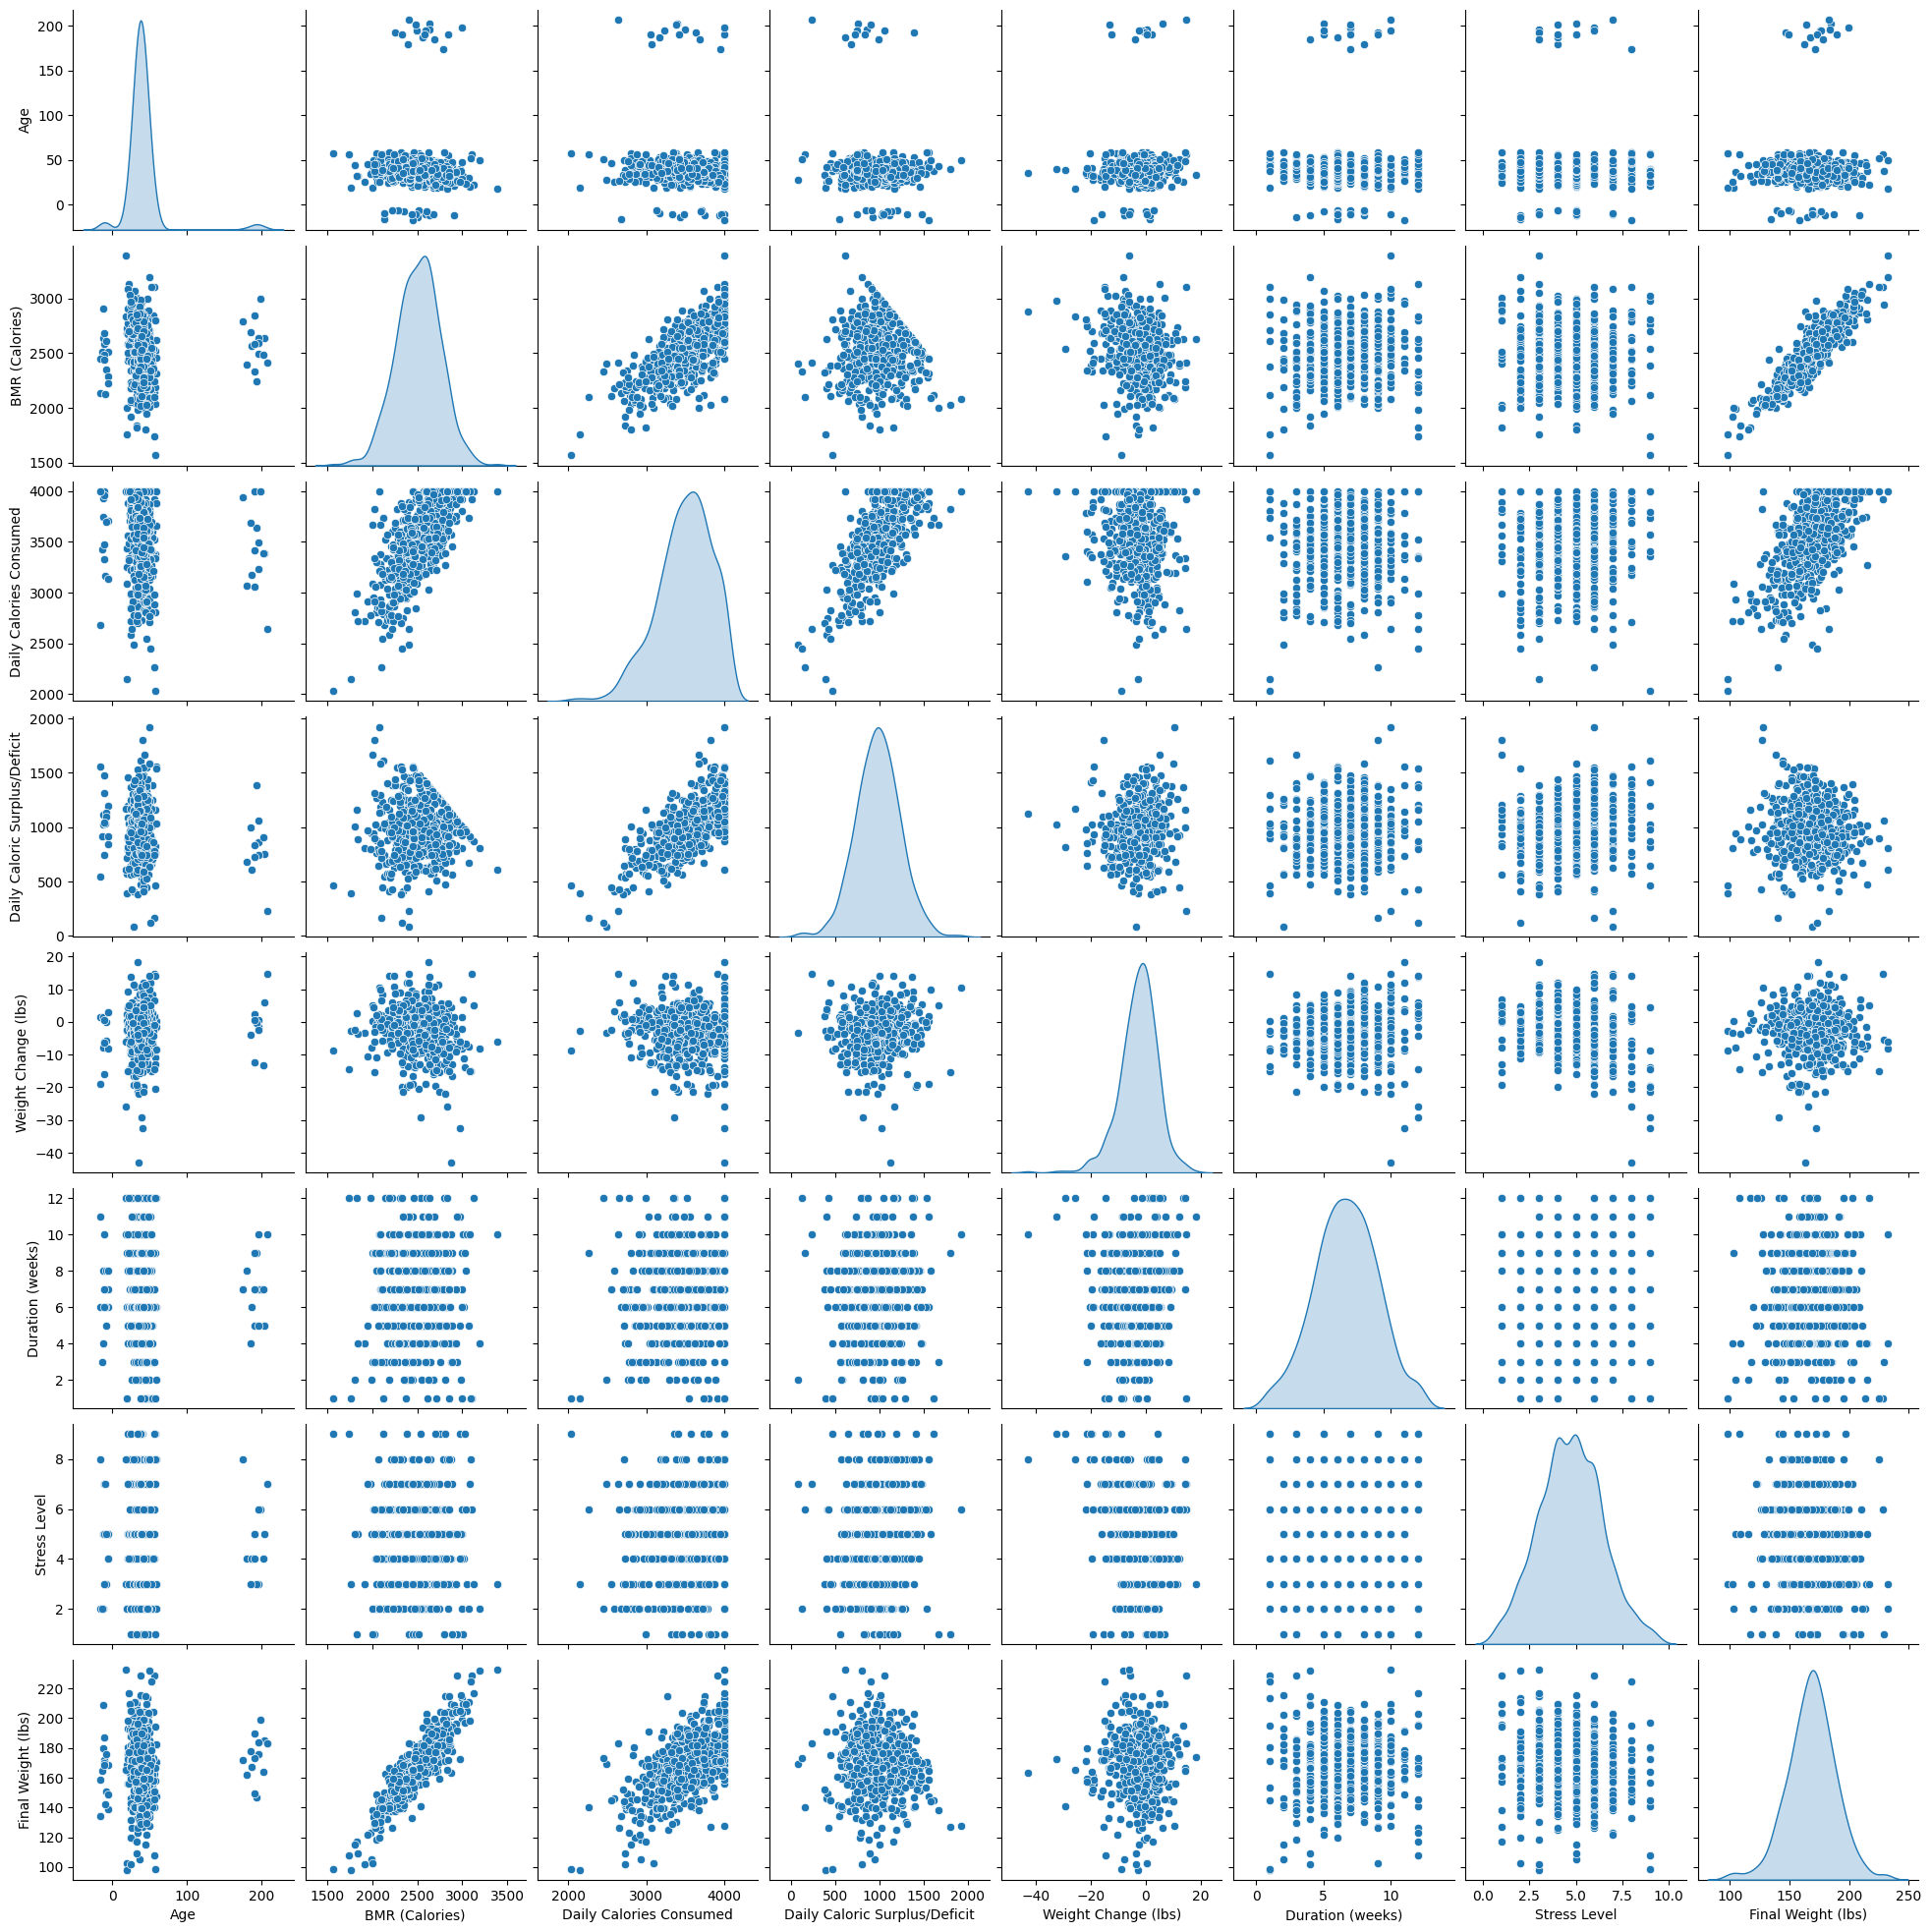

In [317]:
#plot all the numerical columns with kde
sns.pairplot(data=data, kind='scatter',diag_kind='kde')

In this first part of analysis the dataset is being explored, so it is possible to see how is it composed, how many values it has and how they are related each other.

Handling quality issues

Age                               0
Gender                            0
BMR (Calories)                    0
Daily Calories Consumed          56
Daily Caloric Surplus/Deficit    60
Weight Change (lbs)              56
Duration (weeks)                  0
Smoking                           0
Physical Activity Level           0
Sleep Quality                     0
Stress Level                      0
Work Sector                      60
Final Weight (lbs)                0
dtype: int64


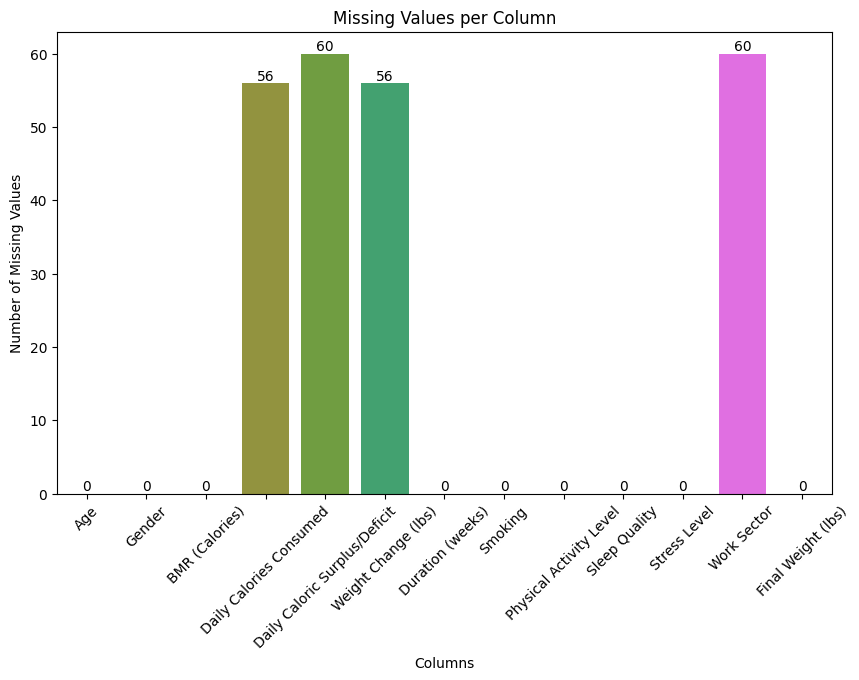

In [318]:
#Check the missing values of each column

missing_values = data.isnull().sum()

palette = sns.color_palette("husl", len(missing_values))

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=missing_values.index, y=missing_values.values, hue=missing_values.index, palette=palette, dodge=False, legend=False)
plt.title("Missing Values per Column")
plt.xticks(rotation=45)
plt.ylabel("Number of Missing Values")
plt.xlabel("Columns")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

print(missing_values)

In [319]:
#Check the unique values of each column (except for the excluded columns)

excluded_columns = ['Final Weight (lbs)', 'BMR (Calories)', 
                    'Daily Calories Consumed', 'Daily Caloric Surplus/Deficit', 'Weight Change (lbs)']

for column in data.columns:
  if column not in excluded_columns:
    print(f"Column: {column}")
    print(data[column].unique())
    print("-" * 20)

Column: Age
[ 56  46  32  25  38  36  40  28 191  53  57  41  20  39  19  47  55  50
  29  42  44  59  45  33  54 174  26  35  21  31  43  37  24  52  34 -11
  48  30 180 203 196  49  23 187 -12  27  22 -16 195 193 -14  -6 198  51
  -8  58 -17  18 207 -10 202 185]
--------------------
Column: Gender
['M' '-' 'F']
--------------------
Column: Duration (weeks)
[ 1  6  7  8 10  9  2 11  5  3  4 12]
--------------------
Column: Smoking
['-' 'Yes']
--------------------
Column: Physical Activity Level
['Sedentary' 'Very Active' 'Lightly Active' 'Moderately Active']
--------------------
Column: Sleep Quality
['Excellent' 'Good' 'Fair' 'Poor' 'Very Good']
--------------------
Column: Stress Level
[6 3 2 1 5 9 7 4 8]
--------------------
Column: Work Sector
['Public' 'Self-Employed' 'Private' 'Unemployed' nan]
--------------------


After print the unique values in the dataset (of the feautures that do not concern calories and weight), is visible that the Age has many impossible values (negavite or too high), to they are outliers that will be imputed.
In the gender has clearly one nosense character, the '-' that has to be substitute into 'M' or 'F'.
Duration is ok.
Smoking the values will be substituite.
Physical Activity Level is ok.
Sleep Quality there is the value 'Very Good' that is not permitted has the guideline says.
Stress Level is ok.
Work Sector is also ok.

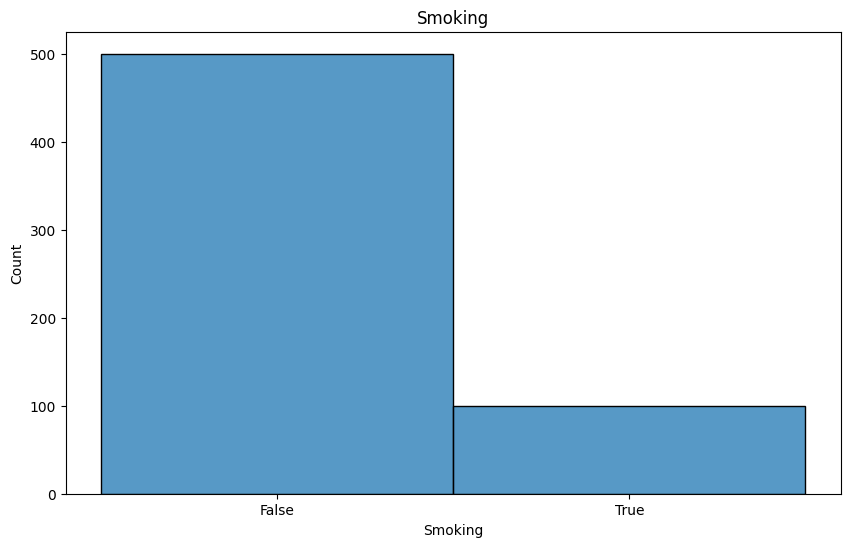

In [320]:
#Handling the Smoking column, setting True and False instead of Yes and -

data.loc[data['Smoking'] == 'Yes', 'Smoking'] = ('True')
data.loc[data['Smoking'] == '-', 'Smoking'] = ('False')

plt.figure(figsize=(10, 6))
sns.histplot(data['Smoking'])
plt.title('Smoking')
plt.show()

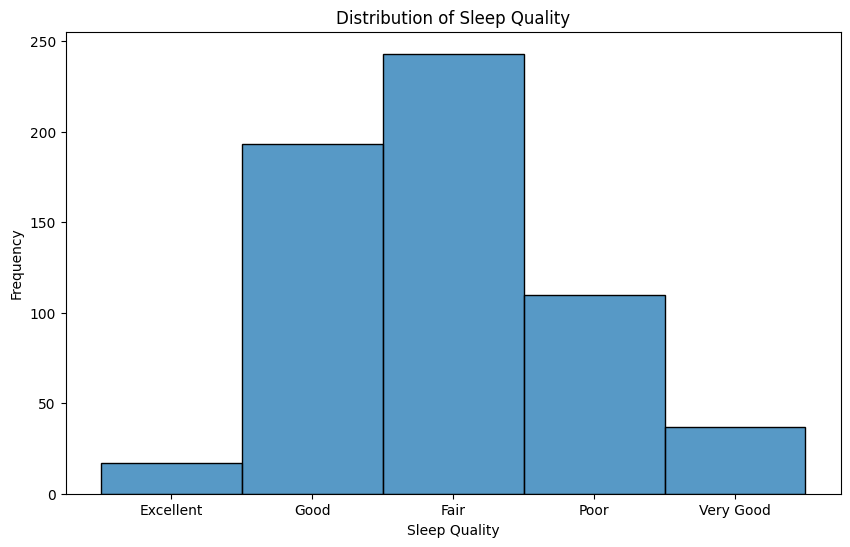

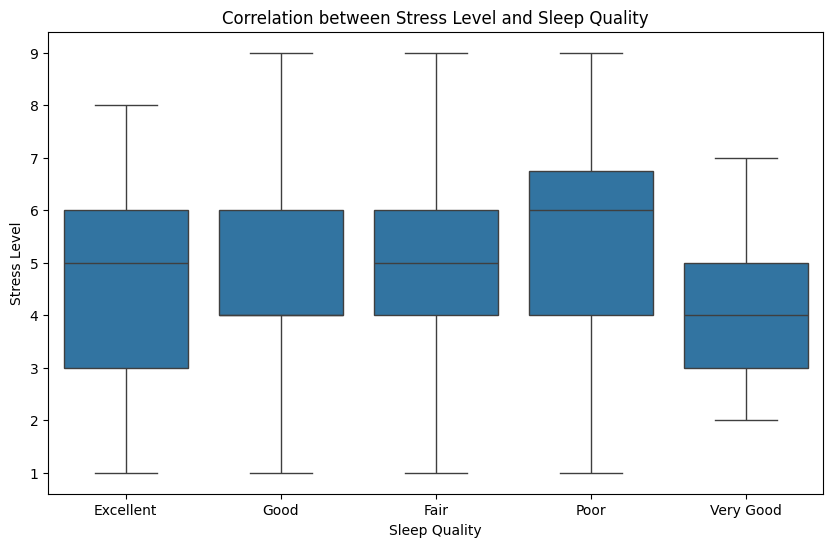

In [321]:
#in sleep quality must be only Good, Fair, Poor, Excellent
plt.figure(figsize=(10, 6))
sns.histplot(data['Sleep Quality'])
plt.title('Distribution of Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Frequency')
plt.show()

#plot the correlation between sleep quality and stress level
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sleep Quality', y='Stress Level', data=data)
plt.title('Correlation between Stress Level and Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Stress Level')
plt.show()

Number of NaN values in Sleep Quality column: 37
Number of NaN values in Sleep Quality column after filling: 0


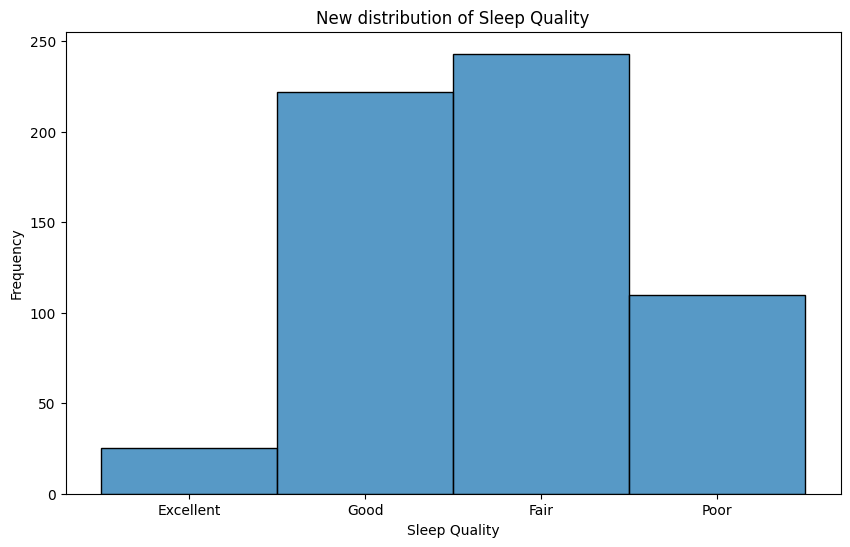

In [322]:
#Define valid sleep quality values and replace the invalid ones with NaN and then filling them with Good and Excellent based on the stress level
valid_sleep_quality = ['Poor', 'Fair', 'Good', 'Excellent']

#Replace invalid values with NaN 
data.loc[:, 'Sleep Quality'] = data['Sleep Quality'].apply(lambda x: x if x in valid_sleep_quality else np.nan)

#Print number of NaN values in Sleep Quality column after cleaning
print(f"Number of NaN values in Sleep Quality column: {data['Sleep Quality'].isna().sum()}")

#Calculate the median stress level
median_stress_level = data['Stress Level'].median()

#Create mask for NaN values
nan_mask = data['Sleep Quality'].isna()

#Fill NaN values based on stress level
data.loc[nan_mask & (data['Stress Level'] <= median_stress_level), 'Sleep Quality'] = 'Good'
data.loc[nan_mask & (data['Stress Level'] > median_stress_level), 'Sleep Quality'] = 'Excellent'

print(f"Number of NaN values in Sleep Quality column after filling: {data['Sleep Quality'].isna().sum()}")

plt.figure(figsize=(10, 6))
sns.histplot(data['Sleep Quality'])
plt.title('New distribution of Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Frequency')
plt.show()

Smoking is now 'True' or 'False'.
The values where was present 'Very good' in sleep quality, are substituted to 'Excellent' or 'Good', based on the stress level. 
The 'Gender' will be fixed after the adjustment of the BMR (Calories) feature, because being 'M' or 'F' will be based on the proximity to the median of that feature for males and females.

Handling outliers

In [323]:
#See how many outliers are in the dataset for the numeric columns, and if are less then 10% of the data remove them)

# Define numeric columns (excluding ID and categorical columns)
numeric_columns = ['BMR (Calories)', 'Daily Calories Consumed', 
                  'Daily Caloric Surplus/Deficit', 'Weight Change (lbs)',
                  'Final Weight (lbs)']

# Calculate Q1, Q3 and IQR for each numeric column
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Create a mask for rows that are not outliers
mask = ~((data[numeric_columns] < (Q1 - 1.5 * IQR)) | 
         (data[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)

# Calculate number of outliers
num_outliers = len(data) - mask.sum()
print(f"Number of rows with outliers: {num_outliers}")

# Only remove outliers if they are less than 10% of total rows
if num_outliers < len(data) * 0.1:
    data = data[mask]
    print("\nOutliers removed since they were less than 10% of the data")
else:
    print("\nOutliers not removed since they were more than 10% of the data")

print("\nShape of dataset:", data.shape)


Number of rows with outliers: 44

Outliers removed since they were less than 10% of the data

Shape of dataset: (556, 13)


Handling missing values



Handling missing value for the columns: Daily Calories Consumed, Daily Caloric Surplus/Deficit

In [324]:
#Count the number of rows with missing values in Daily Calories Consumed
nan_rows_daily_calories = data[data['Daily Calories Consumed'].isnull()].shape[0]
nan_rows_daily_calories

53

In [325]:
#Fill missing Daily Calories Consumed values using the formula: Daily Caloric Surplus/Deficit + BMR (Calories), and see how many rows are left with missing values
data.loc[data['Daily Calories Consumed'].isnull(), 'Daily Calories Consumed'] = (
    data['Daily Caloric Surplus/Deficit'] + data['BMR (Calories)']
)[data['Daily Calories Consumed'].isnull()]

nan_rows_daily_calories = data[data['Daily Calories Consumed'].isnull()].shape[0]
(nan_rows_daily_calories)

8

In [326]:
#Fill the missing values in Daily Caloric Surplus/Deficit with the formula: Daily Calories Consumed - BMR (Calories), and see how many rows are left with missing values
data.loc[data['Daily Caloric Surplus/Deficit'].isnull(), 'Daily Caloric Surplus/Deficit'] = (
    data['Daily Calories Consumed'] - data['BMR (Calories)']
)[data['Daily Caloric Surplus/Deficit'].isnull()]

nan_rows_daily_calories = data[data['Daily Caloric Surplus/Deficit'].isnull()].shape[0]
(nan_rows_daily_calories)

8

In [327]:
#Drop rows where either Daily Calories Consumed or Daily Caloric Surplus/Deficit is NaN
data = data.dropna(subset=['Daily Calories Consumed', 'Daily Caloric Surplus/Deficit'])

print(f"Number of rows dropped: {nan_rows_daily_calories}")


Number of rows dropped: 8


In [328]:
#Verify Daily Caloric Surplus/Deficit calculation
calculated_surplus = data['Daily Calories Consumed'] - data['BMR (Calories)']
stored_surplus = data['Daily Caloric Surplus/Deficit']

# Calculate absolute difference between calculated and stored values
differences = abs(calculated_surplus - stored_surplus)
total_difference = differences.sum()

print("Verification of Daily Caloric Surplus/Deficit:")
print("-" * 50)
print(f"Total absolute difference: {total_difference:.2f}")
print(f"Average absolute difference per row: {total_difference/len(data):.4f}")

margin = 0.1

# Count correct calculations (within margin)
correct_calcs = differences[differences < margin]
pct_correct = (len(correct_calcs) / len(data)) * 100

print(f"\nNumber of correct calculations (diff < {margin}): {len(correct_calcs)}")
print(f"Percentage correct: {pct_correct:.2f}%")

# Analyze large differences
large_diffs = differences[differences >= margin]
if len(large_diffs) > 0:
    print(f"\nNumber of differences >= {margin}: {len(large_diffs)}")
    print("\nSample of large differences:")
    diff_df = pd.DataFrame({
        'Calculated': calculated_surplus[differences >= margin],
        'Stored': stored_surplus[differences >= margin],
        'Absolute Difference': large_diffs
    })
    print(diff_df.head())


Verification of Daily Caloric Surplus/Deficit:
--------------------------------------------------
Total absolute difference: 7.22
Average absolute difference per row: 0.0132

Number of correct calculations (diff < 0.1): 544
Percentage correct: 99.27%

Number of differences >= 0.1: 4

Sample of large differences:
     Calculated  Stored  Absolute Difference
41        806.1   806.0                  0.1
315       562.1   562.2                  0.1
318      1254.7  1254.6                  0.1
339       795.5   795.4                  0.1


As written in the guide line of the project, "Daily Caloric Surplus/Deficit: The difference between calories consumed and BMR, indicating whether the participant is in a caloric surplus or deficit (during the diet period).", so based on this formula is possible to fill the nan in 'BMR', 'Daily Caloric Surplus/Deficit' and 'Daily Calories Consumed'.
Also is verified that this formula is true at the 99.27% and the wrong ones are for 0.1.
The rows that have not 2 of these 3 features are only 8, so it is possible to drop them.

Managing the other nan

In [329]:
#Check the missing values of each column
missing_values = data.isnull().sum()
print(missing_values)

Age                               0
Gender                            0
BMR (Calories)                    0
Daily Calories Consumed           0
Daily Caloric Surplus/Deficit     0
Weight Change (lbs)              53
Duration (weeks)                  0
Smoking                           0
Physical Activity Level           0
Sleep Quality                     0
Stress Level                      0
Work Sector                      54
Final Weight (lbs)                0
dtype: int64


Check values

In [330]:
excluded_columns = ['Final Weight (lbs)', 'BMR (Calories)', 'Daily Calories Consumed', 'Daily Caloric Surplus/Deficit', 'Weight Change (lbs)', 'Participant ID']

for column in data.columns:
  if column not in excluded_columns:
    print(f"Column: {column}")
    print(data[column].unique())
    print("-" * 20)

Column: Age
[ 46  32  25  38 191  53  57  41  20  39  19  47  55  29  42  44  59  45
  54 174  26  56  21  31  43  24  34 -11  48  30  28 180 203  33  36  40
 196  49  37  35  50  52  23 187 -12  27  22 -16 195 193 -14  -6 198  51
  -8  58 -10 202 185]
--------------------
Column: Gender
['M' '-' 'F']
--------------------
Column: Duration (weeks)
[ 6  7  8 10  5  3  1  4 12  2  9 11]
--------------------
Column: Smoking
['False' 'True']
--------------------
Column: Physical Activity Level
['Very Active' 'Sedentary' 'Lightly Active' 'Moderately Active']
--------------------
Column: Sleep Quality
['Excellent' 'Good' 'Fair' 'Poor']
--------------------
Column: Stress Level
[6 3 2 1 5 7 4 8 9]
--------------------
Column: Work Sector
['Public' 'Self-Employed' 'Private' 'Unemployed' nan]
--------------------


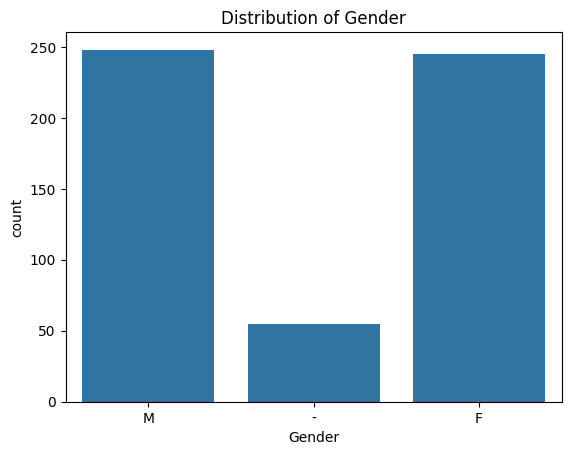

Gender Distribution:
--------------------
M: 248
F: 245
-: 55


In [331]:
#plot the distribution of gender
sns.countplot(x='Gender', data=data)
plt.title('Distribution of Gender')
plt.show()
# Count number of males and females
gender_counts = data['Gender'].value_counts()

print("Gender Distribution:")
print("-" * 20)
for gender, count in gender_counts.items():
    print(f"{gender}: {count}")

In [332]:
#Calculate median BMR by gender
median_bmr_by_gender = data.groupby('Gender')['BMR (Calories)'].median()
median_bmr_male = median_bmr_by_gender['M']
median_bmr_female = median_bmr_by_gender['F']


print("Median BMR (Calories) by Gender:")
print("-" * 30)
for gender, median in median_bmr_by_gender.items():
    print(f"{gender}: {median:.2f}")
#Calculate and print the difference between male and female median BMR
print(f"\nDifference between male and female median BMR: {median_bmr_male - median_bmr_female:.2f} calories")

Median BMR (Calories) by Gender:
------------------------------
-: 2577.77
F: 2487.20
M: 2535.75

Difference between male and female median BMR: 48.55 calories


In [333]:
#Function to assign gender based on proximity to the median BMR
def assign_gender_based_on_bmr(row):
    if row['Gender'] == '-':
        if abs(row['BMR (Calories)'] - median_bmr_male) < abs(row['BMR (Calories)'] - median_bmr_female):
            return 'M'
        else:
            return 'F'
    else:
        return row['Gender']

#Apply function to 'Gender' column using
data.loc[:, 'Gender'] = data.apply(assign_gender_based_on_bmr, axis=1)


In [334]:
#Recalculate mean BMR by gender
median_bmr_by_gender = data.groupby('Gender')['BMR (Calories)'].median()
median_bmr_male = median_bmr_by_gender['M']
median_bmr_female = median_bmr_by_gender['F']

print("Median BMR (Calories) by Gender after assigning gender based on BMR:")
print("-" * 30)
for gender, median in median_bmr_by_gender.items():
    print(f"{gender}: {median:.2f}")

median_bmr_male = median_bmr_by_gender['M']
median_bmr_female = median_bmr_by_gender['F']
difference = abs(median_bmr_male - median_bmr_female)

print(f"The difference between the two medians is: {difference:.2f}")


Median BMR (Calories) by Gender after assigning gender based on BMR:
------------------------------
F: 2458.09
M: 2561.67
The difference between the two medians is: 103.59


In [335]:
#Count number of males and females
gender_counts = data['Gender'].value_counts()

print("Gender Distribution:")
print("-" * 20)
for gender, count in gender_counts.items():
    print(f"{gender}: {count}")

Gender Distribution:
--------------------
M: 282
F: 266


After filled the nan values in 'BMR (Calories)', is possible to find the '-' in gender, which gender is.


In [336]:
# Count NaN values in each column (excluding weight-related columns) and sum them
columns_to_exclude = ['Final Weight (lbs)', 'Weight Change (lbs)']
total_rows = len(data)
nan_counts = data.drop(columns=columns_to_exclude).isna().sum()

print("Percentage of NaN values in each column:")
print("-" * 40)
for column, count in nan_counts.items():
    percentage = (count / total_rows) * 100
    print(f"{column}: {percentage:.2f}%")

total_nan = nan_counts.sum()
print("\nTotal number of NaN values:", total_nan)
print(f"Overall NaN percentage: {(total_nan / (total_rows * len(nan_counts))) * 100:.2f}%")

Percentage of NaN values in each column:
----------------------------------------
Age: 0.00%
Gender: 0.00%
BMR (Calories): 0.00%
Daily Calories Consumed: 0.00%
Daily Caloric Surplus/Deficit: 0.00%
Duration (weeks): 0.00%
Smoking: 0.00%
Physical Activity Level: 0.00%
Sleep Quality: 0.00%
Stress Level: 0.00%
Work Sector: 9.85%

Total number of NaN values: 54
Overall NaN percentage: 0.90%


In [337]:
#Set outliers to NaN for the Age column
Q1 = data['Age'].quantile(0.25)
Q3 = data['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Store original ages for comparison
ages_before_outlier_removal = data['Age'].copy()

# Set outliers to NaN
data.loc[data['Age'] < lower_bound, 'Age'] = np.nan
data.loc[data['Age'] > upper_bound, 'Age'] = np.nan

print(f"Number of outliers converted to NaN: {data['Age'].isna().sum()}")

Number of outliers converted to NaN: 31


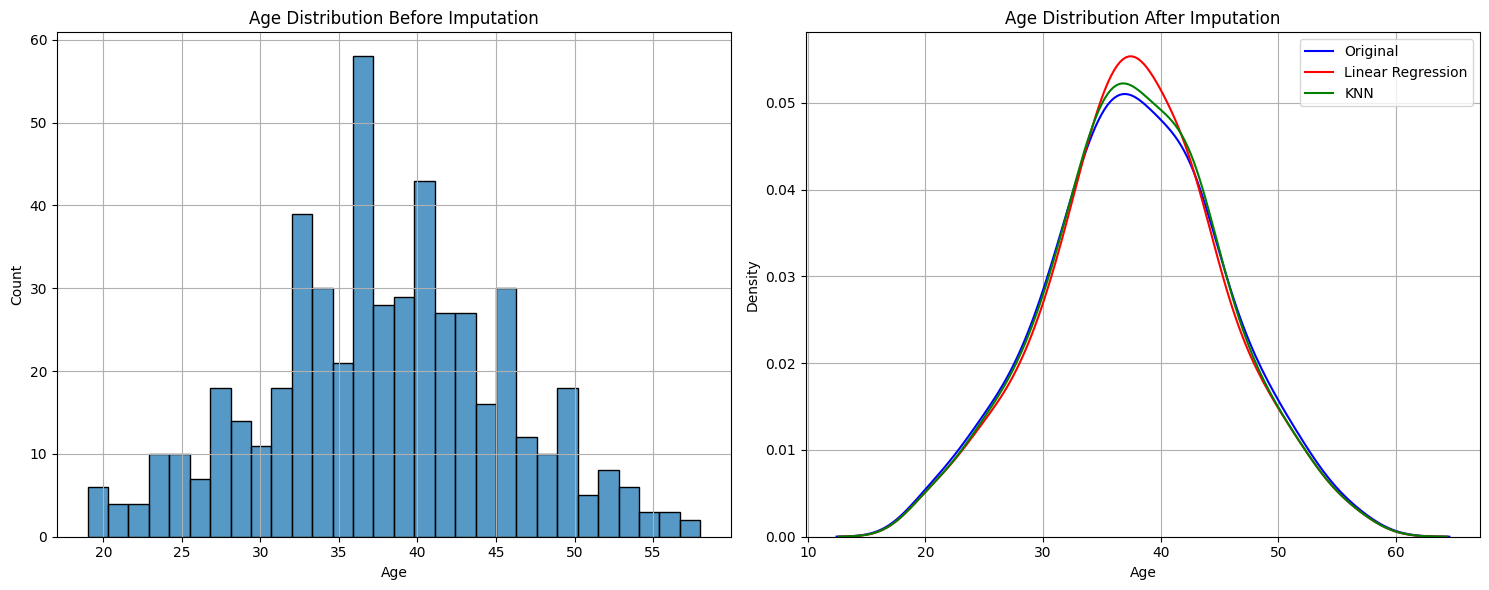


Summary Statistics:
Original mean (excluding NaN): 37.83
Linear Regression imputed mean: 37.84
KNN imputed mean: 37.83

Standard Deviations:
Original std (excluding NaN): 7.62
Linear Regression imputed std: 7.42
KNN imputed std: 7.49

Difference from original std:
Linear Regression: 0.20
KNN: 0.13

Using KNN imputation as it shows less deviation from original distribution


In [338]:
original_age = data['Age'].copy()

#Store linear regression predictions 
data_linear = data.copy()

#Features for both imputation methods
features_for_imputation = ['BMR (Calories)', 'Daily Calories Consumed', 'Daily Caloric Surplus/Deficit', 'Duration (weeks)']

#Get train and predict datasets
train_data = data.dropna(subset=['Age'])
predict_data = data[data['Age'].isnull()]

X_train = train_data[features_for_imputation]
y_train = train_data['Age']
X_predict = predict_data[features_for_imputation]

#Linear Regression imputation
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
linear_predictions = reg_model.predict(X_predict)
data_linear.loc[data['Age'].isnull(), 'Age'] = linear_predictions

#KNN imputation
data_knn = data.copy()
imputer = KNNImputer(n_neighbors=5)
columns_to_impute = features_for_imputation + ['Age']
imputed_data = imputer.fit_transform(data_knn[columns_to_impute])
data_knn[columns_to_impute] = imputed_data

#Plot age distributions before and after imputation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#Plot original age distribution
sns.histplot(data=original_age.dropna(), bins=30, ax=ax1)
ax1.set_title('Age Distribution Before Imputation')
ax1.set_xlabel('Age')
ax1.set_ylabel('Count')
ax1.grid(True)

#Plot density distributions after imputation
sns.kdeplot(data=original_age.dropna(), label='Original', color='blue', ax=ax2)
sns.kdeplot(data=data_linear['Age'], label='Linear Regression', color='red', ax=ax2)
sns.kdeplot(data=data_knn['Age'], label='KNN', color='green', ax=ax2)
ax2.set_title('Age Distribution After Imputation')
ax2.set_xlabel('Age')
ax2.set_ylabel('Density')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

#Print summary statistics
print("\nSummary Statistics:")
print(f"Original mean (excluding NaN): {original_age.mean():.2f}")
print(f"Linear Regression imputed mean: {data_linear['Age'].mean():.2f}")
print(f"KNN imputed mean: {data_knn['Age'].mean():.2f}")

print("\nStandard Deviations:")
original_std = original_age.std()
linear_std = data_linear['Age'].std()
knn_std = data_knn['Age'].std()

print(f"Original std (excluding NaN): {original_std:.2f}")
print(f"Linear Regression imputed std: {linear_std:.2f}")
print(f"KNN imputed std: {knn_std:.2f}")

#Calculate difference in standard deviations from original
linear_std_diff = abs(original_std - linear_std)
knn_std_diff = abs(original_std - knn_std)

print(f"\nDifference from original std:")
print(f"Linear Regression: {linear_std_diff:.2f}")
print(f"KNN: {knn_std_diff:.2f}")

#Use the method with smallest std difference
if knn_std_diff < linear_std_diff:
    print("\nUsing KNN imputation as it shows less deviation from original distribution")
    data = data_knn.copy()
else:
    print("\nUsing Linear Regression imputation as it shows less deviation from original distribution")
    data = data_linear.copy()

In [339]:
#Count NaN values in Weight Change column
nan_count = data['Weight Change (lbs)'].isnull().sum()
total_rows = len(data)
nan_percentage = (nan_count / total_rows) * 100

print(f"Number of NaN values in Weight Change: {nan_count}")
print(f"Percentage of NaN values: {nan_percentage:.2f}%")

#Drop rows if NaN percentage is under 5%
if nan_percentage < 5:
    data = data.dropna(subset=['Weight Change (lbs)'])
    print("Rows with NaN values in Weight Change were dropped")
else:
    print("NaN percentage is above 5%, rows were not dropped")

Number of NaN values in Weight Change: 53
Percentage of NaN values: 9.67%
NaN percentage is above 5%, rows were not dropped


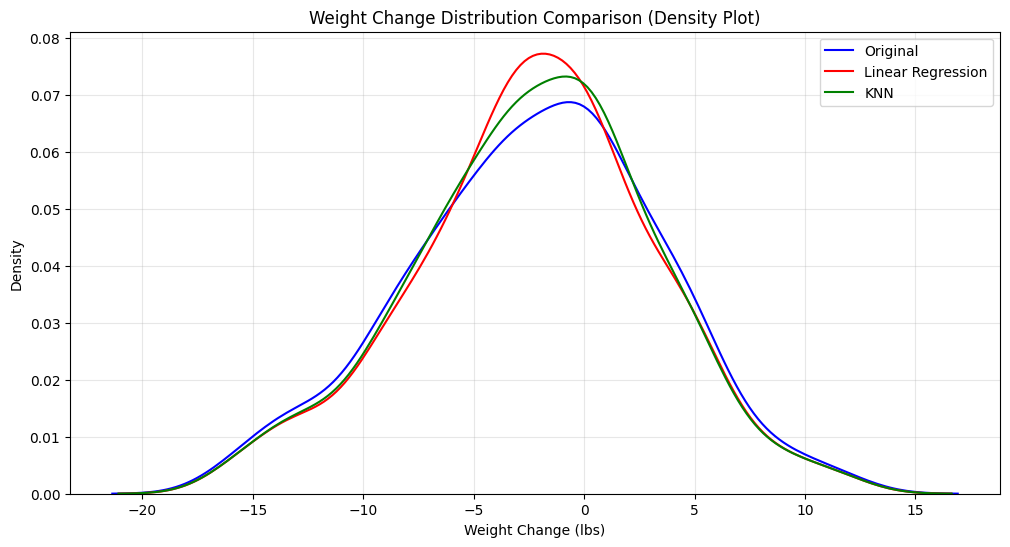


Summary Statistics:
Original mean (excluding NaN): -2.27
Linear Regression imputed mean: -2.27
KNN imputed mean: -2.29

Standard Deviations:
Original std (excluding NaN): 5.64
Linear Regression imputed std: 5.40
KNN imputed std: 5.44

Difference from original std:
Linear Regression: 0.25
KNN: 0.20

Using KNN imputation as it shows less deviation from original distribution


In [340]:
#Imputation of knn or linear regression for the nan values in Weight Change

original_weight_change = data['Weight Change (lbs)'].copy()

#Store linear regression predictions
data_linear = data.copy()

#Features for both imputation methods
features_for_imputation = ['Age', 'BMR (Calories)', 'Daily Calories Consumed', 
                          'Daily Caloric Surplus/Deficit', 'Duration (weeks)']

#Get train and predict datasets
train_data = data.dropna(subset=['Weight Change (lbs)'])
predict_data = data[data['Weight Change (lbs)'].isnull()]

X_train = train_data[features_for_imputation]
y_train = train_data['Weight Change (lbs)']
X_predict = predict_data[features_for_imputation]

#Linear Regression imputation
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
linear_predictions = reg_model.predict(X_predict)
data_linear.loc[data['Weight Change (lbs)'].isnull(), 'Weight Change (lbs)'] = linear_predictions

#KNN imputation
data_knn = data.copy()
imputer = KNNImputer(n_neighbors=5)
columns_to_impute = features_for_imputation + ['Weight Change (lbs)']
imputed_data = imputer.fit_transform(data_knn[columns_to_impute])
data_knn[columns_to_impute] = imputed_data

#Create density plots using seaborn
plt.figure(figsize=(12, 6))
sns.kdeplot(data=original_weight_change.dropna(), label='Original', color='blue')
sns.kdeplot(data=data_linear['Weight Change (lbs)'], label='Linear Regression', color='red')
sns.kdeplot(data=data_knn['Weight Change (lbs)'], label='KNN', color='green')
plt.title('Weight Change Distribution Comparison (Density Plot)')
plt.xlabel('Weight Change (lbs)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Print summary statistics
print("\nSummary Statistics:")
print(f"Original mean (excluding NaN): {original_weight_change.mean():.2f}")
print(f"Linear Regression imputed mean: {data_linear['Weight Change (lbs)'].mean():.2f}")
print(f"KNN imputed mean: {data_knn['Weight Change (lbs)'].mean():.2f}")

print("\nStandard Deviations:")
original_std = original_weight_change.std()
linear_std = data_linear['Weight Change (lbs)'].std()
knn_std = data_knn['Weight Change (lbs)'].std()

print(f"Original std (excluding NaN): {original_std:.2f}")
print(f"Linear Regression imputed std: {linear_std:.2f}")
print(f"KNN imputed std: {knn_std:.2f}")

#Calculate difference in standard deviations from original
linear_std_diff = abs(original_std - linear_std)
knn_std_diff = abs(original_std - knn_std)

print(f"\nDifference from original std:")
print(f"Linear Regression: {linear_std_diff:.2f}")
print(f"KNN: {knn_std_diff:.2f}")

#Use the method with smallest std difference
if knn_std_diff < linear_std_diff:
    print("\nUsing KNN imputation as it shows less deviation from original distribution")
    data = data_knn.copy()
else:
    print("\nUsing Linear Regression imputation as it shows less deviation from original distribution")
    data = data_linear.copy()

In [341]:
data

,Age,Gender,BMR (Calories),Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change (lbs),Duration (weeks),Smoking,Physical Activity Level,Sleep Quality,Stress Level,Work Sector,Final Weight (lbs)
1,46.0,M,2275.50,3823.00,1547.50,-1.224,6.0,False,Very Active,Excellent,6,Public,167.80
2,32.0,M,2119.40,2785.40,666.00,-0.426,7.0,True,Sedentary,Good,3,Self-Employed,144.20
3,25.0,M,2181.30,2587.30,406.00,3.370,8.0,False,Sedentary,Fair,2,Private,146.30
4,38.0,M,2463.80,3312.80,849.00,3.900,10.0,False,Lightly Active,Good,1,Unemployed,157.50
10,35.6,M,2839.10,4000.00,1160.90,2.320,5.0,False,Very Active,Poor,5,Self-Employed,189.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,39.0,F,2526.30,3557.27,1030.97,-12.840,4.0,False,Lightly Active,Good,5,Unemployed,166.73
596,41.0,F,2699.57,3546.90,847.33,4.580,8.0,False,Moderately Active,Good,6,Public,188.03
597,39.0,M,2651.40,3393.60,742.20,-7.530,9.0,False,Lightly Active,Fair,5,Private,189.50
598,41.0,F,2230.70,3442.70,1212.00,4.610,6.0,False,Lightly Active,Fair,4,Self-Employed,159.03


In [342]:
# Fill NaN values in Work Sector with 'Unemployed'
data['Work Sector'] = data['Work Sector'].fillna('Unemployed')

In [343]:
# Print number of rows with any NaN values
print("Number of rows with NaN values:", data.isnull().any(axis=1).sum())

# Print number of NaN values for each feature
print("\nNumber of NaN values per feature:")
print(data.isnull().sum())


Number of rows with NaN values: 0

Number of NaN values per feature:
Age                              0
Gender                           0
BMR (Calories)                   0
Daily Calories Consumed          0
Daily Caloric Surplus/Deficit    0
Weight Change (lbs)              0
Duration (weeks)                 0
Smoking                          0
Physical Activity Level          0
Sleep Quality                    0
Stress Level                     0
Work Sector                      0
Final Weight (lbs)               0
dtype: int64


In [344]:
data.shape


(548, 13)

At the end for Age and Weight change has been done a knn and linear imputation, for the nan values, and the one who influenced less the density function, is picked (in both cases knn).
The age at the beggining does not have any nan, in fact the nan are the outliers.

# **TASK 2. Prepare the dataset for a Linear Regression task that aims to build a "Final Weight (lbs)" predictive model.**

*2(a) Verify the feature values distribution of the numerical variables.*

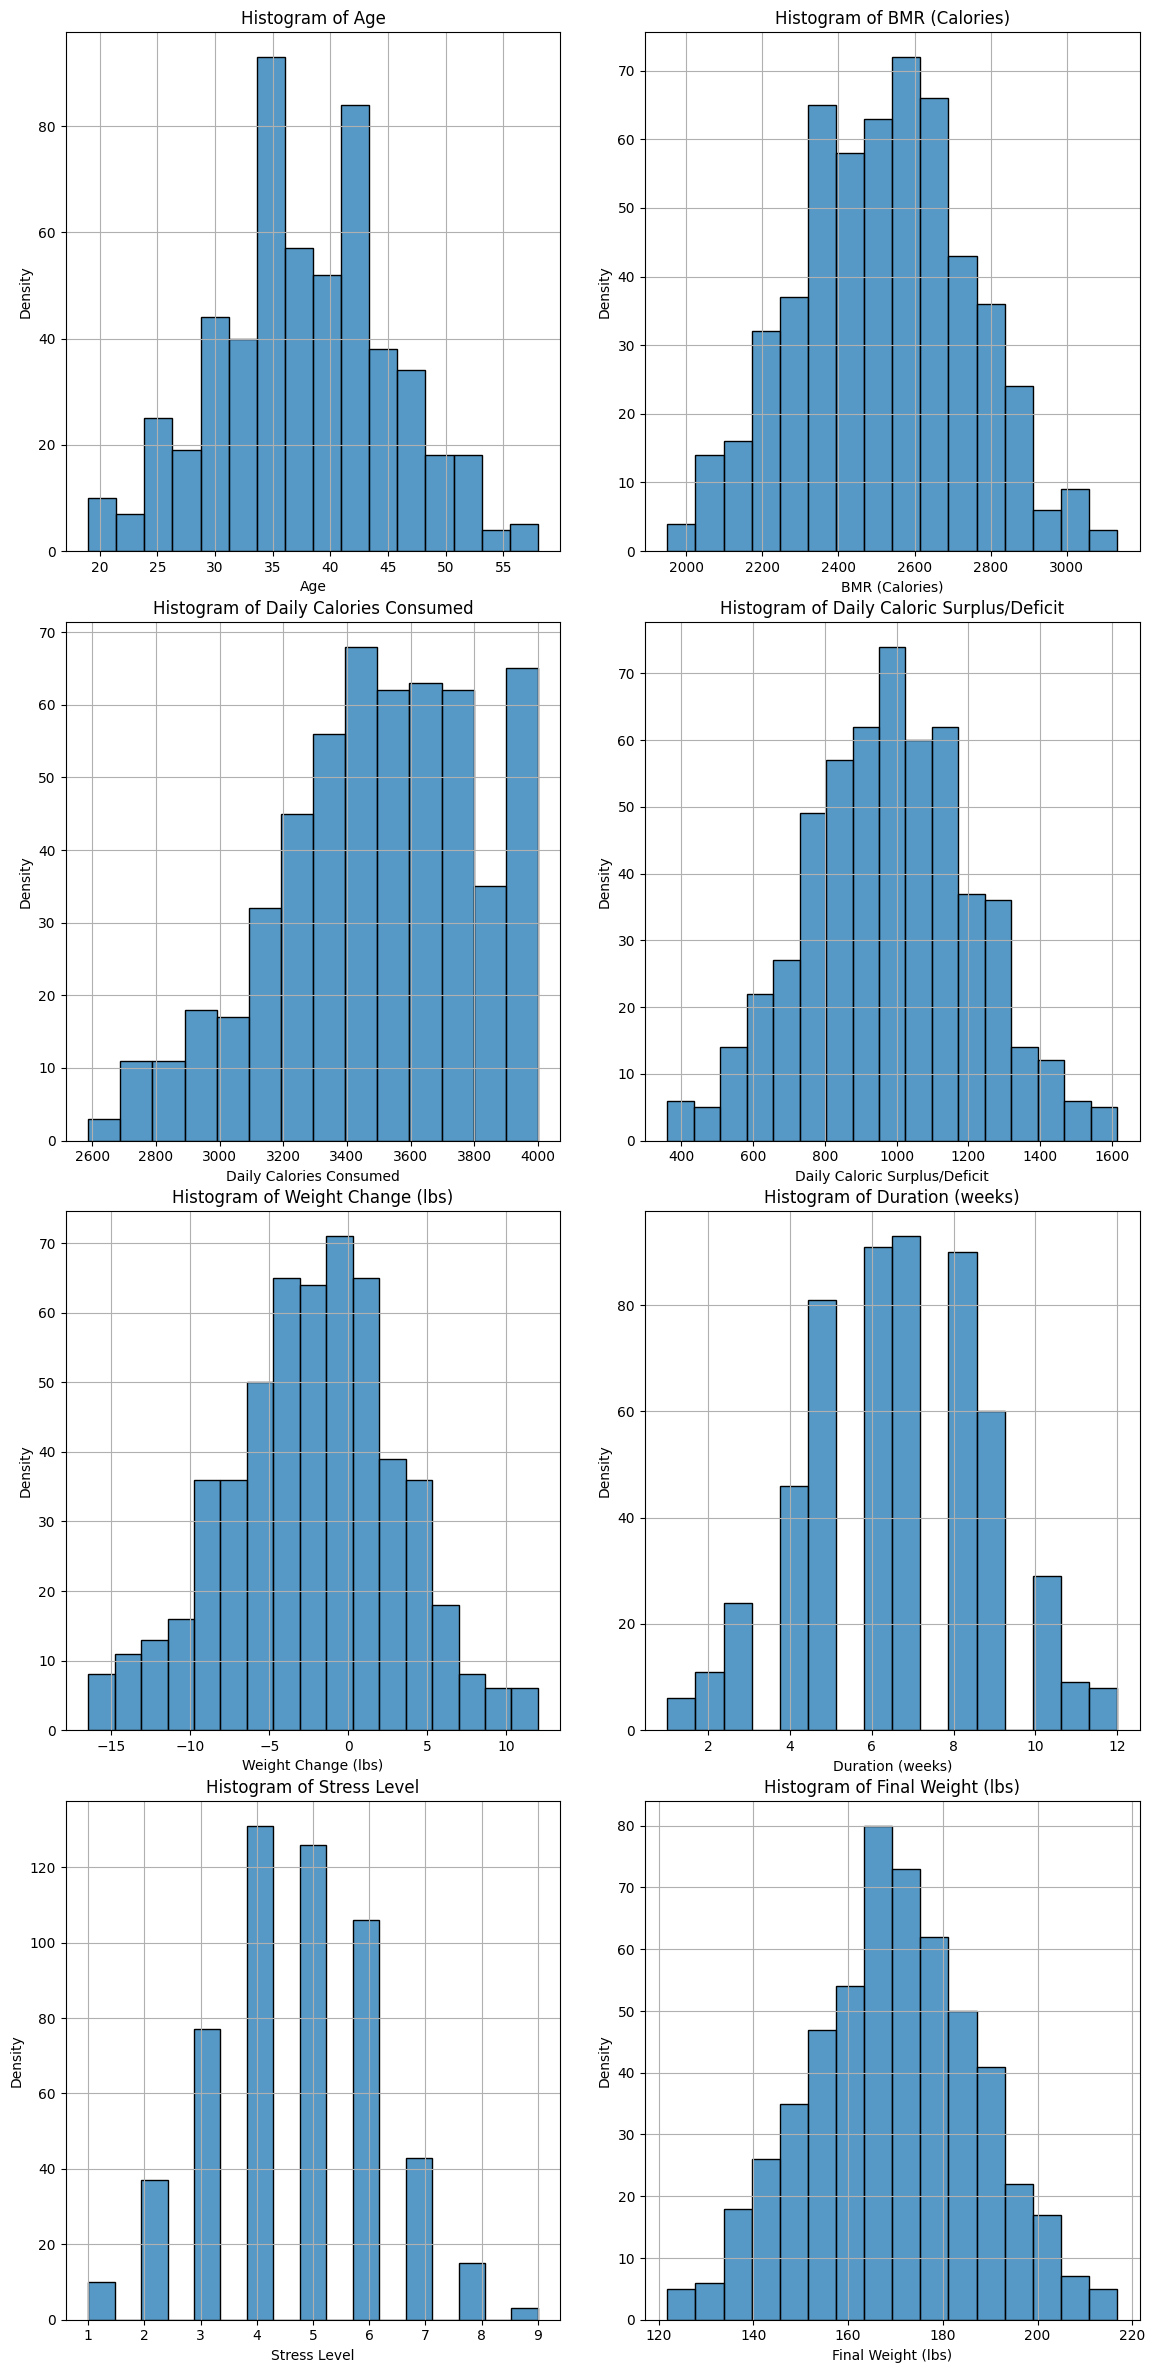

In [345]:
# Select only the numerical columns from the DataFrame
numerical_columns = data.select_dtypes(include=['int', 'float'])
# Determine the number of rows and columns for subplots
num_cols = numerical_columns.shape[1]
num_rows = num_cols // 2 + num_cols % 2 

# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 6*num_rows))
fig.tight_layout(pad=3.0)

# Loop through each numerical column and create a histogram
for i, column in enumerate(numerical_columns.columns):
    row_idx = i // 2
    col_idx = i % 2
    ax = axes[row_idx, col_idx]

    sns.histplot(data[column], ax=ax)
    ax.set_title(f'Histogram of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.grid('on')

# Remove any empty subplots if the number of columns is odd
if num_cols % 2 == 1:
    fig.delaxes(axes[num_rows - 1, 1])

plt.show()

The plots show that most features are approximately normally distributed, with varied scales across different variables. 
The features have differnet ranges, for example age and stress level have smaller ranges, while others have much larger ranges. 

*2(b) Perform, if necessary, features transformation for the numerical variables, justifying your choices.*

In [346]:
data_minmax_scaled = data.copy()

#select the numeric columns to scale
numeric_columns = ['Age', 'Stress Level', 'Duration (weeks)', 'Daily Calories Consumed', 
                   'Daily Caloric Surplus/Deficit', 'Weight Change (lbs)', 'BMR (Calories)']

#Apply Min-Max Scaler on the selected columns
scaler = MinMaxScaler()
data_minmax_scaled[numeric_columns] = scaler.fit_transform(data_minmax_scaled[numeric_columns])

#See the result
data_minmax_scaled.describe()


,Age,BMR (Calories),Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change (lbs),Duration (weeks),Stress Level,Final Weight (lbs)
count,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000,548.000000
mean,0.482894,0.480411,0.646205,0.495504,0.497779,0.511447,0.457345,169.541350
std,0.192101,0.187440,0.224466,0.185212,0.190863,0.196757,0.194854,17.902317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,121.800000
25%,0.358974,0.344925,0.500428,0.368147,0.373464,0.363636,0.375000,157.475000
50%,0.487179,0.485639,0.666171,0.492576,0.504739,0.545455,0.500000,169.485000
75%,0.615385,0.613643,0.811191,0.623154,0.620305,0.636364,0.625000,181.777500
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,216.800000


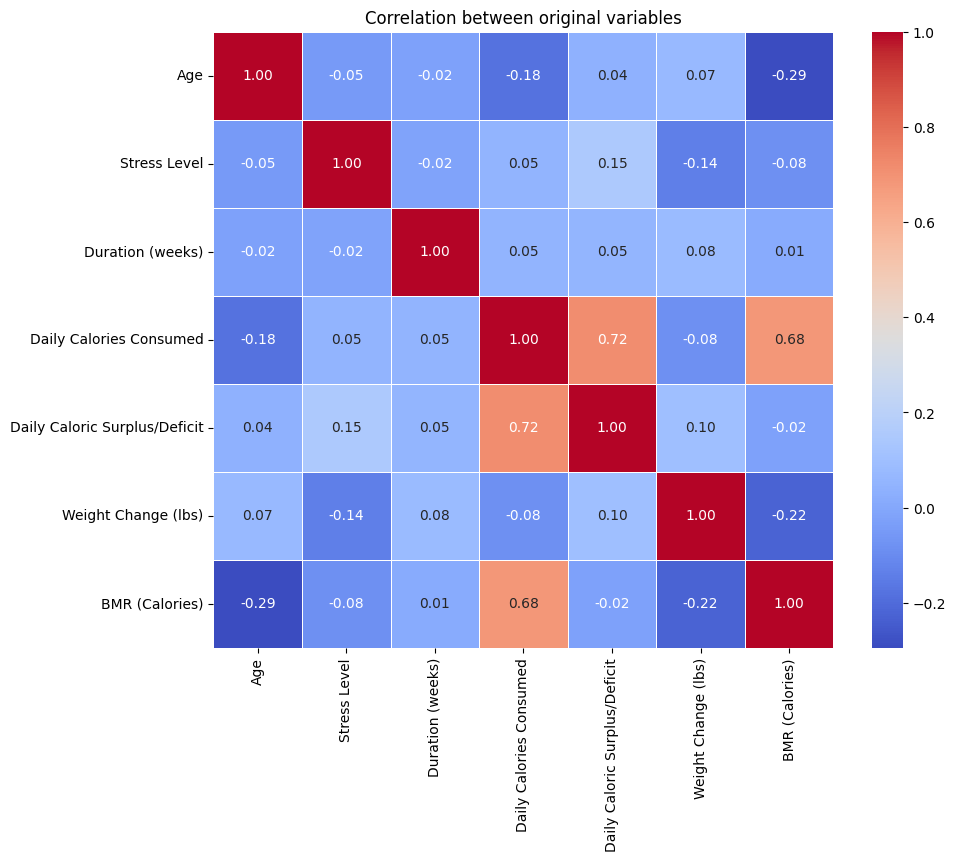

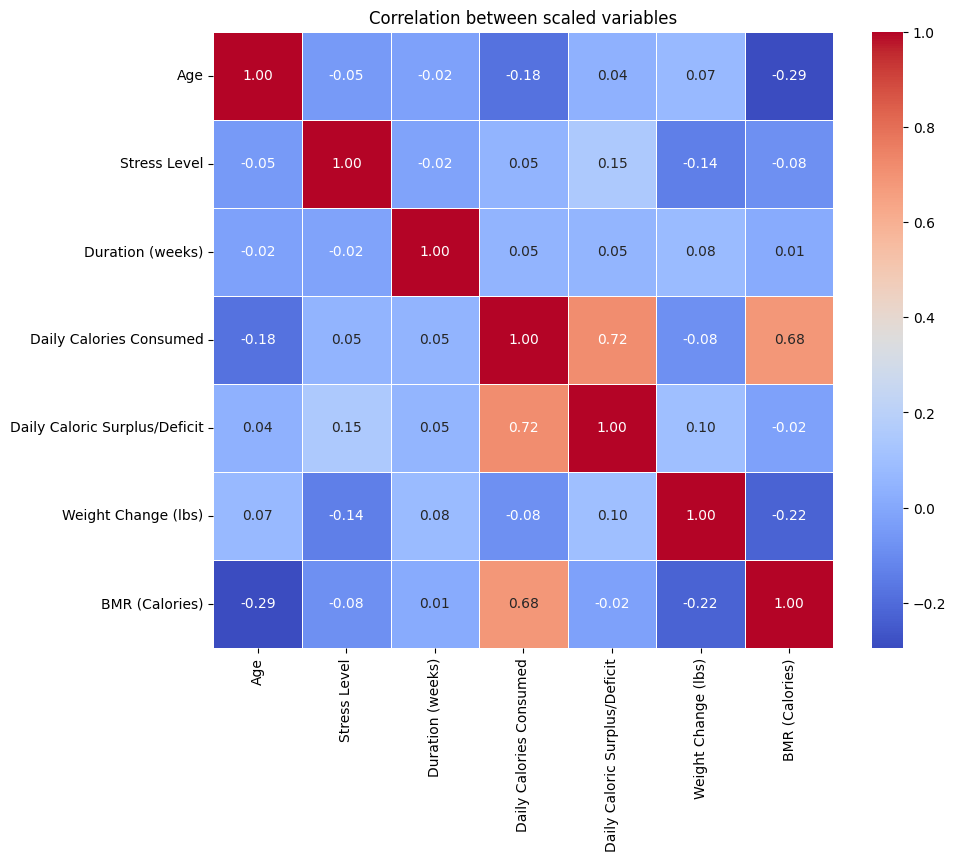

In [347]:
#Check the result based on the relationship that the features

#Original dataset
plt.figure(figsize=(10, 8))
sns.heatmap(data[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between original variables')
plt.show()

#Min-Max Scaled dataset
plt.figure(figsize=(10, 8))
sns.heatmap(data_minmax_scaled[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between scaled variables')
plt.show()


The dataset is scaled with a Min-Max Scaling, because Using Min-Max Scaling is preferable over Robust Scaling or Standardization, because for example there are not outlierso, so Robust Scaling is not necessary. And also with min max scaler all features have a value from 0 to 1, which is particularly beneficial for leading to faster convergence and stable performance, eacuse the range of values in very little.

*2(c) Perform, if necessary, encoding of the categorical variables, justifying your choices.*

In [348]:
data_encoded = data.copy()

#Binary encoding for Gender and Smoking
data_encoded['Gender'] = data_encoded['Gender'].map({'M': 1, 'F': 0})
data_encoded['Smoking'] = data_encoded['Smoking'].map({'True': 1, 'False': 0})

#Label Encoding for Physical Activity Level and Sleep Quality
label_encoder_activity = LabelEncoder()
data_encoded['Physical Activity Level'] = label_encoder_activity.fit_transform(data_encoded['Physical Activity Level'])

label_encoder_sleep = LabelEncoder()
data_encoded['Sleep Quality'] = label_encoder_sleep.fit_transform(data_encoded['Sleep Quality'])

#One-Hot Encoding for Work Sector
data_encoded = pd.get_dummies(data_encoded, columns=['Work Sector'], prefix='Work')
# Convert boolean values to integers (1 and 0) for Work sector columns
work_columns = [col for col in data_encoded.columns if col.startswith('Work_')]
for col in work_columns:
    data_encoded[col] = data_encoded[col].astype(int)

data_encoded.head()


,Age,Gender,BMR (Calories),Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change (lbs),Duration (weeks),Smoking,Physical Activity Level,Sleep Quality,Stress Level,Final Weight (lbs),Work_Private,Work_Public,Work_Self-Employed,Work_Unemployed
1,46.0,1,2275.5,3823.0,1547.5,-1.224,6.0,0,3,0,6,167.8,0,1,0,0
2,32.0,1,2119.4,2785.4,666.0,-0.426,7.0,1,2,2,3,144.2,0,0,1,0
3,25.0,1,2181.3,2587.3,406.0,3.370,8.0,0,2,1,2,146.3,1,0,0,0
4,38.0,1,2463.8,3312.8,849.0,3.900,10.0,0,0,2,1,157.5,0,0,0,1
10,35.6,1,2839.1,4000.0,1160.9,2.320,5.0,0,3,3,5,189.5,0,0,1,0


In [349]:
#Drop the categorical columns from data_minmax_scaled
columns_to_drop = ['Gender', 'Smoking', 'Physical Activity Level', 'Sleep Quality']
data_minmax_scaled = data_minmax_scaled.drop(columns=columns_to_drop)
data_minmax_scaled

,Age,BMR (Calories),Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change (lbs),Duration (weeks),Stress Level,Work Sector,Final Weight (lbs)
1,0.692308,0.275218,0.874708,0.946915,0.535135,0.454545,0.625,Public,167.80
2,0.333333,0.143232,0.140228,0.243235,0.563145,0.545455,0.250,Self-Employed,144.20
3,0.153846,0.195569,0.000000,0.035683,0.696385,0.636364,0.125,Private,146.30
4,0.487179,0.434430,0.513556,0.389319,0.714988,0.818182,0.000,Unemployed,157.50
10,0.425641,0.751754,1.000000,0.638301,0.659530,0.363636,0.500,Self-Employed,189.50
...,...,...,...,...,...,...,...,...,...
595,0.512821,0.487275,0.686607,0.534581,0.127413,0.272727,0.500,Unemployed,166.73
596,0.564103,0.633779,0.679267,0.387986,0.738856,0.636364,0.625,Public,188.03
597,0.512821,0.593050,0.570751,0.304063,0.313794,0.727273,0.500,Private,189.50
598,0.564103,0.237338,0.605507,0.679093,0.739909,0.454545,0.375,Self-Employed,159.03


In [350]:
#Combine the scaled numerical data with the encoded categorical data
data_combined = data_minmax_scaled.copy()
#Drop the numerical columns from the encoded data
data_encoded_dropped = data_encoded.drop(columns=numeric_columns)

#Concatenate the scaled numerical data with the remaining encoded data
data_combined = pd.concat([ data_combined, data_encoded_dropped], axis=1)
data_combined.drop(columns='Work Sector', inplace=True)

#Drop any duplicate columns
data_combined = data_combined.loc[:, ~data_combined.columns.duplicated()]

data_combined.head()

,Age,BMR (Calories),Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change (lbs),Duration (weeks),Stress Level,Final Weight (lbs),Gender,Smoking,Physical Activity Level,Sleep Quality,Work_Private,Work_Public,Work_Self-Employed,Work_Unemployed
1,0.692308,0.275218,0.874708,0.946915,0.535135,0.454545,0.625,167.8,1,0,3,0,0,1,0,0
2,0.333333,0.143232,0.140228,0.243235,0.563145,0.545455,0.250,144.2,1,1,2,2,0,0,1,0
3,0.153846,0.195569,0.000000,0.035683,0.696385,0.636364,0.125,146.3,1,0,2,1,1,0,0,0
4,0.487179,0.434430,0.513556,0.389319,0.714988,0.818182,0.000,157.5,1,0,0,2,0,0,0,1
10,0.425641,0.751754,1.000000,0.638301,0.659530,0.363636,0.500,189.5,1,0,3,3,0,0,1,0


For the catgorical values is necessary an encoding, for the binary ones with 0, 1 (for Smoking and Gender). 
For Physical Activity and Level	Sleep Quality is necessary an ordinal encoded transformation, because the value that they rapresent is in an order (sedentary < Lightly Active < ....).
Meanwhile for Work Sector there is not an order, so it is necessary to use an One-Hot-Encoding for encode this feature, that makes a new feature for each unique value of Work Sector.

*2 (d) Reason about the possibility of decreasing the dimensionality (number of features) of the dataset. Verify if different methodologies of feature selection do choose the same important features: adopt at least a univariate method, an iterative method, and a model-based method exploiting a linear regression model.*

In [351]:
#Define your features and target
X = data_combined.drop(columns=['Final Weight (lbs)'])
y = data_combined['Final Weight (lbs)']

In [352]:
# Univariate Method: SelectKBest with f_regression
k_best = SelectKBest(score_func=f_regression, k=7)
X_kbest = k_best.fit_transform(X, y)
selected_features_kbest = X.columns[k_best.get_support()]

selected_features_kbest

Index(['Age', 'BMR (Calories)', 'Daily Calories Consumed',
       'Weight Change (lbs)', 'Stress Level', 'Gender', 'Work_Private'],
      dtype='object')

In [353]:
#Iterative Method: Recursive Feature Elimination (RFE)
model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=7)
X_rfe = rfe.fit_transform(X, y)
selected_features_rfe = X.columns[rfe.get_support()]

selected_features_rfe

Index(['Age', 'BMR (Calories)', 'Daily Calories Consumed',
       'Daily Caloric Surplus/Deficit', 'Weight Change (lbs)', 'Stress Level',
       'Work_Public'],
      dtype='object')

In [354]:
#Model-Based Method: Lasso Regression
lasso = Lasso(alpha=0.1)
lasso_model = SelectFromModel(estimator=lasso)
X_lasso = lasso_model.fit_transform(X, y)
selected_features_lasso = X.columns[lasso_model.get_support()]

selected_features_lasso

Index(['Age', 'BMR (Calories)', 'Daily Caloric Surplus/Deficit',
       'Weight Change (lbs)', 'Stress Level', 'Gender', 'Smoking',
       'Sleep Quality', 'Work_Public'],
      dtype='object')

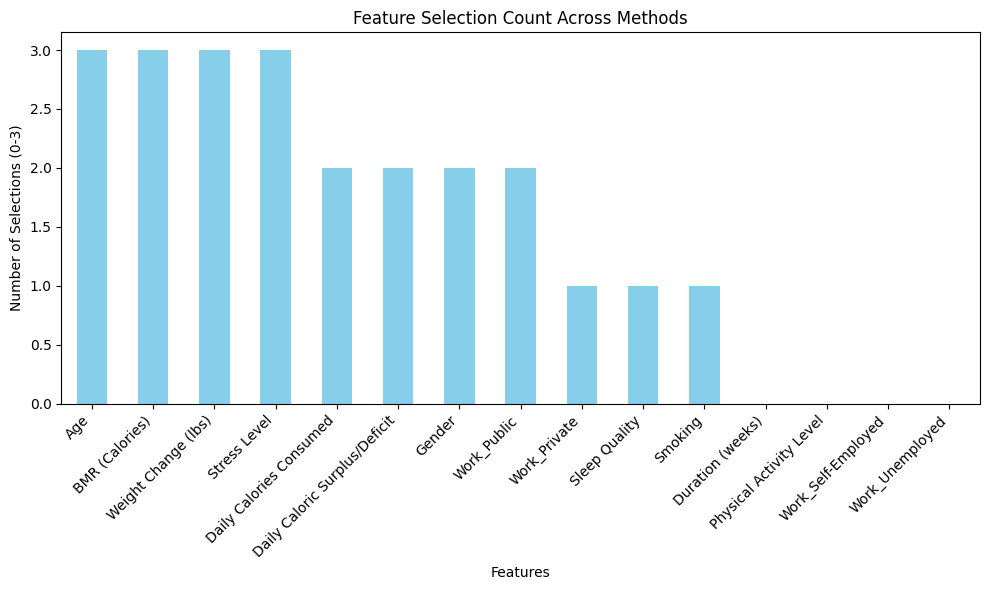

In [355]:
#Combine results in a DataFrame for comparison
feature_counts = pd.Series(0, index=X.columns)
feature_counts[selected_features_kbest] += 1
feature_counts[selected_features_rfe] += 1
feature_counts[selected_features_lasso] += 1

#Plot the results
plt.figure(figsize=(10, 6))
feature_counts.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Feature Selection Count Across Methods')
plt.xlabel('Features')
plt.ylabel('Number of Selections (0-3)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The 3 metodology selected many feature, except the 'Sleep Quality', 'Work_self-Employed', 'Work_Unemployed' that no one chose, so the important feature are the ones picked at least 2 times.

*2(e) On the base of the analysis performed above, define a dataset that you will exploit in the rest of the project (dataset_reduced), for the supervised task.*

In [356]:
#Create dataset_reduced based on features selected most frequently across methods
most_selected_features = feature_counts[feature_counts >= 2].index.tolist()

#The reduced dataset has to have also the target variable
dataset_reduced = pd.DataFrame()
dataset_reduced[most_selected_features] = data_combined[most_selected_features]
dataset_reduced['Final Weight (lbs)'] = data_combined['Final Weight (lbs)']

print("Selected features for reduced dataset:")
for i, feature in enumerate(most_selected_features, 1):
    print(f"{i}. {feature}")
    
print("\nShape of reduced dataset:", dataset_reduced.shape)
print("\nFirst few rows of the reduced dataset:")
dataset_reduced.head()


Selected features for reduced dataset:
1. Age
2. BMR (Calories)
3. Daily Calories Consumed
4. Daily Caloric Surplus/Deficit
5. Weight Change (lbs)
6. Stress Level
7. Gender
8. Work_Public

Shape of reduced dataset: (548, 9)

First few rows of the reduced dataset:


,Age,BMR (Calories),Daily Calories Consumed,Daily Caloric Surplus/Deficit,Weight Change (lbs),Stress Level,Gender,Work_Public,Final Weight (lbs)
1,0.692308,0.275218,0.874708,0.946915,0.535135,0.625,1,1,167.8
2,0.333333,0.143232,0.140228,0.243235,0.563145,0.250,1,0,144.2
3,0.153846,0.195569,0.000000,0.035683,0.696385,0.125,1,0,146.3
4,0.487179,0.434430,0.513556,0.389319,0.714988,0.000,1,0,157.5
10,0.425641,0.751754,1.000000,0.638301,0.659530,0.500,1,0,189.5


Now there is a new copy of the data_encoded, the dataset_reduced that is datased_reduced that conteins the feture selected 2 ore more times in the task 2d.

# **TASK3. Build a supervised system based on Linear Regression capable of predicting the Final Weight (lbs) under the two conditions specified in the preamble (perform the following tasks for both conditions separately).**

*3(a) Linear Regression exploiting the sklearn implementation of the algorithm.*

Model with Calories:
Mean Squared Error: 37.95026604055461
Root Mean Squared Error: 6.16037872541572
R^2 Score: 0.8791152043089479

Model without Calories:
Mean Squared Error: 38.00978959039802
Root Mean Squared Error: 6.165207992468544
R^2 Score: 0.8789256011015834


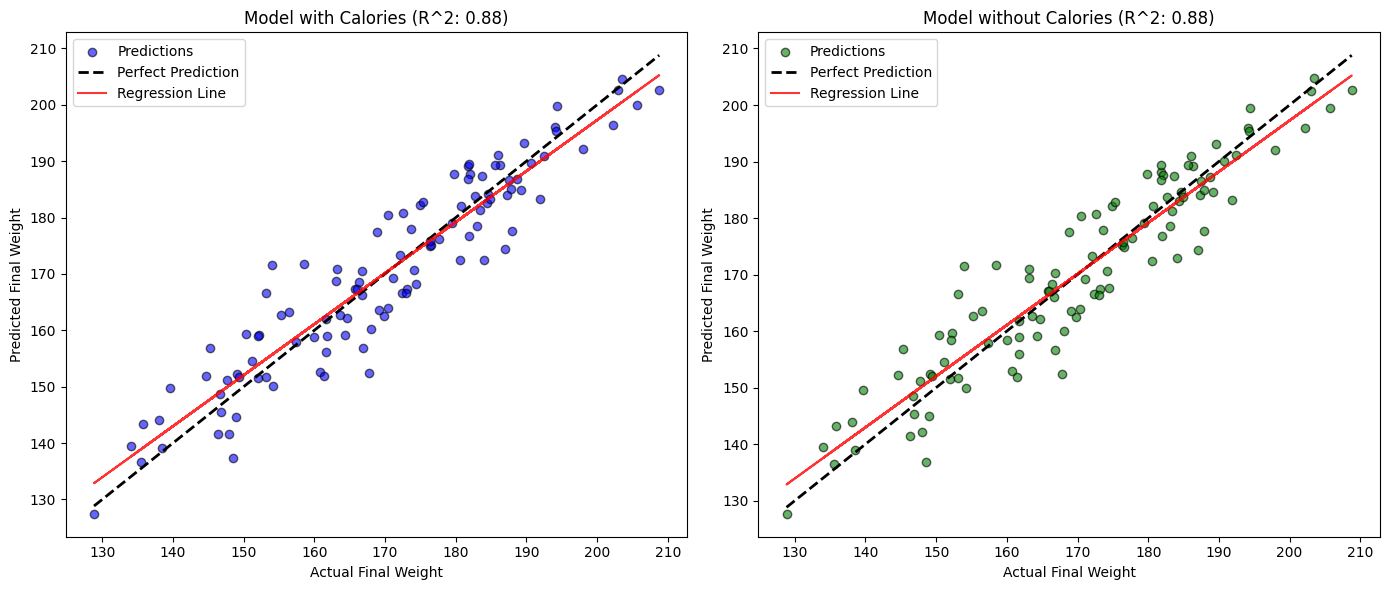

In [357]:
#Split the dataset into features and target
X = dataset_reduced.drop(columns=['Final Weight (lbs)'])
y = dataset_reduced['Final Weight (lbs)']

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model 1: with complete dataset_reduced
X_train_with_calories = X_train
X_test_with_calories = X_test

#Model 2: without B;R (calories)
X = dataset_reduced.drop(columns=['Final Weight (lbs)', 'BMR (Calories)']) 
y = dataset_reduced['Final Weight (lbs)']

#Split the dataset into training and testing sets
X_train_without_calories, X_test_without_calories, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initialize and train both models
model_with_calories = LinearRegression()
model_without_calories = LinearRegression()

#Train the model with complete dataset_reduced
model_with_calories.fit(X_train_with_calories, y_train)
y_pred_with_calories = model_with_calories.predict(X_test_with_calories)

#Train the model without BMR (calories)
model_without_calories.fit(X_train_without_calories, y_train)
y_pred_without_calories = model_without_calories.predict(X_test_without_calories)

#Calculate metrics both
mse_with_calories = mean_squared_error(y_test, y_pred_with_calories)
rmse_with_calories = np.sqrt(mse_with_calories)
r2_with_calories = r2_score(y_test, y_pred_with_calories)

mse_without_calories = mean_squared_error(y_test, y_pred_without_calories)
rmse_without_calories = np.sqrt(mse_without_calories)
r2_without_calories = r2_score(y_test, y_pred_without_calories)

#Print the metrics
print("Model with Calories:")
print(f"Mean Squared Error: {mse_with_calories}")
print(f"Root Mean Squared Error: {rmse_with_calories}")
print(f"R^2 Score: {r2_with_calories}")

print("\nModel without Calories:")
print(f"Mean Squared Error: {mse_without_calories}")
print(f"Root Mean Squared Error: {rmse_without_calories}")
print(f"R^2 Score: {r2_without_calories}")

#Plotting both predictions
plt.figure(figsize=(14, 6))

#Plot for Model with complete dataset_reduced
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_with_calories, color="blue", alpha=0.6, edgecolor="k", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect Prediction")

#Add regression line
z_with = np.polyfit(y_test, y_pred_with_calories, 1)
p_with = np.poly1d(z_with)
plt.plot(y_test, p_with(y_test), "r-", alpha=0.8, label="Regression Line")

plt.xlabel("Actual Final Weight")
plt.ylabel("Predicted Final Weight")
plt.title(f"Model with Calories (R^2: {r2_with_calories:.2f})")
plt.legend()

#Plot for Model without BMR (calories)
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_without_calories, color="green", alpha=0.6, edgecolor="k", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label="Perfect Prediction")

#Add regression line
z_without = np.polyfit(y_test, y_pred_without_calories, 1)
p_without = np.poly1d(z_without)
plt.plot(y_test, p_without(y_test), "r-", alpha=0.8, label="Regression Line")

plt.xlabel("Actual Final Weight")
plt.ylabel("Predicted Final Weight")
plt.title(f"Model without Calories (R^2: {r2_without_calories:.2f})")
plt.legend()

plt.tight_layout()
plt.show()

In [358]:
#absolute differences between models
r2_diff = (r2_with_calories - r2_without_calories)
rmse_diff = (rmse_with_calories - rmse_without_calories)

print("Differences between Models (with - withou calories):")
print(f"R^2 Score Difference: {r2_diff:.4f}")
print(f"RMSE Difference: {rmse_diff:.4f}")


Differences between Models (with - withou calories):
R^2 Score Difference: 0.0002
RMSE Difference: -0.0048


With the standard linear regression the results are good, because a value of R^2 of 0.88/0.87 is great, also is significative that the difference between the model with and withou calories is very little.
And also the RMSE is less in the model without calories.

*3(b) Linear Regression exploiting a Batch Gradient Descent learning procedure (not the sklearn implementation). Identify the best value of learning rate η and an appropriate number of iterations which ensures the convergence of the model.*

In [359]:
#Define the batch gradient descent function: def batch_gradient_descent(X, y, learning_rate, n_iterations):
def batch_gradient_descent(X, y, learning_rate, n_iterations):
    #Initialize model parameters (weights) with zeros - one weight per feature
    weights = np.zeros(X.shape[1])
    #Initialize bias term (intercept) to zero
    bias = 0
    #Get number of training examples
    m = len(y)
    
    #Initialize list to store cost history for plotting convergence
    cost_history = []
    
    #Main training loop
    for i in range(n_iterations):
        #Make predictions using current weights and bias
        y_pred = np.dot(X, weights) + bias
        
        #Calculate gradients for weights and bias using partial derivatives
        #dw = derivative of cost with respect to weights
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        #db = derivative of cost with respect to bias
        db = (1/m) * np.sum(y_pred - y)
        
        #Update parameters using gradient descent
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db
        
        #Calculate mean squared error cost for this iteration
        cost = (1/(2*m)) * np.sum((y_pred - y)**2)
        #Store cost for plotting
        cost_history.append(cost)
        
    return weights, bias, cost_history

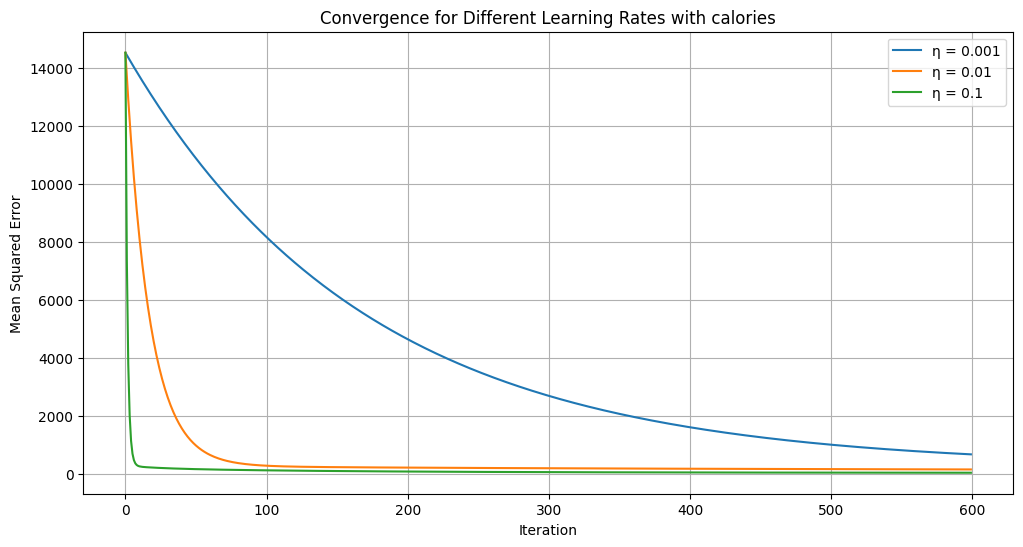


Batch Gradient Descent Results:
--------------------------------------------------
Best Learning Rate: 0.1
Training RMSE: 7.59
Testing RMSE: 7.28
Training R^2 Score: 0.8207
Testing R^2 Score: 0.8311


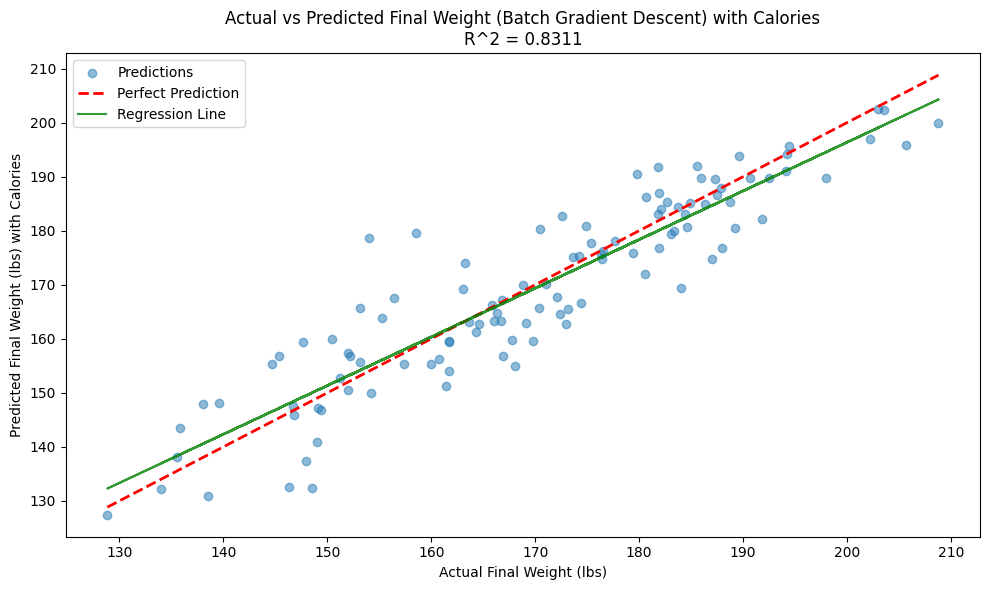

In [360]:
#Define different learning rates to try
learning_rates = [0.001, 0.01, 0.1]

n_iterations = 600

plt.figure(figsize=(12, 6))

#Initialize variables to track best model
best_cost = float('inf')
best_lr = None
best_weights = None
best_bias = None

#Try each learning rate
for lr in learning_rates:
    #Train model with current learning rate
    weights, bias, cost_history_bga  = batch_gradient_descent(X_train_with_calories, y_train, lr, n_iterations)
    
    #Plot convergence curve for current learning rate
    plt.plot(cost_history_bga, label=f'η = {lr}')
    
    #Update best model if current one performs better
    if cost_history_bga[-1] < best_cost:
        best_cost = cost_history_bga[-1]
        best_lr = lr
        best_weights = weights
        best_bias = bias

#convergence plot
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Convergence for Different Learning Rates with calories')
plt.legend()
plt.grid(True)
plt.show()

#Make predictions using best model
y_pred_train_bga = np.dot(X_train_with_calories, best_weights) + best_bias  
y_pred_test_bga = np.dot(X_test_with_calories, best_weights) + best_bias    

#Calculate performance metrics
train_rmse_bga = np.sqrt(mean_squared_error(y_train, y_pred_train_bga)) 
test_rmse_bga = np.sqrt(mean_squared_error(y_test, y_pred_test_bga))     
train_r2_bga = r2_score(y_train, y_pred_train_bga)                       
test_r2_bga = r2_score(y_test, y_pred_test_bga)                         

#Print model performance metrics
print("\nBatch Gradient Descent Results:")
print("-" * 50)
print(f"Best Learning Rate: {best_lr}")
print(f"Training RMSE: {train_rmse_bga:.2f}")
print(f"Testing RMSE: {test_rmse_bga:.2f}")
print(f"Training R^2 Score: {train_r2_bga:.4f}")
print(f"Testing R^2 Score: {test_r2_bga:.4f}")

#Create scatter plot of octual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test_bga, alpha=0.5, label='Predictions')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')


z = np.polyfit(y_test, y_pred_test_bga, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "g-", alpha=0.8, label='Regression Line')

plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs) with Calories')
plt.title(f'Actual vs Predicted Final Weight (Batch Gradient Descent) with Calories\nR^2 = {test_r2_bga:.4f}')
plt.legend()
plt.tight_layout()
plt.show()


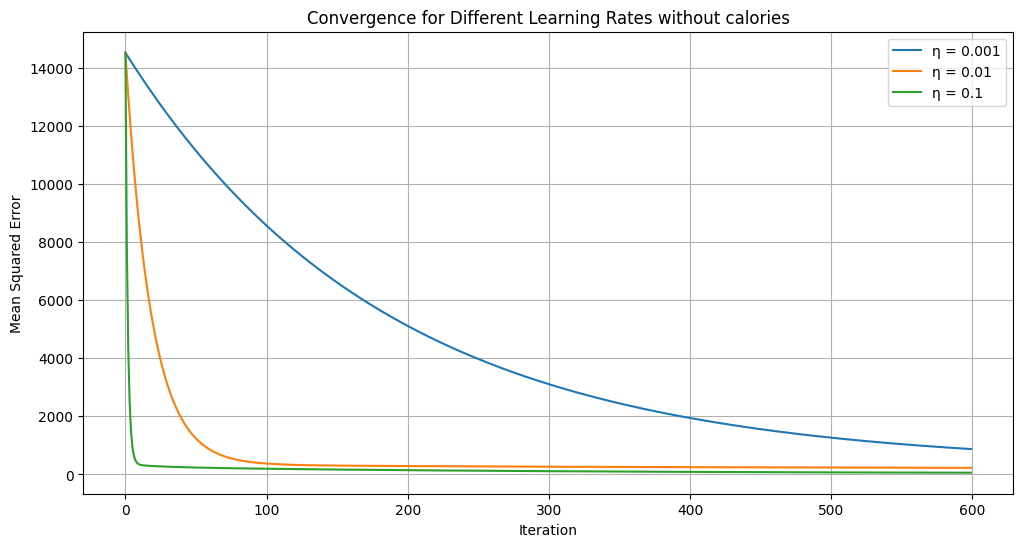


Batch Gradient Descent Results without calories:
--------------------------------------------------
Best Learning Rate: 0.1
Training RMSE: 10.90
Testing RMSE: 10.94
Training R^2 Score: 0.6300
Testing R^2 Score: 0.6189


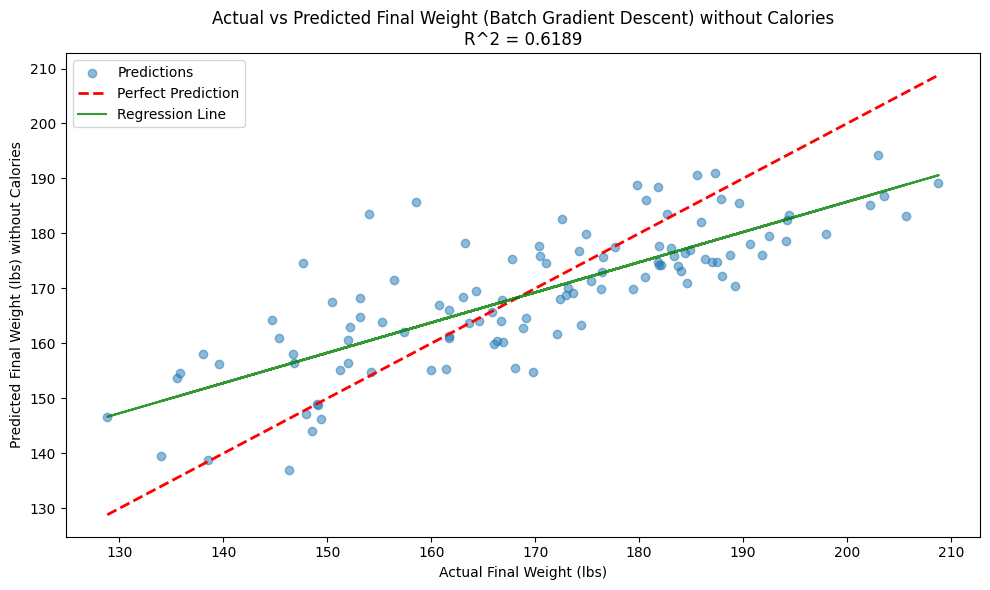

In [361]:
#Same as before but without BMR (Calories
learning_rates = [0.001, 0.01, 0.1]
n_iterations = 600

plt.figure(figsize=(12, 6))

#track best model
best_cost = float('inf')
best_lr = None
best_weights = None
best_bias = None

for lr in learning_rates:
    weights, bias, cost_history_bga_wo = batch_gradient_descent(X_train_without_calories, y_train, lr, n_iterations)
    
    #Plot convergence curve for current learning rate
    plt.plot(cost_history_bga_wo, label=f'η = {lr}')
    
    #Update best model if is better
    if cost_history_bga_wo[-1] < best_cost:
        best_cost = cost_history_bga_wo[-1]
        best_lr = lr
        best_weights = weights
        best_bias = bias

plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Convergence for Different Learning Rates without calories')
plt.legend()
plt.grid(True)
plt.show()

#Make predictions with best model
y_pred_train_bga_wo = np.dot(X_train_without_calories, best_weights) + best_bias  # Training predictions
y_pred_test_bga_wo = np.dot(X_test_without_calories, best_weights) + best_bias    # Test predictions

#performance metrics
train_rmse_bga_wo = np.sqrt(mean_squared_error(y_train, y_pred_train_bga_wo))  # Training RMSE
test_rmse_bga_wo = np.sqrt(mean_squared_error(y_test, y_pred_test_bga_wo))     # Test RMSE
train_r2_bga_wo = r2_score(y_train, y_pred_train_bga_wo)                       # Training R^2
test_r2_bga_wo = r2_score(y_test, y_pred_test_bga_wo)                         # Test R^2

#model performance metrics
print("\nBatch Gradient Descent Results without calories:")
print("-" * 50)
print(f"Best Learning Rate: {best_lr}")
print(f"Training RMSE: {train_rmse_bga_wo:.2f}")
print(f"Testing RMSE: {test_rmse_bga_wo:.2f}")
print(f"Training R^2 Score: {train_r2_bga_wo:.4f}")
print(f"Testing R^2 Score: {test_r2_bga_wo:.4f}")

#scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test_bga_wo, alpha=0.5, label='Predictions')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

z = np.polyfit(y_test, y_pred_test_bga_wo, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "g-", alpha=0.8, label='Regression Line')

plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs) without Calories')
plt.title(f'Actual vs Predicted Final Weight (Batch Gradient Descent) without Calories\nR^2 = {test_r2_bga_wo:.4f}')
plt.legend()
plt.tight_layout()
plt.show()


In [362]:
#Calculate R^2 and RMSE differences between models with and without calories
r2_diff_train = train_r2_bga - train_r2_bga_wo
r2_diff_test = test_r2_bga - test_r2_bga_wo
rmse_diff_train = train_rmse_bga - train_rmse_bga_wo
rmse_diff_test = test_rmse_bga - test_rmse_bga_wo

print("\nR^2 Score Differences (With Calories - Without Calories):")
print("-" * 50)
print(f"Training R^2 Difference: {(r2_diff_train):.10f}")
print(f"Testing R^2 Difference: {(r2_diff_test):.10f}")

print("\nRMSE Differences (With Calories - Without Calories):")
print("-" * 50)
print(f"Training RMSE Difference: {rmse_diff_train:.10f}")
print(f"Testing RMSE Difference: {rmse_diff_test:.10f}")


R^2 Score Differences (With Calories - Without Calories):
--------------------------------------------------
Training R^2 Difference: 0.1907162438
Testing R^2 Difference: 0.2122667955

RMSE Differences (With Calories - Without Calories):
--------------------------------------------------
Training RMSE Difference: -3.3139027476
Testing RMSE Difference: -3.6574872852


Batch Grandient Descent analysis:
- the results are different from the standard linear regression, because the difference between the model with and without calories in significative
- R^2 the difference is 0.2 that is not a great result. So in this case the Calories impact more than before.

*3(c) Linear Regression exploiting a Mini-Batch Gradient Descent learning procedure (not the sklearn implementation), exploiting a mini-batch size of maximum 128 samples (use mini-batch sizes as power of 2). Identify the best value of learning rate η and an appropriate number of iterations which ensures the convergence of the model.*

In [363]:
#Function to perform mini-batch gradient descent: def mini_batch_gd(X, y, batch_size, learning_rate, n_iterations):
def mini_batch_gd(X, y, batch_size, learning_rate, n_iterations):
    m = X.shape[0]
    theta = np.zeros((X.shape[1], 1))
    cost_history = []
    
    for iteration in range(n_iterations):
        #Shuffle data
        permutation = np.random.permutation(m)
        X_shuffled = X[permutation]
        y_shuffled = y[permutation]
        
        #Mini-batch training
        for i in range(0, m, batch_size):
            end = min(i + batch_size, m)
            X_batch = X_shuffled[i:end]
            y_batch = y_shuffled[i:end].reshape(-1,1)
            
            #Compute predictions
            y_pred = X_batch.dot(theta)
            
            #Compute gradients
            gradients = (2/len(X_batch)) * X_batch.T.dot(y_pred - y_batch)
            
            #Update parameters
            theta = theta - learning_rate * gradients
        
        #Compute cost for full dataset
        predictions = X.dot(theta)
        cost = np.mean((predictions - y.reshape(-1,1))**2)
        cost_history.append(cost)
        
        #Early stopping if converged
        if iteration > 0 and abs(cost_history[-1] - cost_history[-2]) < 1e-5:
            print(f"Converged at iteration {iteration}")
            break
            
    return theta, cost_history




Training with batch_size=32, learning_rate=0.001

Training with batch_size=32, learning_rate=0.01

Training with batch_size=32, learning_rate=0.1

Training with batch_size=64, learning_rate=0.001

Training with batch_size=64, learning_rate=0.01

Training with batch_size=64, learning_rate=0.1

Training with batch_size=128, learning_rate=0.001

Training with batch_size=128, learning_rate=0.01

Training with batch_size=128, learning_rate=0.1


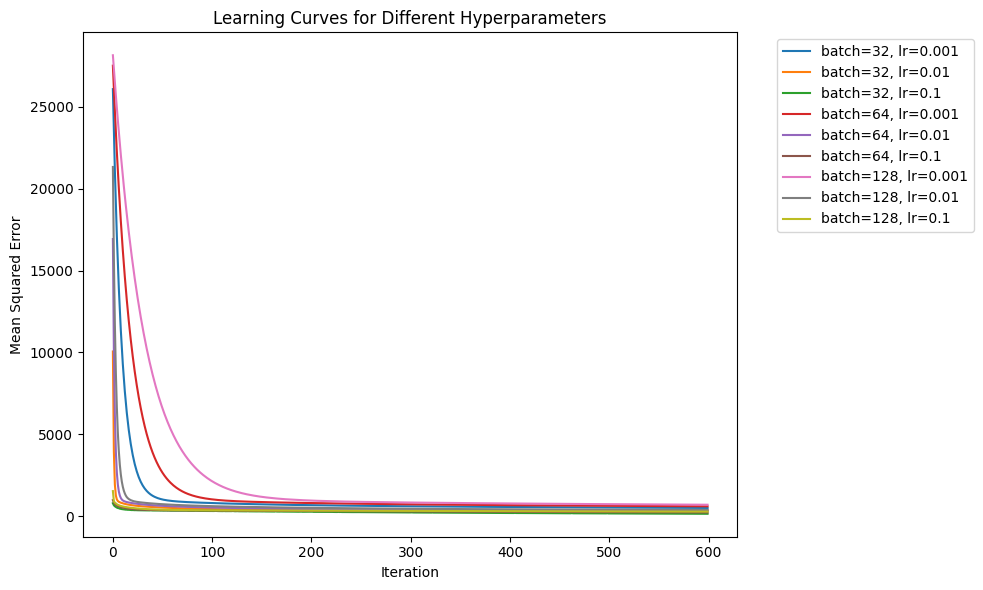


Best parameters: batch_size=32, learning_rate=0.1
Best MSE: 145.139622
Best RMSE: 12.047391
Best R^2 Score: 0.5483


In [364]:
#mini-batch with calories
#Define hyperparameters
batch_sizes = [32, 64, 128]  # Powers of 2 up to 128
learning_rates = [0.001, 0.01, 0.1]  
n_iterations = 600

#Convert data to array
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

#Train and evaluate models with the hyperparameters
best_mse_mb = float('inf')
best_rmse_mb = float('inf')
best_params = None
best_r2_mb = -float('inf')
results = {}

plt.figure(figsize=(10, 6))

for batch_size in batch_sizes:
    for lr in learning_rates:
        print(f"\nTraining with batch_size={batch_size}, learning_rate={lr}")
        theta, cost_history_mbgd = mini_batch_gd(X_train_np, y_train_np, batch_size, lr, n_iterations)
        
        #Calculate predictions
        y_pred = X_train_np.dot(theta)
        
        r2_mb = r2_score(y_train_np, y_pred)
        
        mse_mb = cost_history_mbgd[-1]
        rmse_mb = np.sqrt(mse_mb)
        results[(batch_size, lr)] = (mse_mb, rmse_mb, r2_mb)
        
        if r2_mb > best_r2_mb:
            best_r2_mb = r2_mb
            best_mse_mb = mse_mb
            best_rmse_mb = rmse_mb
            best_params = (batch_size, lr)
            
        plt.plot(cost_history_mbgd, label=f'batch={batch_size}, lr={lr}')

plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curves for Different Hyperparameters')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"\nBest parameters: batch_size={best_params[0]}, learning_rate={best_params[1]}")
print(f"Best MSE: {best_mse_mb:.6f}")
print(f"Best RMSE: {best_rmse_mb:.6f}")
print(f"Best R^2 Score: {best_r2_mb:.4f}")



Training with batch_size=32, learning_rate=0.001

Training with batch_size=32, learning_rate=0.01

Training with batch_size=32, learning_rate=0.1

Training with batch_size=64, learning_rate=0.001

Training with batch_size=64, learning_rate=0.01

Training with batch_size=64, learning_rate=0.1

Training with batch_size=128, learning_rate=0.001

Training with batch_size=128, learning_rate=0.01

Training with batch_size=128, learning_rate=0.1


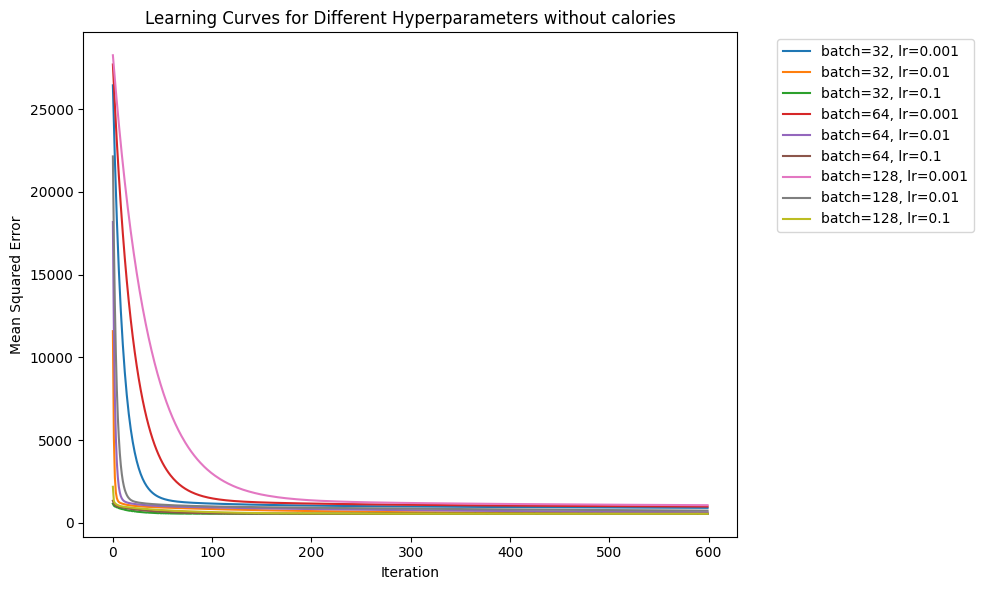


Best parameters: batch_size=32, learning_rate=0.001
Best MSE: 904.542859
Best RMSE: 30.075619
Best R^2 Score: 0.1293


In [365]:
#mini-batch without calories
X_train_np_1 = np.array(X_train_without_calories)
y_train_np_1 = np.array(y_train)

best_mse_mb_wo = float('inf')
best_rmse_mb_wo = float('inf')
best_params = None
best_r2_mb_wo = -float('inf')
results = {}

plt.figure(figsize=(10, 6))

for batch_size in batch_sizes:
    for lr in learning_rates:
        print(f"\nTraining with batch_size={batch_size}, learning_rate={lr}")
        theta, cost_history_mbgd_wo = mini_batch_gd(X_train_np_1, y_train_np_1, batch_size, lr, n_iterations)
        
        #Calculate predictions
        y_pred = X_train_np_1.dot(theta)
        
        r2_mb_1 = r2_score(y_train_np, y_pred)
        
        mse_mb = cost_history_mbgd_wo[-1]
        rmse_mb = np.sqrt(mse_mb)
        results[(batch_size, lr)] = (mse_mb, rmse_mb, r2_mb_1)
        
        if r2_mb_1 > best_r2_mb_wo:
            best_r2_mb_wo = r2_mb
            best_mse_mb_wo = mse_mb
            best_rmse_mb_wo = rmse_mb
            best_params = (batch_size, lr)
            
        plt.plot(cost_history_mbgd_wo, label=f'batch={batch_size}, lr={lr}')

plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curves for Different Hyperparameters without calories')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"\nBest parameters: batch_size={best_params[0]}, learning_rate={best_params[1]}")
print(f"Best MSE: {best_mse_mb_wo:.6f}")
print(f"Best RMSE: {best_rmse_mb_wo:.6f}")
print(f"Best R^2 Score: {best_r2_mb_wo:.4f}")


In [366]:
#Calculate differences between models with and without calories
r2_difference = best_r2_mb - best_r2_mb_wo
rmse_difference = best_rmse_mb - best_rmse_mb_wo

print("\nDifferences between models with and without calories:")
print(f"R^2 Score difference (with - without): {r2_difference:.4f}")
print(f"RMSE difference (with - without): {rmse_difference:.6f}")
plt.show()



Differences between models with and without calories:
R^2 Score difference (with - without): 0.4190
RMSE difference (with - without): -18.028228


In the mini-batch the difference between the two models rincrease significativly, because the first mdoel, with calories, remains a good performer with an high R^2, with a RMSE of 6.86.
Meanwhile the model without the calories is vary bad, with a negative R^2 that means that there is underfitting, so the mini batch without the calories is far from the other models.
The other difference between the two, is that the first with BMR find the best rate with a size of 64 and lr = 0.1, meanwhile the one without BMR finds th best size with 128, and the lr = 0.1 too.

*3(d) Consider the complete dataset and eventually add interaction or polynomial features (dataset_augmented). With this dataset, train a new Linear regression model based on a Batch Gradient Descent learning procedure (not the sklearn implementation). Identify the best value of learning rate η and an appropriate number of iterations which ensures the convergence of the model.*

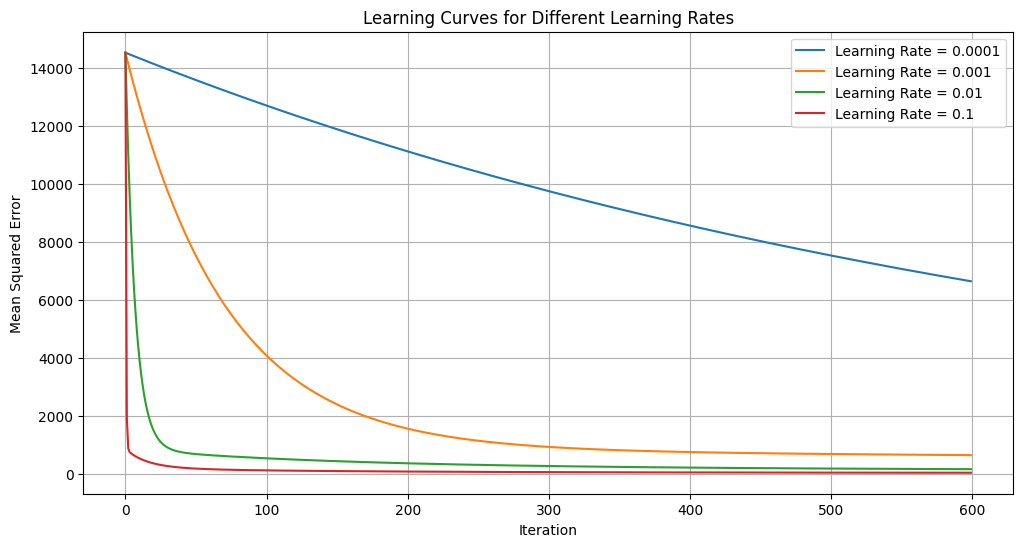


Batch Gradient Descent Results:
--------------------------------------------------
Best Learning Rate: 0.1
Training RMSE: 7.58
Testing RMSE: 7.17
Training R^2 Score: 0.8210
Testing R^2 Score: 0.8362


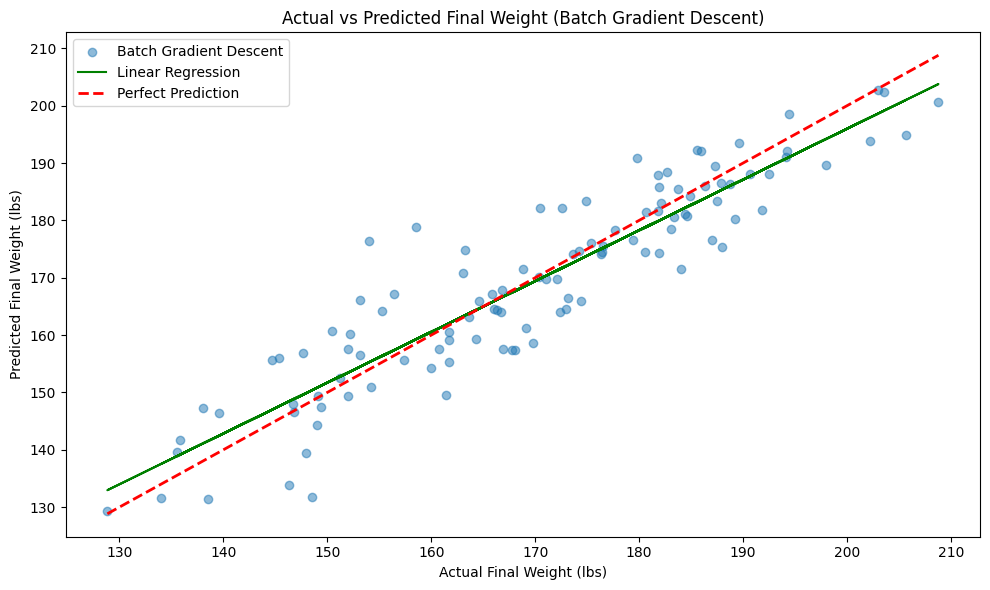

In [367]:
#batch gradient descent with dataset_augmented
dataset_augmented = data_combined.copy()

X = dataset_augmented.drop('Final Weight (lbs)', axis=1).values
y = dataset_augmented['Final Weight (lbs)'].values

#Split data into train and test sets
X_train_aug_wi_calories, X_test_aug_wi_calories, y_train_aug_wi_calories, y_test_aug_wi_calories = train_test_split(X, y, test_size=0.2, random_state=42)

#Define different learning rates to try
learning_rates = [0.0001, 0.001, 0.01, 0.1]
#Set number of training iterations
n_iterations = 600

plt.figure(figsize=(12, 6))
#Initialize variables to fimd best model
best_cost = float('inf')
best_lr = None
best_weights = None
best_bias = None

for lr in learning_rates:
    #Train model with current learning rate
    weights, bias, cost_history_bgd  = batch_gradient_descent(X_train_aug_wi_calories, y_train_aug_wi_calories, lr, n_iterations)
    
    #Plot convergence curve
    plt.plot(cost_history_bgd, label=f'Learning Rate = {lr}')
    
    #Update best model 
    if cost_history_bgd [-1] < best_cost:
        best_cost = cost_history_bgd [-1]
        best_lr = lr
        best_weights = weights
        best_bias = bias

#Configure convergence plot
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curves for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

#Make predictions using best model
y_pred_train_bgd = np.dot(X_train_aug_wi_calories, best_weights) + best_bias  # Training predictions
y_pred_test_bgd = np.dot(X_test_aug_wi_calories, best_weights) + best_bias    # Test predictions

#Perrformance metrics
train_rmse_bgd = np.sqrt(mean_squared_error(y_train_aug_wi_calories, y_pred_train_bgd))  # Training RMSE
test_rmse_bgd = np.sqrt(mean_squared_error(y_test_aug_wi_calories, y_pred_test_bgd))     # Test RMSE
train_r2_bgd = r2_score(y_train_aug_wi_calories, y_pred_train_bgd)                       # Training R^2
test_r2_bgd = r2_score(y_test_aug_wi_calories, y_pred_test_bgd)                         # Test R^2

#Print metrics
print("\nBatch Gradient Descent Results:")
print("-" * 50)
print(f"Best Learning Rate: {best_lr}")
print(f"Training RMSE: {train_rmse_bgd:.2f}")
print(f"Testing RMSE: {test_rmse_bgd:.2f}")
print(f"Training R^2 Score: {train_r2_bgd:.4f}")
print(f"Testing R^2 Score: {test_r2_bgd:.4f}")

#Create scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_aug_wi_calories, y_pred_test_bgd, alpha=0.5, label='Batch Gradient Descent')

#Fit a linear regression line
z = np.polyfit(y_test_aug_wi_calories, y_pred_test_bgd, 1)
p = np.poly1d(z)
plt.plot(y_test_aug_wi_calories, p(y_test_aug_wi_calories), "g-", label='Linear Regression')

#Add perfect prediction line
plt.plot([y_test_aug_wi_calories.min(), y_test_aug_wi_calories.max()], 
         [y_test_aug_wi_calories.min(), y_test_aug_wi_calories.max()], 
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs)')
plt.title('Actual vs Predicted Final Weight (Batch Gradient Descent)')
plt.legend()
plt.tight_layout()
plt.show()


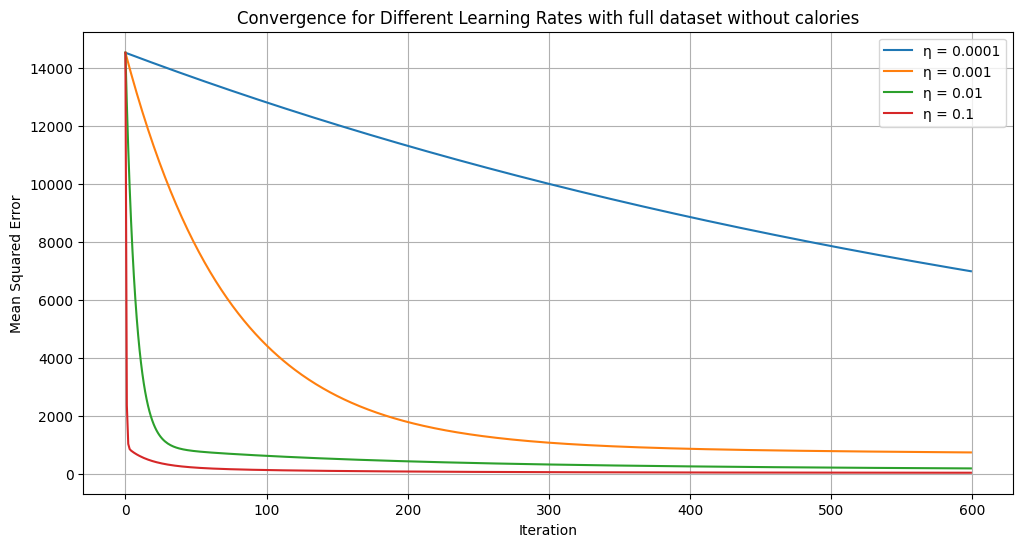


Batch Gradient Descent Results :
--------------------------------------------------
Best Learning Rate: 0.1
Training RMSE: 7.35
Testing RMSE: 6.79
Training R^2 Score: 0.8319
Testing R^2 Score: 0.8532


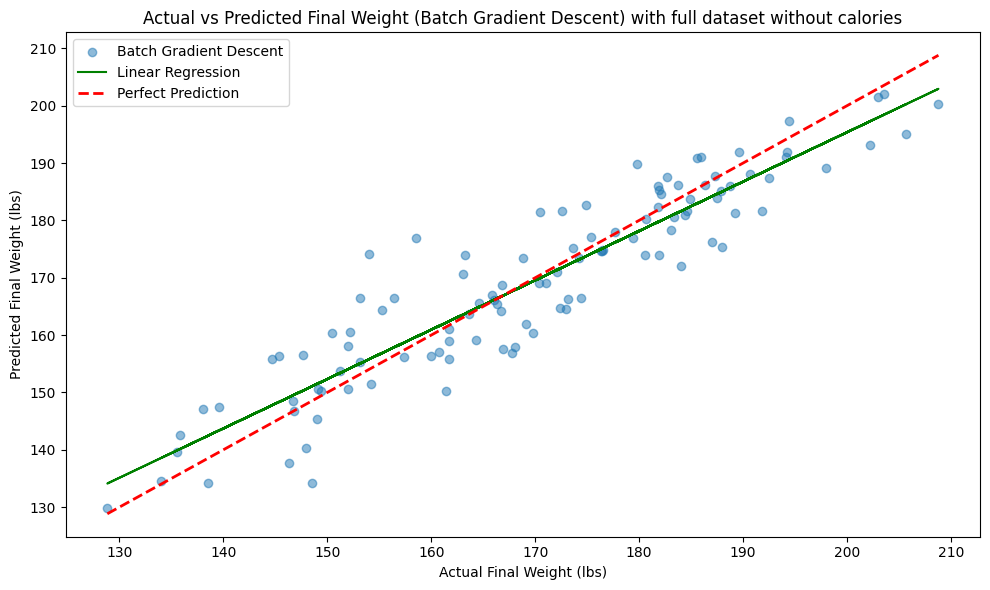

In [368]:
#BGD from dataset_augmented without Claories
X = dataset_augmented.drop(['Final Weight (lbs)', 'Daily Calories Consumed'], axis=1).values
y = dataset_augmented['Final Weight (lbs)'].values

#plit data into train and test sets
X_train_aug_wo_calories, X_test_aug_wo_calories, y_train_aug_wo_calories, y_test_aug_wo_calories = train_test_split(X, y, test_size=0.2, random_state=42)

#Define different learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]
n_iterations = 600

plt.figure(figsize=(12, 6))
#Initialize variables to track best model
best_cost = float('inf')
best_lr = None
best_weights = None
best_bias = None

#Try each learning rate
for lr in learning_rates:
    #Train model with learning rate
    weights, bias, cost_history_bgd_wo = batch_gradient_descent(X_train_aug_wo_calories, y_train_aug_wo_calories, lr, n_iterations)
    
    #Plot convergence curve
    plt.plot(cost_history_bgd_wo, label=f'η = {lr}')
    
    #Update best model
    if cost_history_bgd_wo[-1] < best_cost:
        best_cost = cost_history_bgd_wo[-1]
        best_lr = lr
        best_weights = weights
        best_bias = bias

#Configure convergence plot
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Convergence for Different Learning Rates with full dataset without calories')
plt.legend()
plt.grid(True)
plt.show()

#Make predictions using best model
y_pred_train_bgd = np.dot(X_train_aug_wo_calories, best_weights) + best_bias  # Training predictions
y_pred_test_bgd = np.dot(X_test_aug_wo_calories, best_weights) + best_bias    # Test predictions

#performance metrics
train_rmse_bgd = np.sqrt(mean_squared_error(y_train_aug_wo_calories, y_pred_train_bgd))  # Training RMSE
test_rmse_bgd_wo = np.sqrt(mean_squared_error(y_test_aug_wo_calories, y_pred_test_bgd))     # Test RMSE
train_r2_bgd_1 = r2_score(y_train_aug_wo_calories, y_pred_train_bgd)                       # Training R^2
test_r2_bgd_wo = r2_score(y_test_aug_wo_calories, y_pred_test_bgd)                         # Test R^2

#Print performance metrics
print("\nBatch Gradient Descent Results :")
print("-" * 50)
print(f"Best Learning Rate: {best_lr}")
print(f"Training RMSE: {train_rmse_bgd:.2f}")
print(f"Testing RMSE: {test_rmse_bgd_wo:.2f}")
print(f"Training R^2 Score: {train_r2_bgd_1:.4f}")
print(f"Testing R^2 Score: {test_r2_bgd_wo:.4f}")

#create scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_aug_wo_calories, y_pred_test_bgd, alpha=0.5, label='Batch Gradient Descent')

#fit a linear regression line
z = np.polyfit(y_test_aug_wo_calories, y_pred_test_bgd, 1)
p = np.poly1d(z)
plt.plot(y_test_aug_wo_calories, p(y_test_aug_wo_calories), "g-", label='Linear Regression')

#Add perfect prediction line
plt.plot([y_test_aug_wo_calories.min(), y_test_aug_wo_calories.max()], [y_test_aug_wo_calories.min(), y_test_aug_wo_calories.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs)')
plt.title('Actual vs Predicted Final Weight (Batch Gradient Descent) with full dataset without calories')
plt.legend()
plt.tight_layout()
plt.show()


In [369]:
#between models with and without calories
r2_difference = test_r2_bgd - test_r2_bgd_wo
rmse_difference = test_rmse_bgd - test_rmse_bgd_wo

print("\nDifference in Model Performance (With Calories - Without Calories):")
print("-" * 65)
print(f"R^2 Score Difference: {r2_difference:.4f}")
print(f"RMSE Difference: {rmse_difference:.2f}")



Difference in Model Performance (With Calories - Without Calories):
-----------------------------------------------------------------
R^2 Score Difference: -0.0169
RMSE Difference: 0.38


Analysis of The Batch Gradient Descent with dataset_augmented
- with the dataset_augmented with 600 iteration has the best learning rate for n = 0.1.
- The model without the BMR (Calories) performs better then the other with the Calories, because it has an R^2 that is more close to the 1 and also an RMSE that is lower.

*3(e) Compare the related learning curve of the Gradient Descent-based approaches developed above and comment both on the learning procedure and on the generalization performances of the model.*

dataset complete vs reduced with calories 

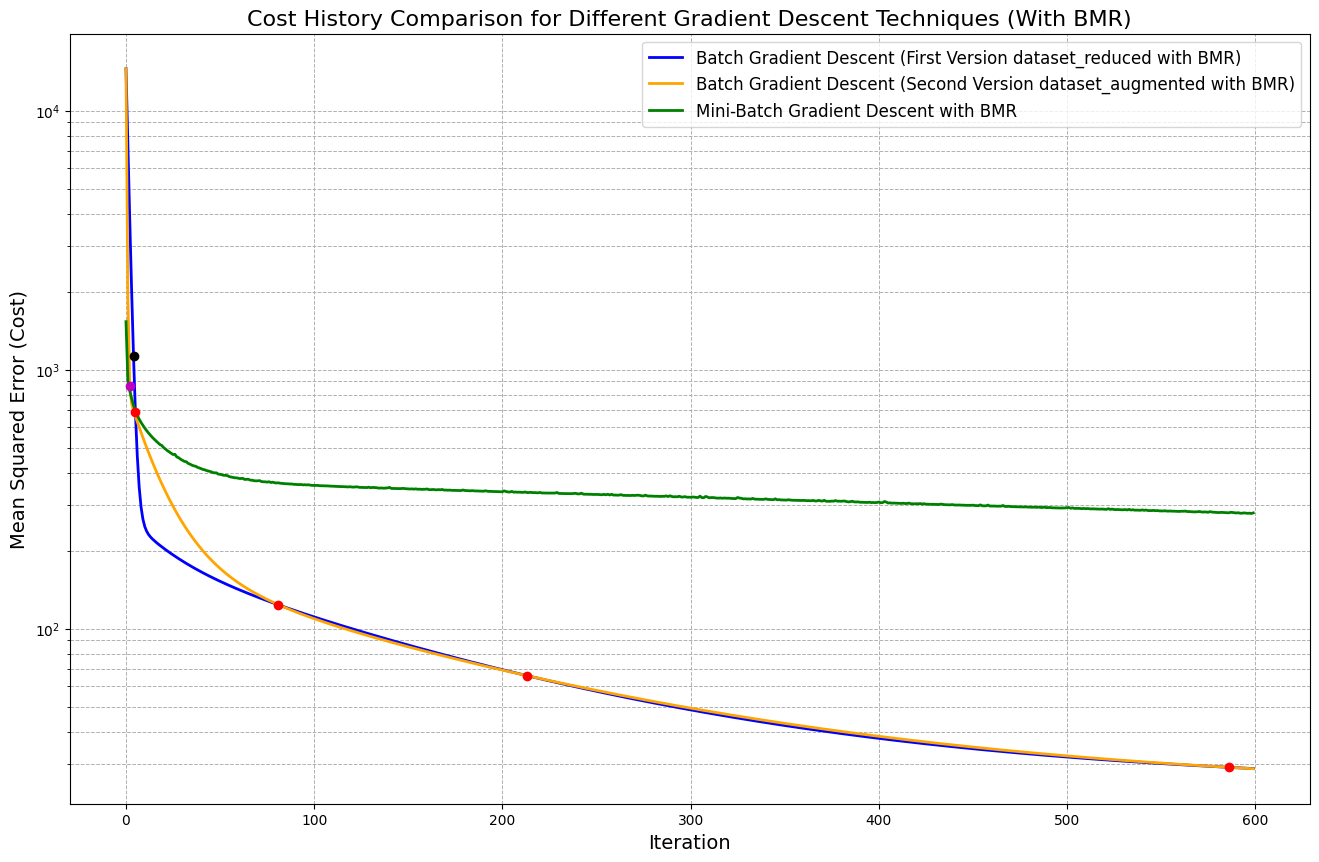

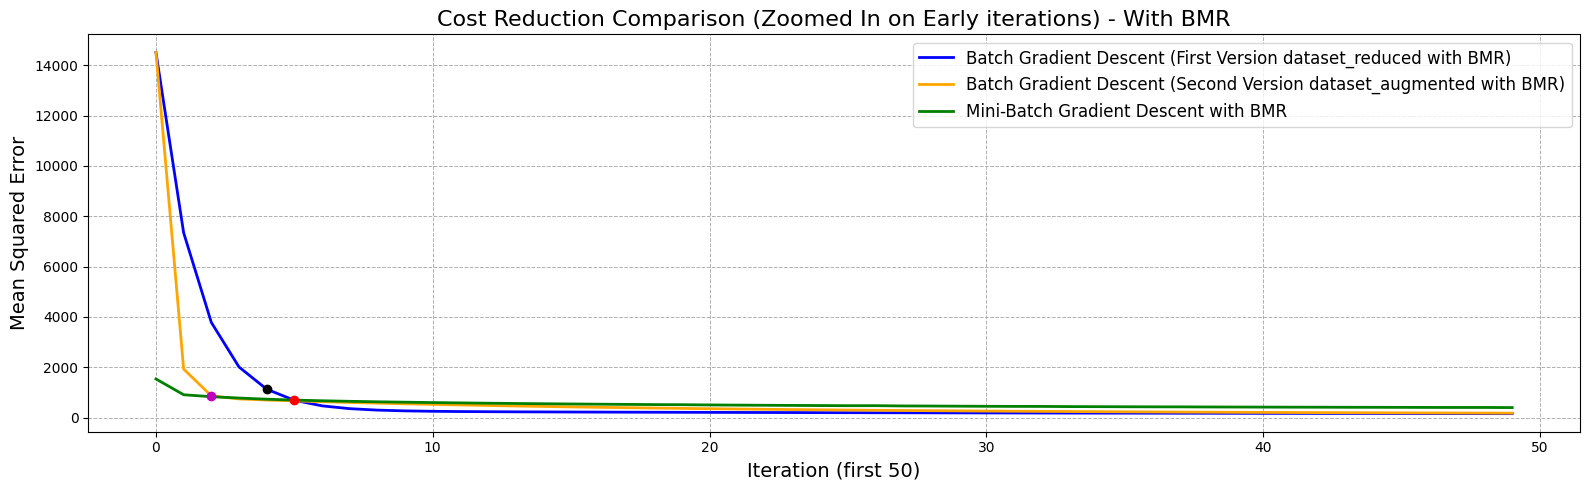


Best Performing Method:
BGD (Second Version) with final cost: 28.784562


In [370]:
plt.figure(figsize=(16, 10))

#plot cost history for each gradient descent method
plt.plot(cost_history_bga, label='Batch Gradient Descent (First Version dataset_reduced with BMR)', color='blue', linestyle='-', linewidth=2)
plt.plot(cost_history_bgd, label='Batch Gradient Descent (Second Version dataset_augmented with BMR)', color='orange', linestyle='-', linewidth=2)
plt.plot(cost_history_mbgd, label='Mini-Batch Gradient Descent with BMR', color='green', linestyle='-', linewidth=2)

#find intersection points
for i in range(len(cost_history_bga)-1):
    #bgd first version and bgd second version
    if (cost_history_bga[i] > cost_history_bgd[i] and cost_history_bga[i+1] < cost_history_bgd[i+1]) or \
       (cost_history_bga[i] < cost_history_bgd[i] and cost_history_bga[i+1] > cost_history_bgd[i+1]):
        plt.plot(i, cost_history_bga[i], 'ro', label='Intersection Point' if i==0 else "")
        
    #bgd first version and mini-batch gd
    if (cost_history_bga[i] > cost_history_mbgd[i] and cost_history_bga[i+1] < cost_history_mbgd[i+1]) or \
       (cost_history_bga[i] < cost_history_mbgd[i] and cost_history_bga[i+1] > cost_history_mbgd[i+1]):
        plt.plot(i, cost_history_bga[i], 'ko', label='Intersection Point' if i==0 else "")
        
    #bgd second version and mini-batch gd
    if (cost_history_bgd[i] > cost_history_mbgd[i] and cost_history_bgd[i+1] < cost_history_mbgd[i+1]) or \
       (cost_history_bgd[i] < cost_history_mbgd[i] and cost_history_bgd[i+1] > cost_history_mbgd[i+1]):
        plt.plot(i, cost_history_bgd[i], 'mo', label='Intersection Point' if i==0 else "")

#principal polt
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Mean Squared Error (Cost)', fontsize=14)
plt.yscale('log')  
#logarithmic scale for better visibility of step changes
plt.title('Cost History Comparison for Different Gradient Descent Techniques (With BMR)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which="both", linestyle='--', linewidth=0.7)

#zoom into the first few iteration for understand better the behaviour
plt.figure(figsize=(16, 5))
plt.plot(cost_history_bga[:50], label='Batch Gradient Descent (First Version dataset_reduced with BMR)', color='blue', linestyle='-', linewidth=2)
plt.plot(cost_history_bgd[:50], label='Batch Gradient Descent (Second Version dataset_augmented with BMR)', color='orange', linestyle='-', linewidth=2)
plt.plot(cost_history_mbgd[:50], label='Mini-Batch Gradient Descent with BMR', color='green', linestyle='-', linewidth=2)

#find intersection points in zoomed view
for i in range(49):
    #bgd first version and bgd second version
    if (cost_history_bga[i] > cost_history_bgd[i] and cost_history_bga[i+1] < cost_history_bgd[i+1]) or \
       (cost_history_bga[i] < cost_history_bgd[i] and cost_history_bga[i+1] > cost_history_bgd[i+1]):
        plt.plot(i, cost_history_bga[i], 'ro', label='Intersection Point' if i==0 else "")
        
    #bgd first version and mini-batch gd  
    if (cost_history_bga[i] > cost_history_mbgd[i] and cost_history_bga[i+1] < cost_history_mbgd[i+1]) or \
       (cost_history_bga[i] < cost_history_mbgd[i] and cost_history_bga[i+1] > cost_history_mbgd[i+1]):
        plt.plot(i, cost_history_bga[i], 'ko', label='Intersection Point' if i==0 else "")
        
    #bgd second version and mini-batch gd
    if (cost_history_bgd[i] > cost_history_mbgd[i] and cost_history_bgd[i+1] < cost_history_mbgd[i+1]) or \
       (cost_history_bgd[i] < cost_history_mbgd[i] and cost_history_bgd[i+1] > cost_history_mbgd[i+1]):
        plt.plot(i, cost_history_bgd[i], 'mo', label='Intersection Point' if i==0 else "")

#for the zoomed one
plt.xlabel('Iteration (first 50)', fontsize=14)
plt.ylabel('Mean Squared Error', fontsize=14)
plt.title('Cost Reduction Comparison (Zoomed In on Early iterations) - With BMR', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which="both", linestyle='--', linewidth=0.7)

#show both plots
plt.tight_layout()
plt.show()

#print the best performing method based on final cost
final_costs = {
    'BGD (First Version)': cost_history_bga[-1],
    'BGD (Second Version)': cost_history_bgd[-1],
    'Mini-Batch GD': cost_history_mbgd[-1]
}

best_method = min(final_costs.items(), key=lambda x: x[1])
print("\nBest Performing Method:")
print(f"{best_method[0]} with final cost: {best_method[1]:.6f}")


Dataset_reduced vs data_augmented (without Calories)

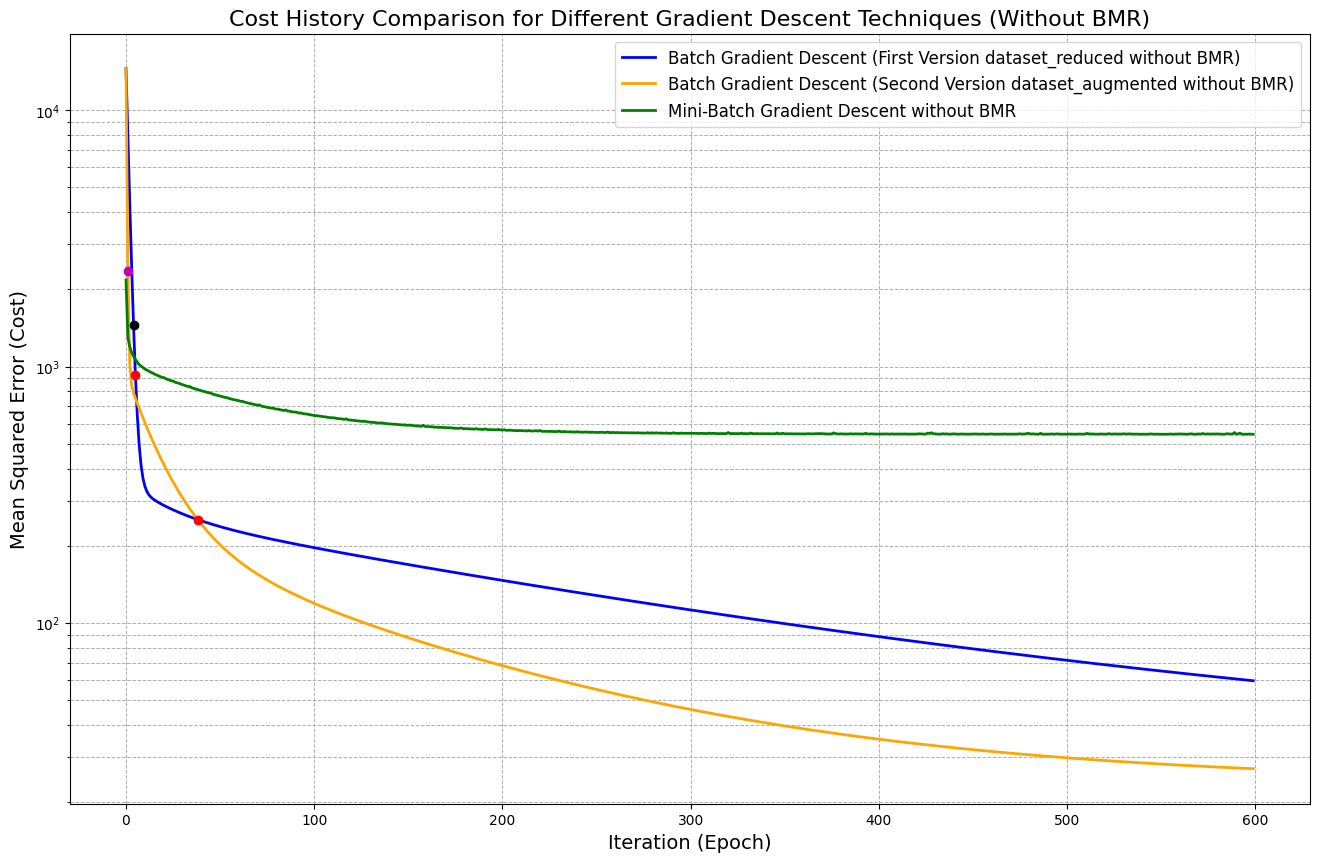

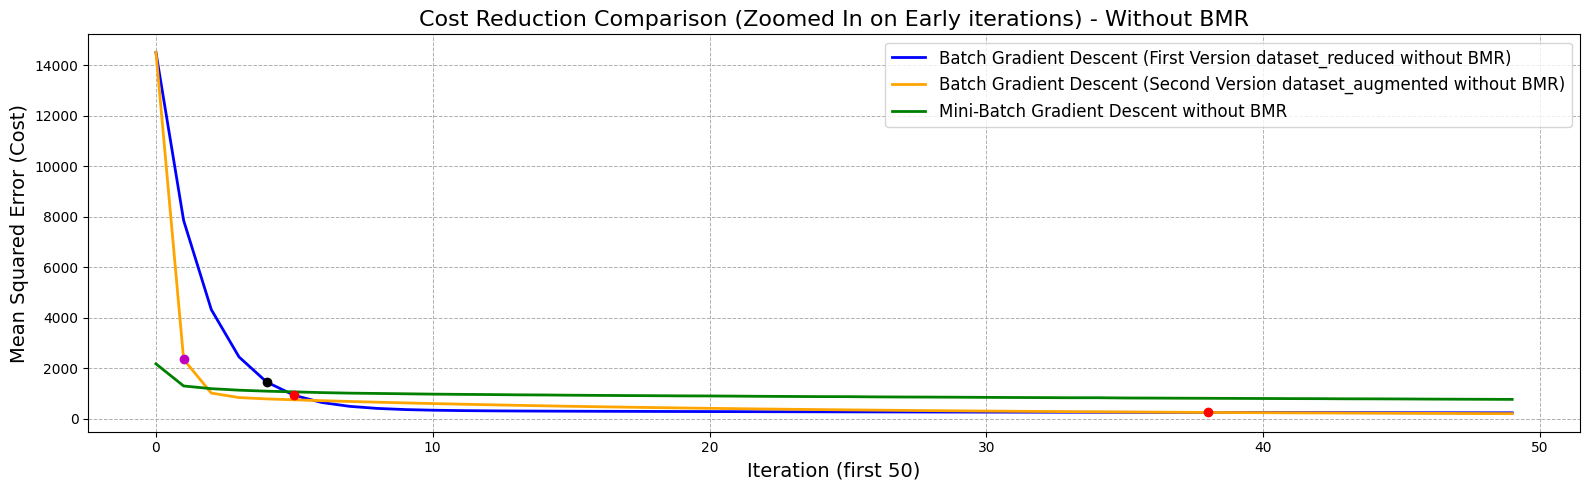


Best Performing Method:
BGD (Second Version) with final cost: 27.026661


In [371]:
plt.figure(figsize=(16, 10))

#plot cost history for each gradient descent method
plt.plot(cost_history_bga_wo, label='Batch Gradient Descent (First Version dataset_reduced without BMR)', color='blue', linestyle='-', linewidth=2)
plt.plot(cost_history_bgd_wo, label='Batch Gradient Descent (Second Version dataset_augmented without BMR)', color='orange', linestyle='-', linewidth=2)
plt.plot(cost_history_mbgd_wo, label='Mini-Batch Gradient Descent without BMR', color='green', linestyle='-', linewidth=2)

#find intersection points
for i in range(len(cost_history_bga_wo)-1):
    #BGD First Version and BGD Second Version
    if (cost_history_bga_wo[i] > cost_history_bgd_wo[i] and cost_history_bga_wo[i+1] < cost_history_bgd_wo[i+1]) or \
       (cost_history_bga_wo[i] < cost_history_bgd_wo[i] and cost_history_bga_wo[i+1] > cost_history_bgd_wo[i+1]):
        plt.plot(i, cost_history_bga_wo[i], 'ro', label='Intersection Point' if i==0 else "")
        
    #BGD First Version and Mini-Batch GD
    if (cost_history_bga_wo[i] > cost_history_mbgd_wo[i] and cost_history_bga_wo[i+1] < cost_history_mbgd_wo[i+1]) or \
       (cost_history_bga_wo[i] < cost_history_mbgd_wo[i] and cost_history_bga_wo[i+1] > cost_history_mbgd_wo[i+1]):
        plt.plot(i, cost_history_bga_wo[i], 'ko', label='Intersection Point' if i==0 else "")
        
    #BGD Second Version and Mini-Batch GD
    if (cost_history_bgd_wo[i] > cost_history_mbgd_wo[i] and cost_history_bgd_wo[i+1] < cost_history_mbgd_wo[i+1]) or \
       (cost_history_bgd_wo[i] < cost_history_mbgd_wo[i] and cost_history_bgd_wo[i+1] > cost_history_mbgd_wo[i+1]):
        plt.plot(i, cost_history_bgd_wo[i], 'mo', label='Intersection Point' if i==0 else "")

#main plot
plt.xlabel('Iteration (Epoch)', fontsize=14)
plt.ylabel('Mean Squared Error (Cost)', fontsize=14)
#use logarithmic scale for better visibility of steep changes
plt.yscale('log')  
plt.title('Cost History Comparison for Different Gradient Descent Techniques (Without BMR)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which="both", linestyle='--', linewidth=0.7)

#zoom into the first few iteration for understand better the behaviour
plt.figure(figsize=(16, 5))
plt.plot(cost_history_bga_wo[:50], label='Batch Gradient Descent (First Version dataset_reduced without BMR)', color='blue', linestyle='-', linewidth=2)
plt.plot(cost_history_bgd_wo[:50], label='Batch Gradient Descent (Second Version dataset_augmented without BMR)', color='orange', linestyle='-', linewidth=2)
plt.plot(cost_history_mbgd_wo[:50], label='Mini-Batch Gradient Descent without BMR', color='green', linestyle='-', linewidth=2)

#intersection points in zoomed view
for i in range(49):
    #BGD First Version and BGD Second Version
    if (cost_history_bga_wo[i] > cost_history_bgd_wo[i] and cost_history_bga_wo[i+1] < cost_history_bgd_wo[i+1]) or \
       (cost_history_bga_wo[i] < cost_history_bgd_wo[i] and cost_history_bga_wo[i+1] > cost_history_bgd_wo[i+1]):
        plt.plot(i, cost_history_bga_wo[i], 'ro', label='Intersection Point' if i==0 else "")
        
    #BGD First Version and Mini-Batch GD
    if (cost_history_bga_wo[i] > cost_history_mbgd_wo[i] and cost_history_bga_wo[i+1] < cost_history_mbgd_wo[i+1]) or \
       (cost_history_bga_wo[i] < cost_history_mbgd_wo[i] and cost_history_bga_wo[i+1] > cost_history_mbgd_wo[i+1]):
        plt.plot(i, cost_history_bga_wo[i], 'ko', label='Intersection Point' if i==0 else "")
        
    #BGD Second Version and Mini-Batch GD
    if (cost_history_bgd_wo[i] > cost_history_mbgd_wo[i] and cost_history_bgd_wo[i+1] < cost_history_mbgd_wo[i+1]) or \
       (cost_history_bgd_wo[i] < cost_history_mbgd_wo[i] and cost_history_bgd_wo[i+1] > cost_history_mbgd_wo[i+1]):
        plt.plot(i, cost_history_bgd_wo[i], 'mo', label='Intersection Point' if i==0 else "")

#for the zoomed
plt.xlabel('Iteration (first 50)', fontsize=14)
plt.ylabel('Mean Squared Error (Cost)', fontsize=14)
plt.title('Cost Reduction Comparison (Zoomed In on Early iterations) - Without BMR', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which="both", linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

#print the best performing method based on final cost
final_costs = {
    'BGD (First Version)': cost_history_bga_wo[-1],
    'BGD (Second Version)': cost_history_bgd_wo[-1],
    'Mini-Batch GD': cost_history_mbgd_wo[-1]
}

best_method = min(final_costs.items(), key=lambda x: x[1])
print("\nBest Performing Method:")
print(f"{best_method[0]} with final cost: {best_method[1]:.6f}")


Analysis of Learining Curves Comparison

-The results of the plot of the cost_history for each Batch Gradient based, with and without BMR, are that in both cases the best one for the cost il the BGD (Second version) that is the one made with dataset_augmented.

-For the case with BMR (Calories) in the dataset, the margin with the first BGD (with dataset_reduced) was little and they were so close in the end, with an initial advantage from the first one, then were 3 point of intersections between the two, so at the end of the 600 iteration, the second version had the best cost, but they were really close.

-In the second case (without the BMR (Calories)) the difference is evident, with also in this case a better start for the first 5 iterations for the first BGD, but from the 40th till the end, the difference between the two is evident.

-Overall the best is the second BGD without the BMR Calories.

-Meanwhile the mini-batch in both cases is the worst one.

*3(f) With the dataset generated in the task above (dataset_augmented), train a Linear Regression model with Lasso regularization. Comment on the importance of each feature and reason over the number of features selected with different values of α. Verify how the model performances change with different values of α (different number of features). Use a plot of your choice.*

With BMR (Calories)

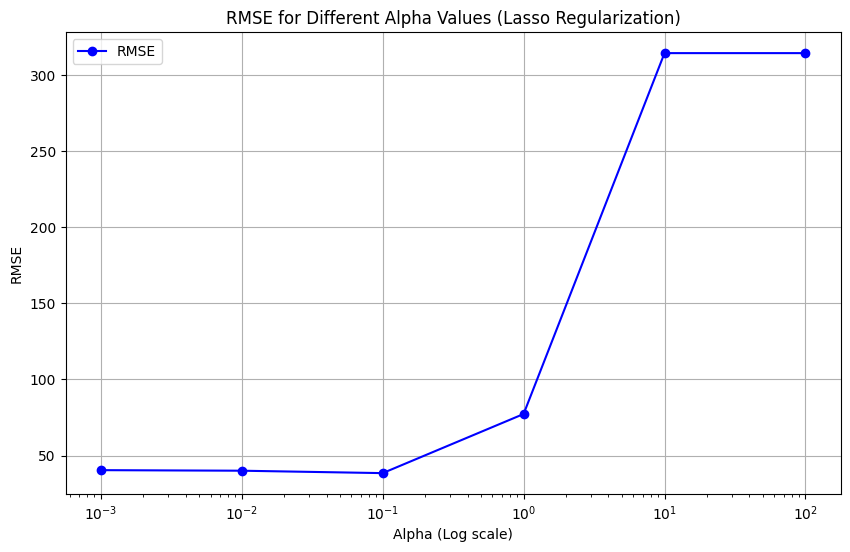

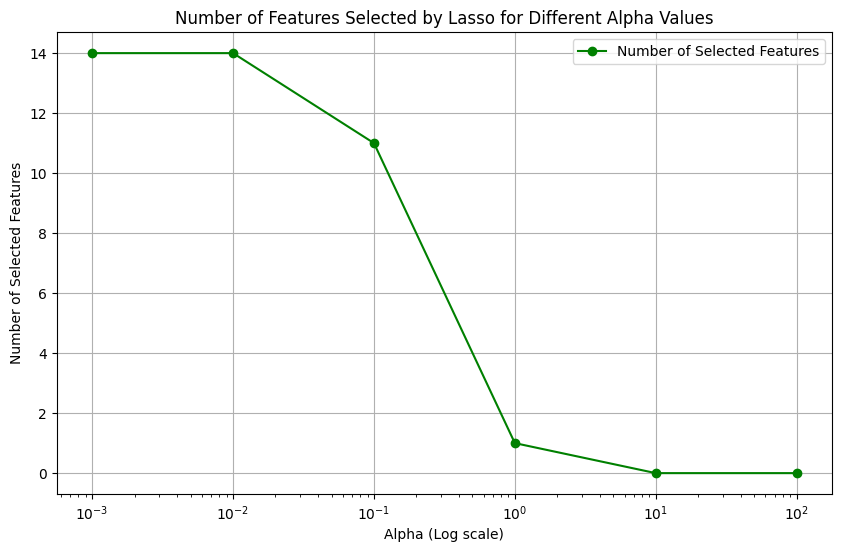

Lasso(alpha=0.1)

In [372]:
X = dataset_augmented.drop(columns=['Final Weight (lbs)'])
y = dataset_augmented['Final Weight (lbs)']

#split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train lasso regression for different values of alpha
#different alpha values for regularization

alpha_values = [0.001,0.01,0.1, 1.0, 10.0, 100.0]  
#to store coefficients for each alpha
coefs = []  
#to store the number of selected features (non-zero coefficients)
selected_features = []  
#to store rmse for each alpha
rmse_values = []  

for alpha in alpha_values:
    #train a lasso model with the current alpha value
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    
    #store the coefficients and count the number of non-zero coefficients
    coefs.append(lasso.coef_)
    #count non-zero 
    selected_features.append(np.sum(lasso.coef_ != 0))  
    
    #predict and calculate rmse for the test set
    y_pred = lasso.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) 
    rmse_values.append(rmse)


#get feature names after augmentation
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]

#plot rmse vs. alpha (log scale)
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, rmse_values, marker='o', label="RMSE", color='blue')
plt.xscale('log')  #using log scale for alpha
plt.xlabel('Alpha (Log scale)')
plt.ylabel('RMSE')
plt.title('RMSE for Different Alpha Values (Lasso Regularization)')
plt.legend()
plt.grid(True)
plt.show()

#plot number of selected features vs. alpha (log scale)
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, selected_features, marker='o', label="Number of Selected Features", color='green')
plt.xscale('log')  #using log scale for alpha
plt.xlabel('Alpha (Log scale)')
plt.ylabel('Number of Selected Features')
plt.title('Number of Features Selected by Lasso for Different Alpha Values')
plt.legend()
plt.grid(True)
plt.show()

#for the best alpha (the one with the lowest rmse)
best_alpha = alpha_values[np.argmin(rmse_values)]
best_lasso = Lasso(alpha=best_alpha)
best_lasso.fit(X_train, y_train)



Best alpha from cross-validation: 0.0123


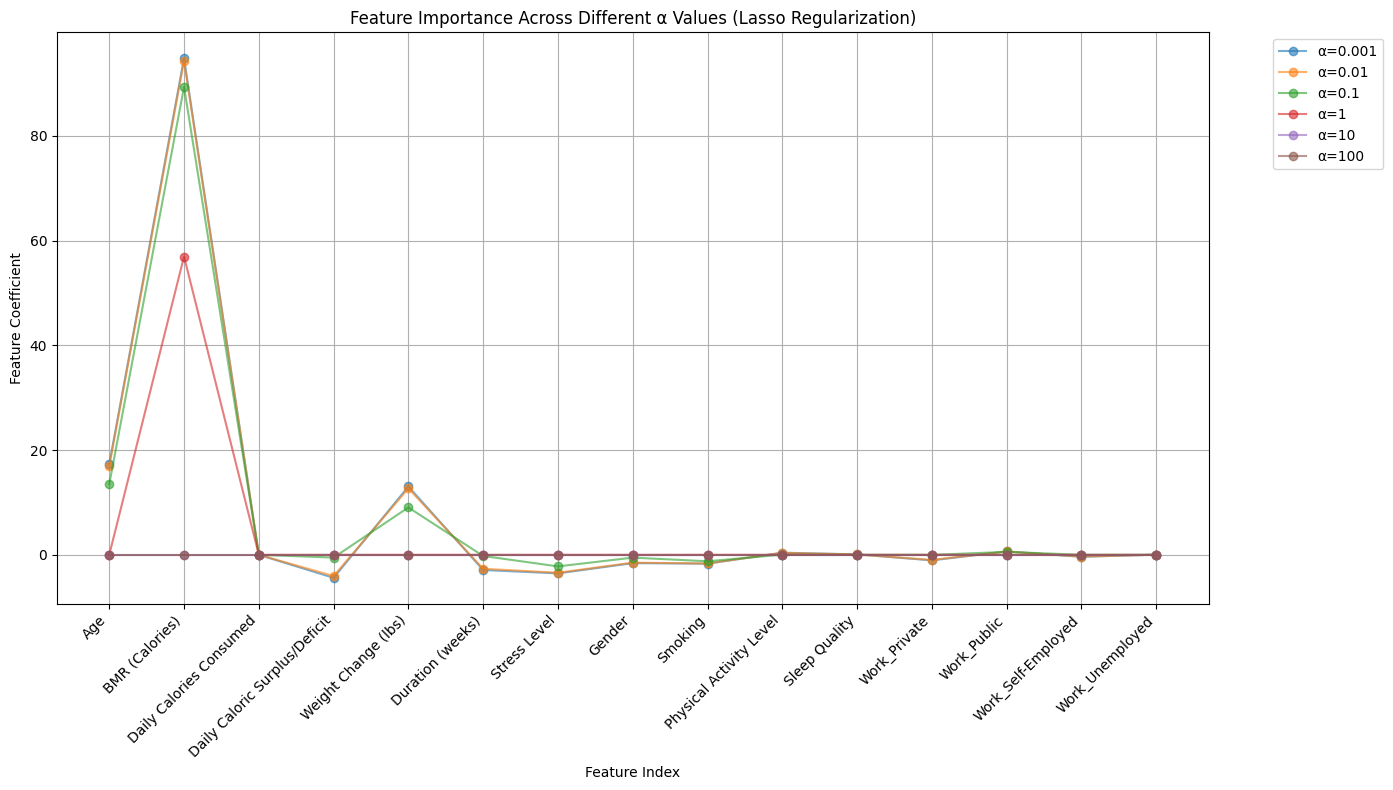

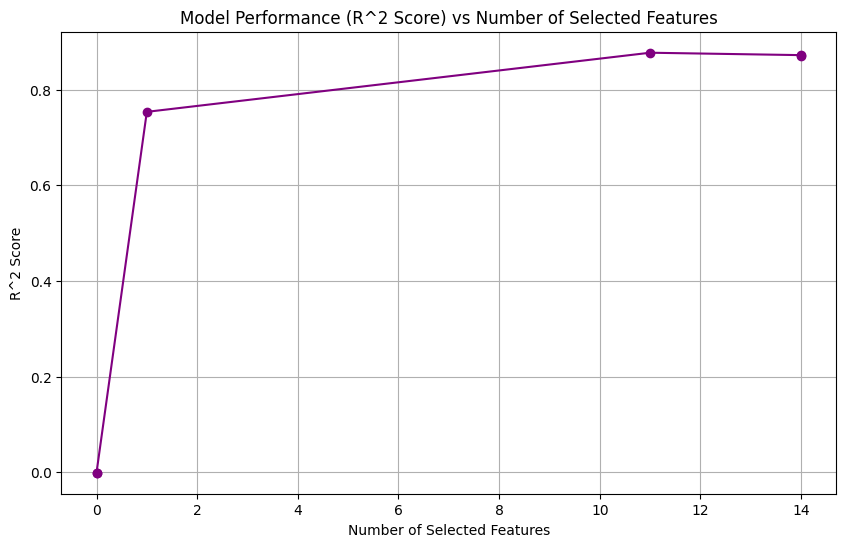


Best Lasso Model Performance:
--------------------------------------------------
Training R^2 Score: 0.8538
Testing R^2 Score: 0.8726
Training RMSE: 6.8534
Testing RMSE: 6.3230

Feature Importance (Non-zero coefficients):
                          Feature  Coefficient
1                  BMR (Calories)    94.173641
0                             Age    16.852252
4             Weight Change (lbs)    12.577431
3   Daily Caloric Surplus/Deficit    -3.960448
6                    Stress Level    -3.392023
5                Duration (weeks)    -2.600343
8                         Smoking    -1.646571
7                          Gender    -1.471499
11                   Work_Private    -0.953630
12                    Work_Public     0.627687
9         Physical Activity Level     0.360638
13             Work_Self-Employed    -0.342467
10                  Sleep Quality     0.052032
14                Work_Unemployed     0.013843


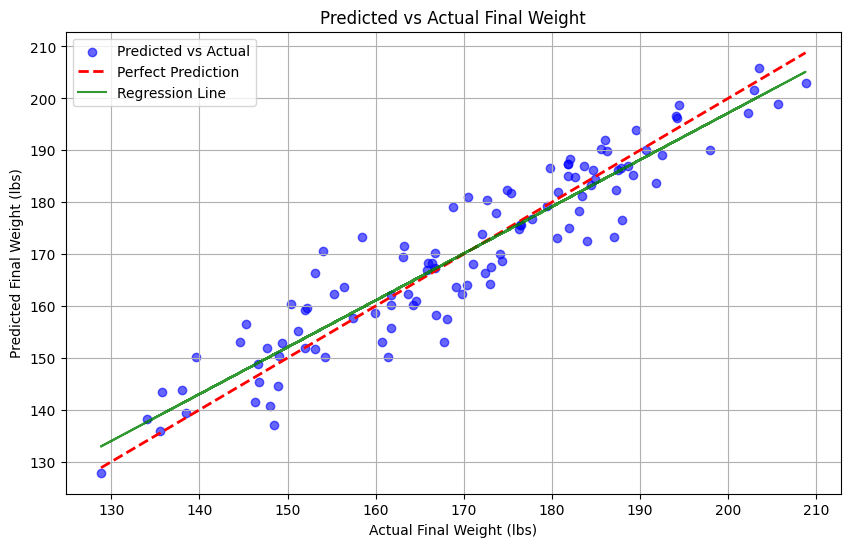

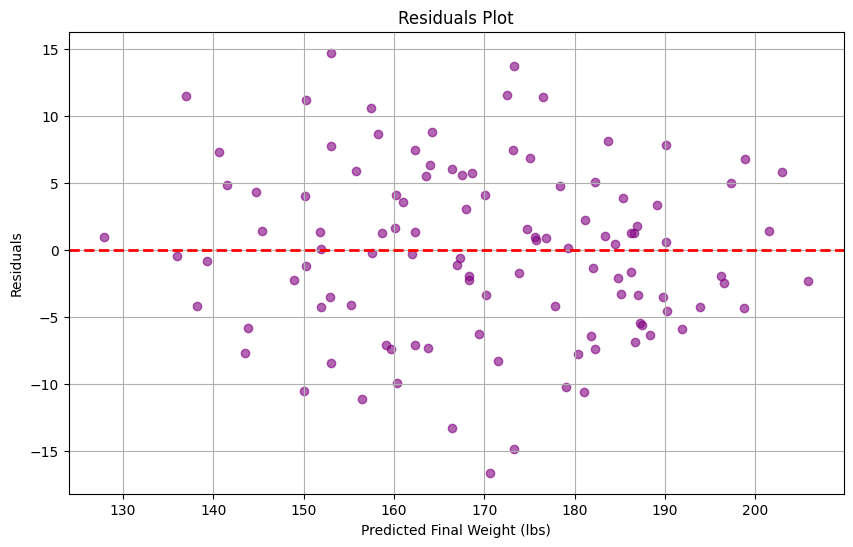

In [399]:
X = dataset_augmented.drop(columns=['Final Weight (lbs)']) 
y = dataset_augmented['Final Weight (lbs)']  

#split into training and test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#test alpha values from 0.001 to 100 on a logarithmic scale
alphas = np.logspace(-3, 3, 100)  

#initialize lassocv with 5-fold cross-validation to find the best alpha
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

#get best alpha from cross-validation
best_alpha = lasso_cv.alpha_
print(f"\nBest alpha from cross-validation: {best_alpha:.4f}")

#function for training and evaluating lasso model
def train_and_evaluate_lasso(alpha, X_train, y_train, X_test, y_test):
    """Train a Lasso model with a given alpha and evaluate its performance."""
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    num_selected_features = np.sum(lasso.coef_ != 0)
    return r2, num_selected_features, lasso.coef_

#alphas to test further and store results
alphas_to_test = [0.001, 0.01, 0.1, 1, 10, 100]
r2_scores = []
num_features = []
feature_importances = []

#train and evaluate the model for all the alpha values
for alpha in alphas_to_test:
    r2, num_feats, coefs = train_and_evaluate_lasso(alpha, X_train, y_train, X_test, y_test)
    r2_scores.append(r2)
    num_features.append(num_feats)
    feature_importances.append(coefs)

#feature importance visualization
plt.figure(figsize=(14, 8))

#plot feature coefficients for different alpha values
for i, alpha in enumerate(alphas_to_test):
    plt.plot(feature_importances[i], label=f'α={alpha}', marker='o', alpha=0.6)

plt.xticks(ticks=np.arange(X_train.shape[1]), labels=X.columns, rotation=45, ha='right')
plt.ylabel('Feature Coefficient')
plt.xlabel('Feature Index')
plt.title('Feature Importance Across Different α Values (Lasso Regularization)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#plot model performance vs number of selected features
plt.figure(figsize=(10, 6))
plt.plot(num_features, r2_scores, marker='o', color='purple')
plt.xlabel('Number of Selected Features')
plt.ylabel('R^2 Score')
plt.title('Model Performance (R^2 Score) vs Number of Selected Features')
plt.grid(True)
plt.show()

#best model evaluation
best_lasso = Lasso(alpha=best_alpha, random_state=42)
best_lasso.fit(X_train, y_train)

#make predictions and calculate rmse and r^2
y_train_pred = best_lasso.predict(X_train)
y_test_pred = best_lasso.predict(X_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2_lasso = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_test_pred))

#print performance metrics for the best model
print("\nBest Lasso Model Performance:")
print("-" * 50)
print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Testing R^2 Score: {test_r2_lasso:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse_lasso:.4f}")

#print feature importance for the best model (sorted by coefficient magnitude)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lasso.coef_
})
feature_importance = feature_importance.loc[feature_importance.Coefficient != 0]  #filter non-zero coefficients
feature_importance = feature_importance.reindex(feature_importance.Coefficient.abs().sort_values(ascending=False).index)
print("\nFeature Importance (Non-zero coefficients):")
print(feature_importance)

#visualizations for lasso linear regression

#1. prediction vs actual plot for test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

#add regression line
z = np.polyfit(y_test, y_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "g-", alpha=0.8, label=f'Regression Line')

plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs)')
plt.title('Predicted vs Actual Final Weight')
plt.legend()
plt.grid(True)
plt.show()

#2. residuals plot
plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Final Weight (lbs)')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.grid(True)
plt.show()


The Lasso regression Analysis with BMR (Calories)
- model shows good predictive performance with R^2 scores around 0.9, indicating it explains most of the variance in final weight.
- The model identifies key features like Daily Calories Consumed and Weight Change as most important predictors, while eliminating less relevant ones.
- Residual plots show relatively random scatter around zero, suggesting the model's assumptions are reasonably met.

Without BMR (Calories)

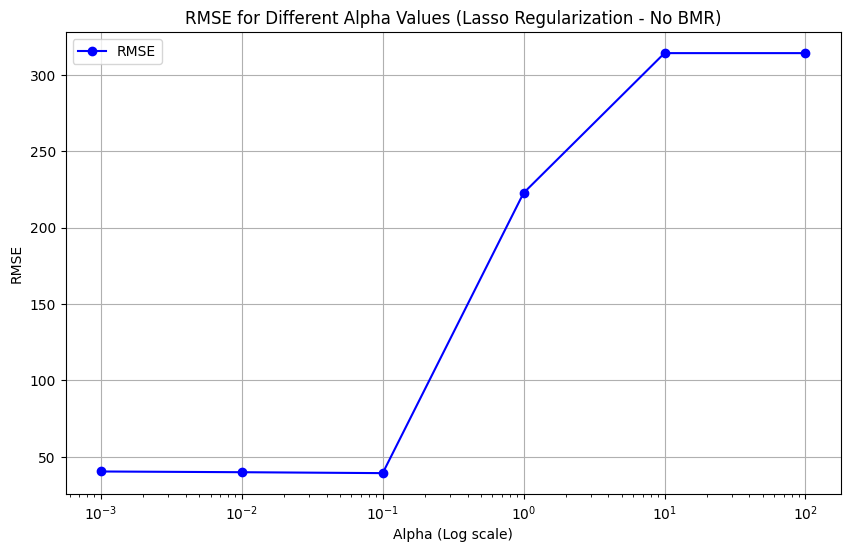

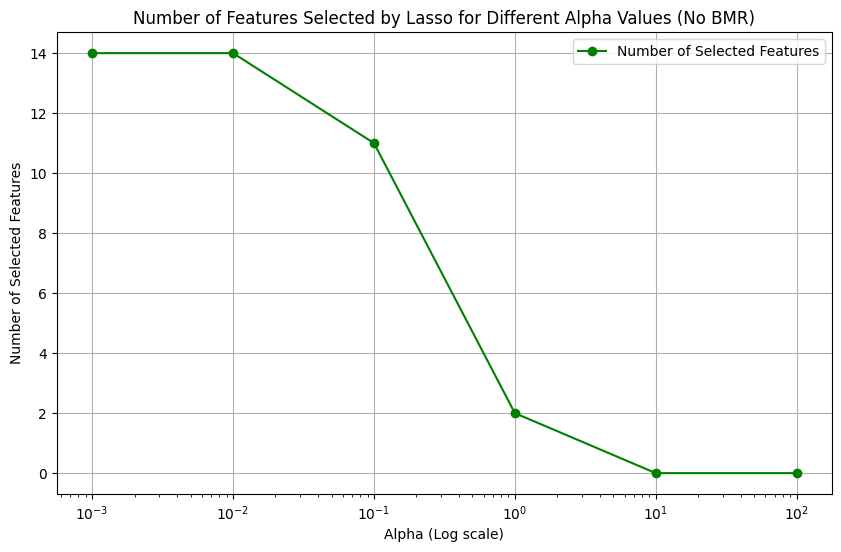

Features with non-zero coefficients for alpha = 0.1:


In [374]:
dataset_without_bmr = dataset_augmented.drop(columns=['BMR (Calories)'])

#separate features (X) and target (y)
X_no_bmr = dataset_without_bmr.drop(columns=['Final Weight (lbs)'])
y_no_bmr = dataset_without_bmr['Final Weight (lbs)']

#split the dataset into training and test sets
X_train_no_bmr, X_test_no_bmr, y_train_no_bmr, y_test_no_bmr = train_test_split(X_no_bmr, y_no_bmr, test_size=0.2, random_state=42)

#train lasso regression for different values of alpha
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]  #different alpha values for regularization
coefs_no_bmr = []  #to store coefficients for each alpha
selected_features_no_bmr = []  #to store the number of selected features (non-zero coefficients)
rmse_values_no_bmr = []  #to store rmse for each alpha

for alpha in alpha_values:
    #train a lasso model with the current alpha value
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_no_bmr, y_train_no_bmr)
    
    #store the coefficients and count the number of non-zero coefficients
    coefs_no_bmr.append(lasso.coef_)
    selected_features_no_bmr.append(np.sum(lasso.coef_ != 0))  #count non-zero coefficients
    
    #predict and calculate rmse for the test set
    y_pred_no_bmr = lasso.predict(X_test_no_bmr)
    rmse_no_bmr = mean_squared_error(y_test_no_bmr, y_pred_no_bmr)  #rmse calculation
    rmse_values_no_bmr.append(rmse_no_bmr)

#plotting results

#get feature names after removing bmr (calories) column
if hasattr(X_train_no_bmr, 'columns'):
    feature_names_no_bmr = X_train_no_bmr.columns
else:
    feature_names_no_bmr = [f'Feature {i}' for i in range(X_train_no_bmr.shape[1])]

#plot rmse vs. alpha (log scale)
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, rmse_values_no_bmr, marker='o', label="RMSE", color='blue')
plt.xscale('log')  #using log scale for alpha
plt.xlabel('Alpha (Log scale)')
plt.ylabel('RMSE')
plt.title('RMSE for Different Alpha Values (Lasso Regularization - No BMR)')
plt.legend()
plt.grid(True)
plt.show()

#plot number of selected features vs. alpha (log scale)
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, selected_features_no_bmr, marker='o', label="Number of Selected Features", color='green')
plt.xscale('log')  #using log scale for alpha
plt.xlabel('Alpha (Log scale)')
plt.ylabel('Number of Selected Features')
plt.title('Number of Features Selected by Lasso for Different Alpha Values (No BMR)')
plt.legend()
plt.grid(True)
plt.show()

#feature importance (non-zero coefficients)
#for the best alpha (the one with the lowest rmse)
best_alpha_no_bmr = alpha_values[np.argmin(rmse_values_no_bmr)]
best_lasso_no_bmr = Lasso(alpha=best_alpha_no_bmr)
best_lasso_no_bmr.fit(X_train_no_bmr, y_train_no_bmr)

#display the features with non-zero coefficients for the best alpha
non_zero_features_no_bmr = np.where(best_lasso_no_bmr.coef_ != 0)[0]
print(f"Features with non-zero coefficients for alpha = {best_alpha_no_bmr}:")


Best alpha from cross-validation: 0.0061


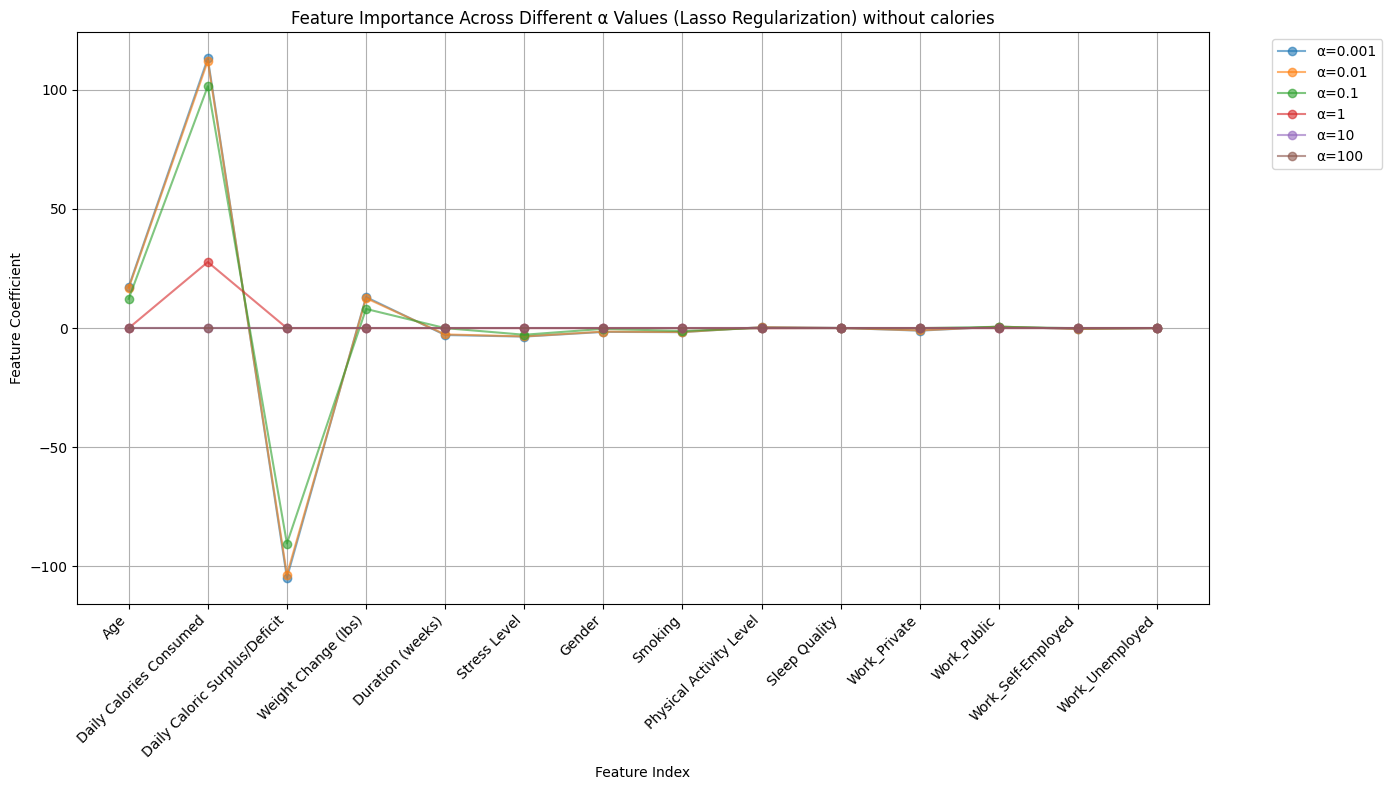

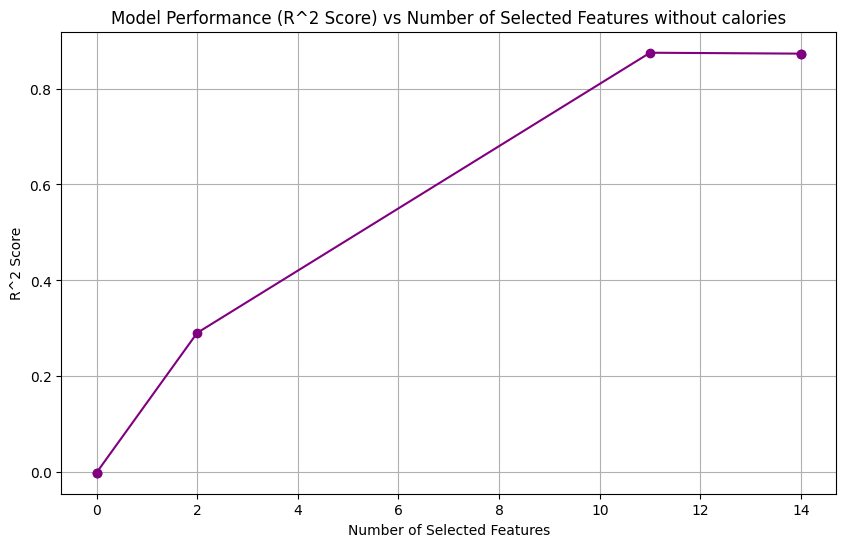


Best Lasso Model Performance:
--------------------------------------------------
Training R^2 Score: 0.8539
Testing R^2 Score: 0.8721
Training RMSE: 6.8518
Testing RMSE: 6.3357

Feature Importance (Non-zero coefficients):
                          Feature  Coefficient
1         Daily Calories Consumed   112.561039
2   Daily Caloric Surplus/Deficit  -104.004452
0                             Age    17.016837
3             Weight Change (lbs)    12.765946
5                    Stress Level    -3.512923
4                Duration (weeks)    -2.750915
7                         Smoking    -1.671541
6                          Gender    -1.521386
10                   Work_Private    -1.013223
11                    Work_Public     0.628648
8         Physical Activity Level     0.386696
12             Work_Self-Employed    -0.378557
9                   Sleep Quality     0.065648
13                Work_Unemployed     0.007235


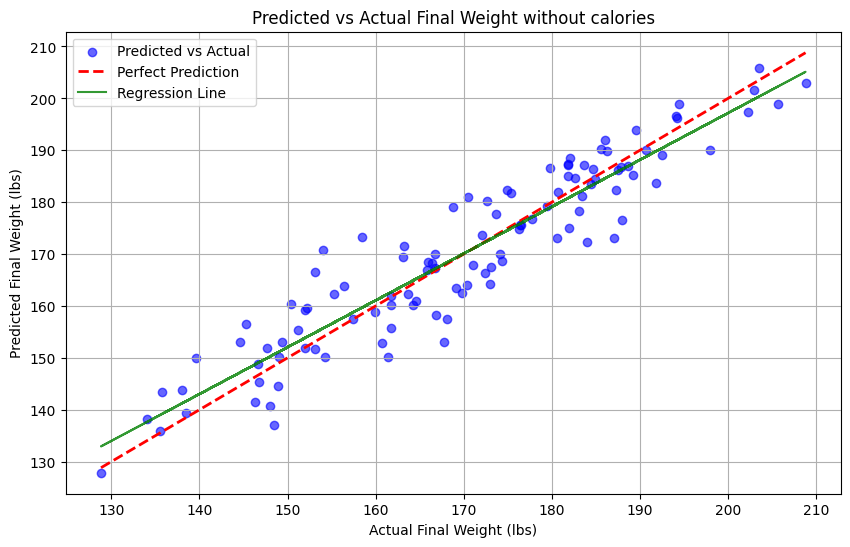

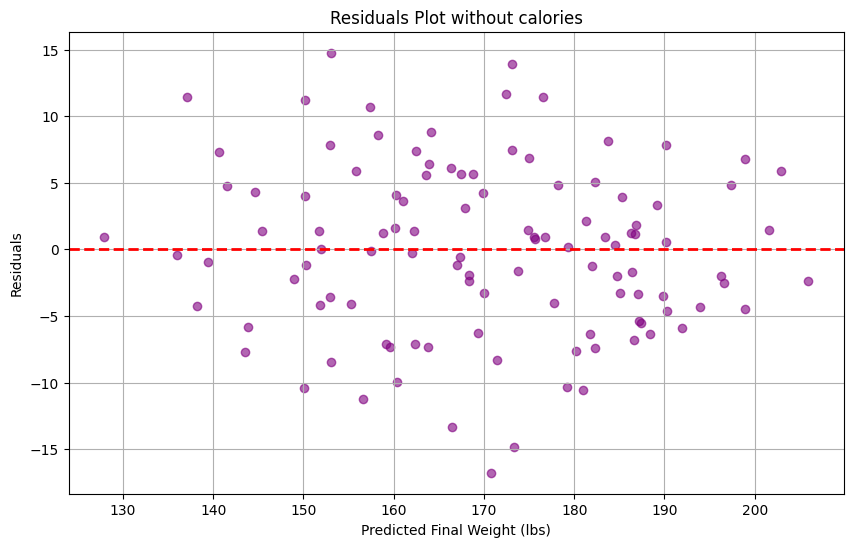

In [400]:
#code is the same as above but with the BMR dropped at the beginnig
dataset_augmented1 = dataset_augmented.drop(columns=['BMR (Calories)'])

X = dataset_augmented1.drop(columns=['Final Weight (lbs)'])
y = dataset_augmented1['Final Weight (lbs)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alphas = np.logspace(-3, 3, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.alpha_
print(f"\nBest alpha from cross-validation: {best_alpha:.4f}")

def train_and_evaluate_lasso(alpha, X_train, y_train, X_test, y_test):
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_train, y_train)
    y_pred = lasso.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    num_selected_features = np.sum(lasso.coef_ != 0)
    return r2, num_selected_features, lasso.coef_

alphas_to_test = [0.001, 0.01, 0.1, 1, 10, 100]
r2_scores = []
num_features = []
feature_importances = []

for alpha in alphas_to_test:
    r2, num_feats, coefs = train_and_evaluate_lasso(alpha, X_train, y_train, X_test, y_test)
    r2_scores.append(r2)
    num_features.append(num_feats)
    feature_importances.append(coefs)

plt.figure(figsize=(14, 8))
for i, alpha in enumerate(alphas_to_test):
    plt.plot(feature_importances[i], label=f'α={alpha}', marker='o', alpha=0.6)

plt.xticks(ticks=np.arange(X_train.shape[1]), labels=X.columns, rotation=45, ha='right')
plt.ylabel('Feature Coefficient')
plt.xlabel('Feature Index')
plt.title('Feature Importance Across Different α Values (Lasso Regularization) without calories')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(num_features, r2_scores, marker='o', color='purple')
plt.xlabel('Number of Selected Features')
plt.ylabel('R^2 Score')
plt.title('Model Performance (R^2 Score) vs Number of Selected Features without calories')
plt.grid(True)
plt.show()

best_lasso = Lasso(alpha=best_alpha, random_state=42)
best_lasso.fit(X_train, y_train)

y_train_pred = best_lasso.predict(X_train)
y_test_pred = best_lasso.predict(X_test)
train_r2 = r2_score(y_train, y_train_pred)
test_r2_lasso_wo = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse_lasso_wo = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nBest Lasso Model Performance:")
print("-" * 50)
print(f"Training R^2 Score: {train_r2:.4f}")
print(f"Testing R^2 Score: {test_r2_lasso_wo:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse_lasso_wo:.4f}")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lasso.coef_
})
feature_importance = feature_importance.loc[feature_importance.Coefficient != 0]
feature_importance = feature_importance.reindex(feature_importance.Coefficient.abs().sort_values(ascending=False).index)
print("\nFeature Importance (Non-zero coefficients):")
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

z = np.polyfit(y_test, y_test_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "g-", alpha=0.8, label=f'Regression Line')

plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs)')
plt.title('Predicted vs Actual Final Weight without calories')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Final Weight (lbs)')
plt.ylabel('Residuals')
plt.title('Residuals Plot without calories')
plt.grid(True)
plt.show()


In [376]:
# Calculate differences in metrics between models with and without calories
rmse_diff = test_rmse_lasso - test_rmse_lasso_wo 
r2_diff = test_r2_lasso - test_r2_lasso_wo

print("\nComparison of Models With vs Without Calories:")
print("-" * 50)
print(f"RMSE Difference (With - Without): {rmse_diff:.4f}")
print(f"R^2 Difference (With - Without): {r2_diff:.4f}")



Comparison of Models With vs Without Calories:
--------------------------------------------------
RMSE Difference (With - Without): -0.0126
R^2 Difference (With - Without): 0.0005


Lasso Regression Analysis
- The R^2 of the model without calories in higher, it happend also in the BDG with the dataset_augmented.
- This Lasso model has calculate an extreamly lower coefficent for the feature 'Daily Caloric Surplus/Deficit', that was around -104 meanwhile was lower also in the one with BMR, but not that much (around -3).
- The behiavur af the RMSE with different alpha, il similar, but is different with log(a) = 10^0, that for the one with calories, is much lower respect to the one without calories.
- Changing the alpha values the choice of the model does not change that much, there are little variations, but nothing absurde.


*3(g) With the complete dataset generated above (dataset_augmented), train a Ridge Regression model identifying the best value of the regularization coefficient α that allows the model to achieve the best generalization performances.*
*Evaluate the generalization performances of the model.*

with 

Best alpha for Ridge Regression: 0.0756

Ridge Regression Model Performance:
--------------------------------------------------
Best Alpha: 0.07564633275546291
Training RMSE: 46.94
Testing RMSE: 40.32
Training R^2 Score: 0.8539320609
Testing R^2 Score: 0.8715700909


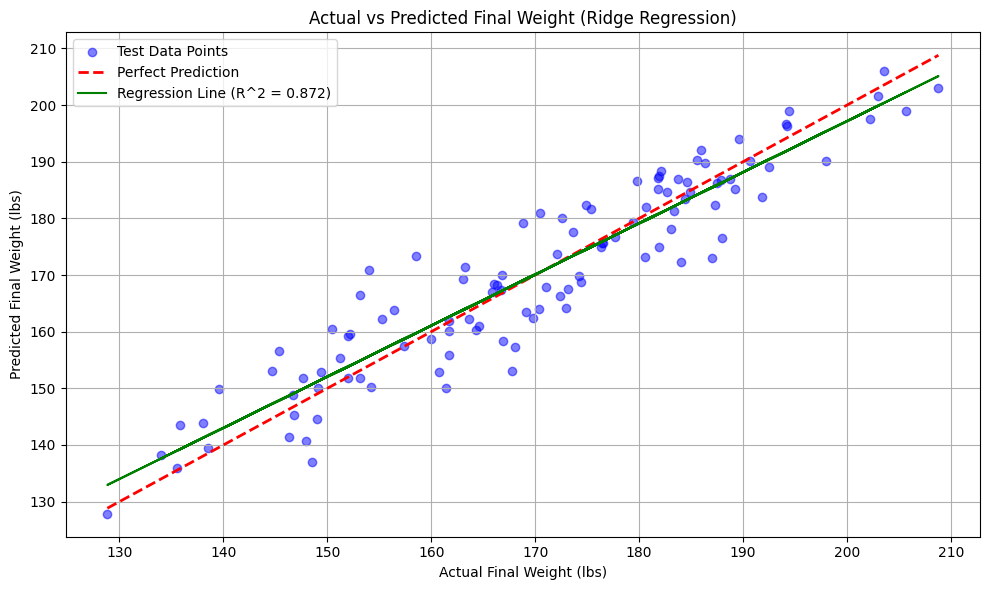

In [377]:
X = dataset_augmented.drop(columns=['Final Weight (lbs)'])
y = dataset_augmented['Final Weight (lbs)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alphas = np.logspace(-3, 3, 100)

#use ridgecv to find the best alpha using cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=5) 
ridge_cv.fit(X_train, y_train)

#get the best alpha
best_alpha = ridge_cv.alpha_
print(f"Best alpha for Ridge Regression: {best_alpha:.4f}")

#train a ridge model with the best alpha
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train, y_train)

#make predictions on the sets
y_train_pred = best_ridge.predict(X_train)
y_test_pred = best_ridge.predict(X_test)

#calculate rmse and r^2 for training and test sets
train_rmse = mean_squared_error(y_train, y_train_pred)
test_rmse_rig = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2_rig  = r2_score(y_test, y_test_pred)

#print model performance metrics
print("\nRidge Regression Model Performance:")
print("-" * 50)
print(f"Best Alpha: {best_alpha}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Testing RMSE: {test_rmse_rig:.2f}")
print(f"Training R^2 Score: {train_r2:.10f}")
print(f"Testing R^2 Score: {test_r2_rig:.10f}")

#1. plot actual vs predicted for the test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue', label='Test Data Points')

#add the perfect prediction line (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')

#add the regression line
z_with_bmr = np.polyfit(y_test, y_test_pred, 1)
p_with_bmr = np.poly1d(z_with_bmr)
plt.plot(y_test, p(y_test), 'g-', label=f'Regression Line (R^2 = {test_r2_rig:.3f})')

plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs)')
plt.title('Actual vs Predicted Final Weight (Ridge Regression)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#2. plotting rmse for different alphas (using `cv_results_`)
if hasattr(ridge_cv, 'cv_results_'):
    mean_cv_errors = ridge_cv.cv_results_['mean_test_score']
    mean_cv_errors = -mean_cv_errors  #ridgecv by default returns negative score, so negate it

    plt.figure(figsize=(10, 6))
    plt.plot(alphas, mean_cv_errors, marker='o', linestyle='--', color='green')
    plt.xscale('log')
    plt.xlabel('Alpha (Log Scale)')
    plt.ylabel('Average Cross-Validation RMSE')
    plt.title('Cross-Validation Performance for Different Alpha Values (Ridge Regression)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Best alpha for Ridge Regression (No BMR): 0.0163

Ridge Regression Model Performance (No BMR):
--------------------------------------------------
Best Alpha (No BMR): 0.016297508346206444
Training RMSE (No BMR): 46.93
Testing RMSE (No BMR): 40.37
Training R^2 Score (No BMR): 0.8539469691
Testing R^2 Score (No BMR): 0.8714082070


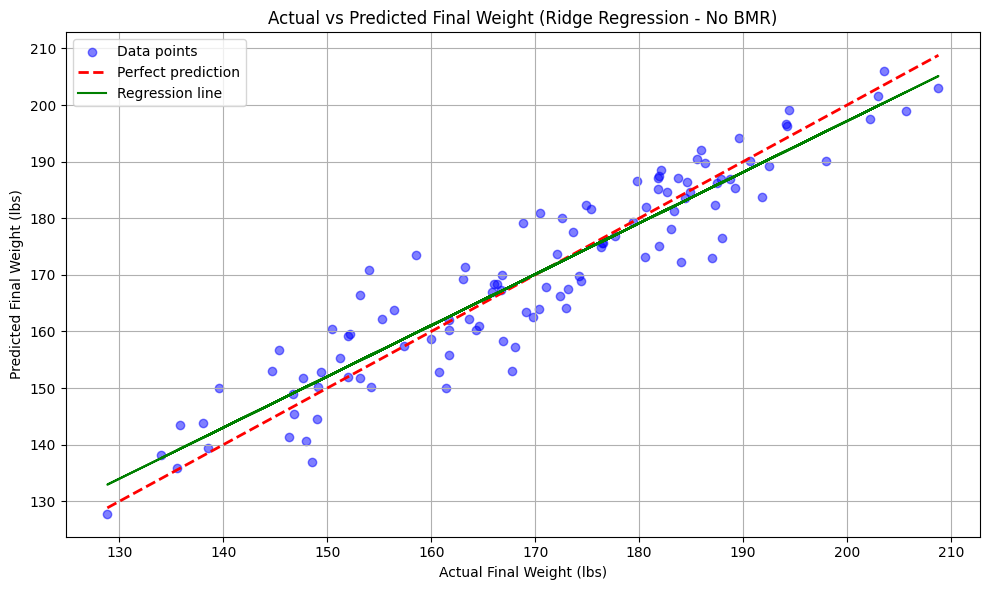

In [378]:
dataset_without_bmr = dataset_augmented.drop(columns=['BMR (Calories)'])

X_no_bmr = dataset_without_bmr.drop(columns=['Final Weight (lbs)'])
y_no_bmr = dataset_without_bmr['Final Weight (lbs)']

X_train_no_bmr, X_test_no_bmr, y_train_no_bmr, y_test_no_bmr = train_test_split(X_no_bmr, y_no_bmr, test_size=0.2, random_state=42)

alphas = np.logspace(-3, 3, 100) 

#use ridgecv to find the best alpha using cross-validation
ridge_cv_no_bmr = RidgeCV(alphas=alphas, cv=5)  
ridge_cv_no_bmr.fit(X_train_no_bmr, y_train_no_bmr)

#get the best alpha
best_alpha_no_bmr = ridge_cv_no_bmr.alpha_
print(f"Best alpha for Ridge Regression (No BMR): {best_alpha_no_bmr:.4f}")

#train a ridge model with the best alpha
best_ridge_no_bmr = Ridge(alpha=best_alpha_no_bmr)
best_ridge_no_bmr.fit(X_train_no_bmr, y_train_no_bmr)

#make predictions on the training and test sets
y_train_pred_no_bmr = best_ridge_no_bmr.predict(X_train_no_bmr)
y_test_pred_no_bmr = best_ridge_no_bmr.predict(X_test_no_bmr)

#calculate rmse and r^2 for training and test sets
train_rmse_no_bmr = mean_squared_error(y_train_no_bmr, y_train_pred_no_bmr)
test_rmse_rig_wo = mean_squared_error(y_test_no_bmr, y_test_pred_no_bmr)
train_r2_no_bmr = r2_score(y_train_no_bmr, y_train_pred_no_bmr)
test_r2_rig_wo = r2_score(y_test_no_bmr, y_test_pred_no_bmr)

#print model performance metrics
print("\nRidge Regression Model Performance (No BMR):")
print("-" * 50)
print(f"Best Alpha (No BMR): {best_alpha_no_bmr}")
print(f"Training RMSE (No BMR): {train_rmse_no_bmr:.2f}")
print(f"Testing RMSE (No BMR): {test_rmse_rig_wo:.2f}")
print(f"Training R^2 Score (No BMR): {train_r2_no_bmr:.10f}")
print(f"Testing R^2 Score (No BMR): {test_r2_rig_wo:.10f}")

#1. plot actual vs predicted for the test set without bmr
plt.figure(figsize=(10, 6))
plt.scatter(y_test_no_bmr, y_test_pred_no_bmr, alpha=0.5, color='blue', label='Data points')

#add perfect prediction line (y=x)
plt.plot([y_test_no_bmr.min(), y_test_no_bmr.max()], [y_test_no_bmr.min(), y_test_no_bmr.max()], 'r--', lw=2, label='Perfect prediction')

#add regression line
z_no_bmr = np.polyfit(y_test_no_bmr, y_test_pred_no_bmr, 1)
p_no_brm = np.poly1d(z)
plt.plot(y_test_no_bmr, p(y_test_no_bmr), "g-", label='Regression line')

plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs)')
plt.title('Actual vs Predicted Final Weight (Ridge Regression - No BMR)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#2. plotting rmse for different alphas (using `cv_results_`)
if hasattr(ridge_cv_no_bmr, 'cv_results_'):
    mean_cv_errors_no_bmr = ridge_cv_no_bmr.cv_results_['mean_test_score']
    mean_cv_errors_no_bmr = -mean_cv_errors_no_bmr  #ridgecv by default returns negative score, so negate it

    plt.figure(figsize=(10, 6))
    plt.plot(alphas, mean_cv_errors_no_bmr, marker='o', linestyle='--', color='green')
    plt.xscale('log')
    plt.xlabel('Alpha (Log Scale)')
    plt.ylabel('Average Cross-Validation RMSE')
    plt.title('Cross-Validation Performance for Different Alpha Values (Ridge Regression - No BMR)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


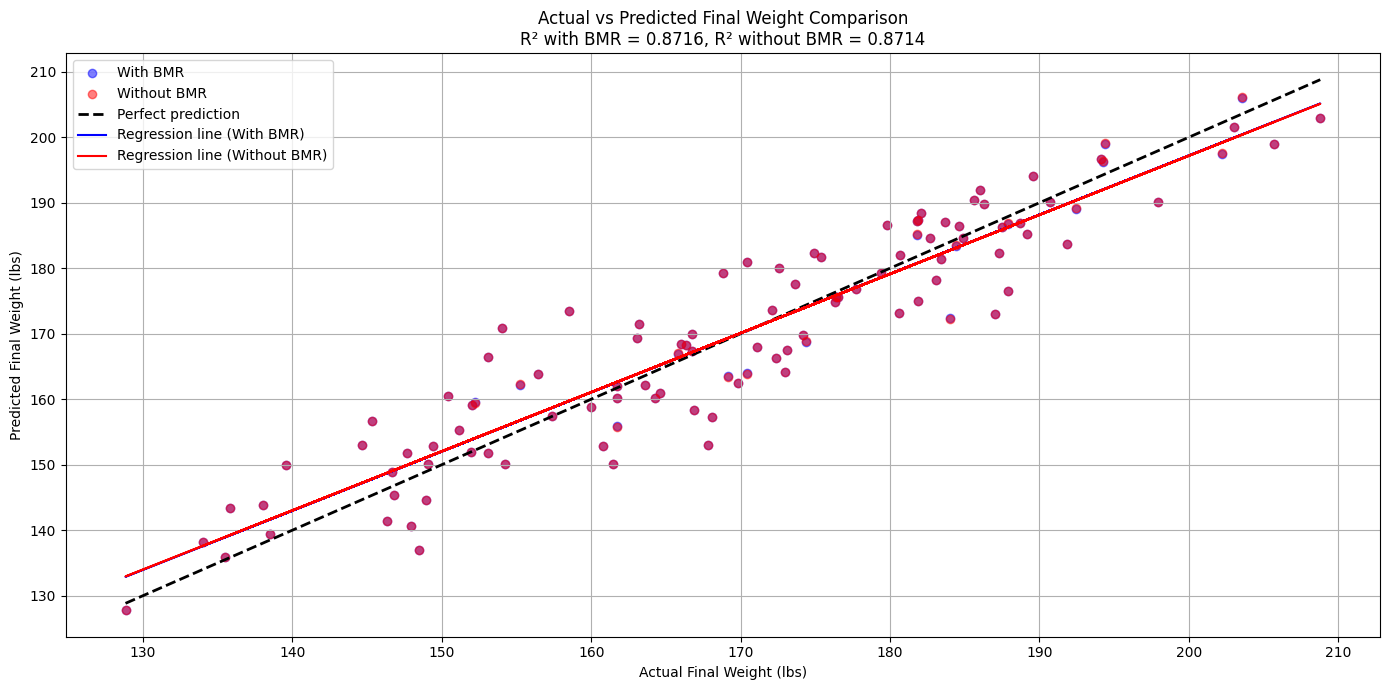


Performance Difference (With BMR - Without BMR):
--------------------------------------------------
R² Score difference: 0.0001618839
RMSE difference: -0.0508214153


In [379]:
# Comparison of Ridge Regression Models with and without BMR

plt.figure(figsize=(14, 7))

# Plot both models on the same plot
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue', label='With BMR')
plt.scatter(y_test_no_bmr, y_test_pred_no_bmr, alpha=0.5, color='red', label='Without BMR')

# Add perfect prediction line (y=x)
all_min = min(y_test.min(), y_test_no_bmr.min())
all_max = max(y_test.max(), y_test_no_bmr.max())
plt.plot([all_min, all_max], [all_min, all_max], 'k--', lw=2, label='Perfect prediction')

# Add regression lines
#z_with_bmr = np.polyfit(y_test, y_pred, 1)
#p_with_bmr = np.poly1d(z_with_bmr)
plt.plot(y_test, p_with_bmr(y_test), "b-", label='Regression line (With BMR)')

#z_without_bmr = np.polyfit(y_test_no_bmr, y_test_pred_no_bmr, 1)
#p_without_bmr = np.poly1d(z_without_bmr)
plt.plot(y_test_no_bmr, p_no_brm(y_test_no_bmr), "r-", label='Regression line (Without BMR)')

plt.xlabel('Actual Final Weight (lbs)')
plt.ylabel('Predicted Final Weight (lbs)')
plt.title('Actual vs Predicted Final Weight Comparison\n' + 
          f'R² with BMR = {test_r2_rig:.4f}, R² without BMR = {test_r2_rig_wo:.4f}')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print performance difference
print("\nPerformance Difference (With BMR - Without BMR):")
print("-" * 50)
print(f"R² Score difference: {test_r2_rig - test_r2_rig_wo:.10f}")
print(f"RMSE difference: {test_rmse_rig - test_rmse_rig_wo:.10f}")


Ridge Regression Analysis:
- The best alpha found were vary differente, the first is around 0.08 and the other 0.02.
- Including BMR as a feature improves model performance, it has an higher R² score, but has in the other cases, the difference is little between the one with Calories and the one without.
- Both models show reasonable predictive power, but BMR version has noticeably better accuracy
- The regression lines indicate the model with BMR (blue) follows the ideal prediction more closely
- The scatter plots reveal that predictions without BMR (red) have more variance/spread


# **Task 4. Now, let’s stratify the problem according to gender. Using the dataset_reduced, build two different supervised systems (one considering only the male subjects and one considering only the female subjects) based on Linear Regression which are capable of predicting the Final Weight (lbs) under the two conditions specified in the preamble. Optimize, per each system, the number of iterations of the learning procedure and the learning rate η. Plot the related learning curves and compare them.**


Training with learning rate: 0.001, iterations: 100
Male model final cost: 8756.725934
Female model final cost: 8547.005426

Training with learning rate: 0.001, iterations: 600
Male model final cost: 759.937498
Female model final cost: 800.241375

Training with learning rate: 0.01, iterations: 100
Male model final cost: 244.617401
Female model final cost: 267.348288

Training with learning rate: 0.01, iterations: 600
Male model final cost: 133.933083
Female model final cost: 126.774969

Training with learning rate: 0.1, iterations: 100
Male model final cost: 109.072426
Female model final cost: 95.572828

Training with learning rate: 0.1, iterations: 600
Male model final cost: 29.008436
Female model final cost: 21.435250


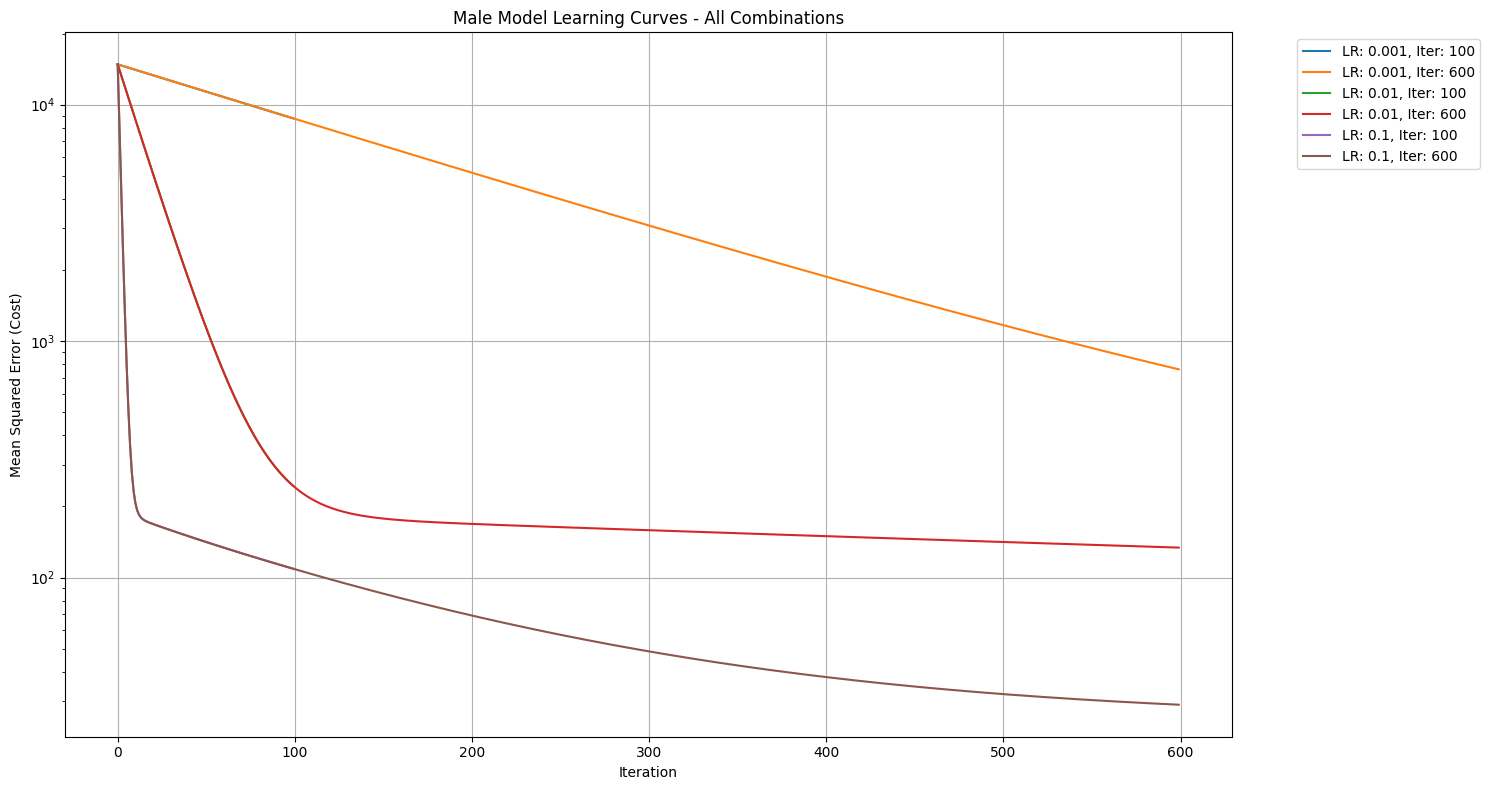

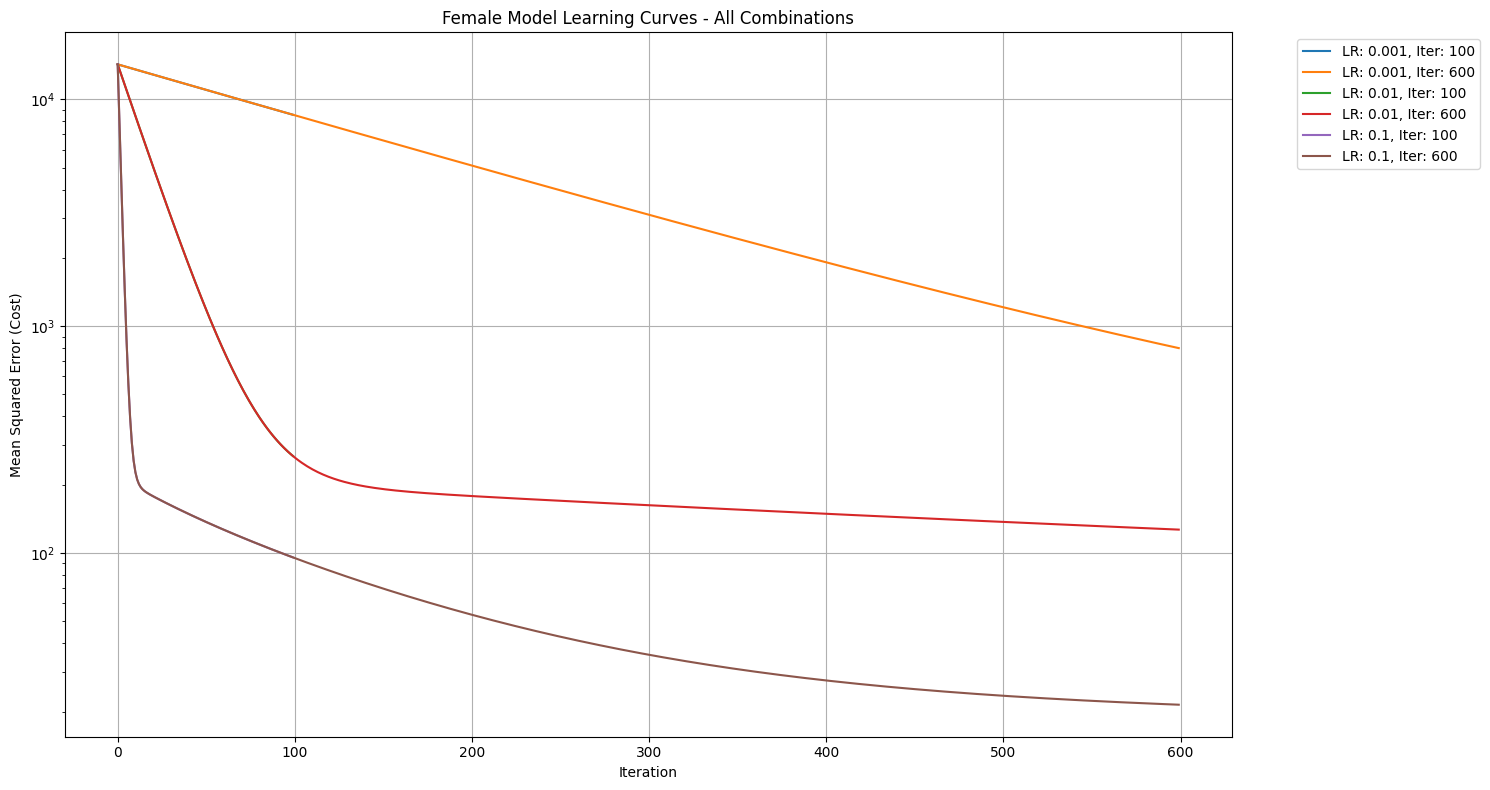


Best Parameters Found:

Male Model:
Learning Rate: 0.1
Number of Iterations: 600
Final Cost: 29.008436

Female Model:
Learning Rate: 0.1
Number of Iterations: 600
Final Cost: 21.435250


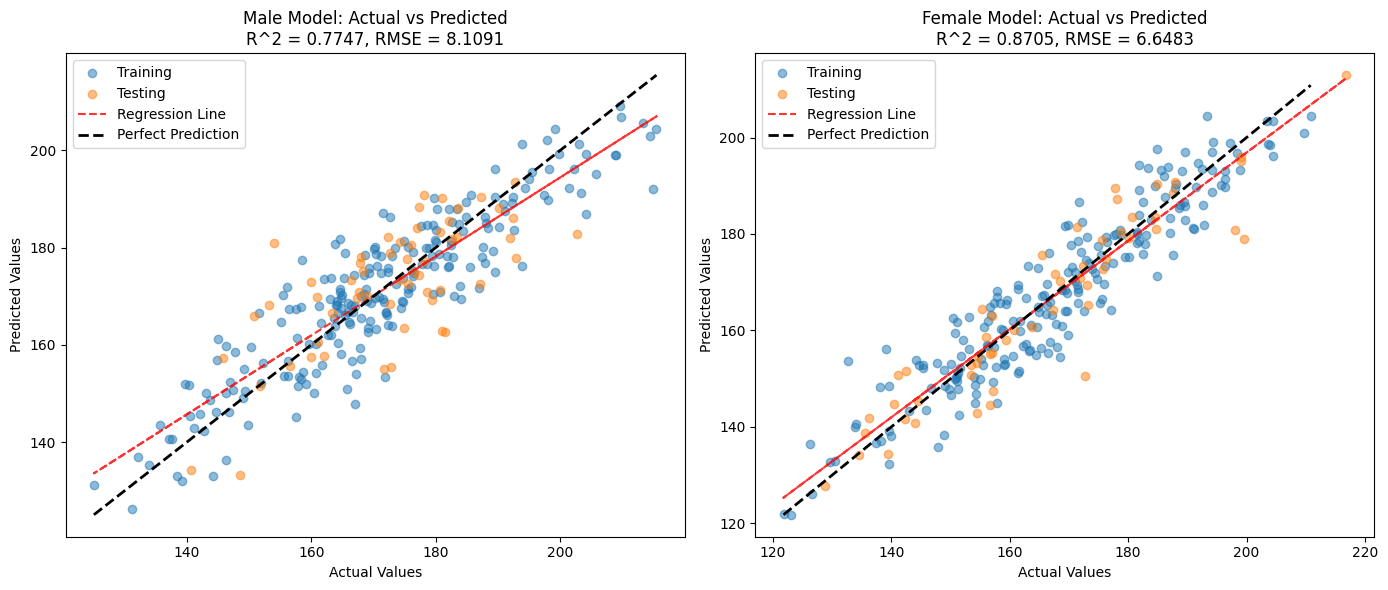

In [380]:
#separate the dataset into male and female 
dataset_male = dataset_reduced[dataset_reduced['Gender'] == 1]
dataset_female = dataset_reduced[dataset_reduced['Gender'] == 0]

print(f"Number of Male samples: {len(dataset_male)}")
print(f"Number of Female samples: {len(dataset_female)}")

#split dataset for features (x) and target (y) for both genders
X_male = dataset_male.drop(columns=['Final Weight (lbs)', 'Gender'])
y_male = dataset_male['Final Weight (lbs)']

X_female = dataset_female.drop(columns=['Final Weight (lbs)', 'Gender'])
y_female = dataset_female['Final Weight (lbs)']

#split into training and testing sets
test_size_ratio = 0.1 if min(len(dataset_male), len(dataset_female)) < 10 else 0.2
X_train_male, X_test_male, y_train_male, y_test_male = train_test_split(X_male, y_male, test_size=test_size_ratio, random_state=42)
X_train_female, X_test_female, y_train_female, y_test_female = train_test_split(X_female, y_female, test_size=test_size_ratio, random_state=42)

#reduced learning rates to prevent overflow
learning_rates = [0.001, 0.01, 0.1]
n_iterations_list = [100, 600]

#initialize dictionaries to store all results
male_results = {}
female_results = {}

#training for male and female models
for lr in learning_rates:
    for n_iter in n_iterations_list:
        print(f"\nTraining with learning rate: {lr}, iterations: {n_iter}")
        
        #male model
        best_weights_male, bias, cost_history = batch_gradient_descent(X_train_male.values, y_train_male.values, lr, n_iter)
        final_cost_male = cost_history[-1]
        male_results[(lr, n_iter)] = {
            'weights': best_weights_male,
            'bias': bias,
            'cost_history': cost_history,
            'final_cost': final_cost_male
        }
        print(f"Male model final cost: {final_cost_male:.6f}")
        best_bias_male = bias
        
        #female model
        best_weights_female, bias, cost_history = batch_gradient_descent(X_train_female.values, y_train_female.values, lr, n_iter)
        final_cost_female = cost_history[-1]
        female_results[(lr, n_iter)] = {
            'weights': best_weights_female,
            'bias': bias,
            'cost_history': cost_history,
            'final_cost': final_cost_female
        }
        print(f"Female model final cost: {final_cost_female:.6f}")
        best_bias_female = bias
        best_weights_female = weights

#find and print best parameters
best_male_params = min(male_results.items(), key=lambda x: x[1]['final_cost'])
best_female_params = min(female_results.items(), key=lambda x: x[1]['final_cost'])

#create two separate figures for male and female learning curves
#male
plt.figure(figsize=(15, 8))
for lr in learning_rates:
    for n_iter in n_iterations_list:
        cost_history = male_results[(lr, n_iter)]['cost_history']
        plt.plot(cost_history, label=f'LR: {lr}, Iter: {n_iter}')

plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (Cost)')
plt.title('Male Model Learning Curves - All Combinations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

#female
plt.figure(figsize=(15, 8))
for lr in learning_rates:
    for n_iter in n_iterations_list:
        cost_history = female_results[(lr, n_iter)]['cost_history']
        plt.plot(cost_history, label=f'LR: {lr}, Iter: {n_iter}')

plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (Cost)')
plt.title('Female Model Learning Curves - All Combinations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

#plot metrics
print("\n" + "="*50)
print("Best Parameters Found:")
print(f"\nMale Model:")
print(f"Learning Rate: {best_male_params[0][0]}")
print(f"Number of Iterations: {best_male_params[0][1]}")
print(f"Final Cost: {best_male_params[1]['final_cost']:.6f}")

print(f"\nFemale Model:")
print(f"Learning Rate: {best_female_params[0][0]}")
print(f"Number of Iterations: {best_female_params[0][1]}")
print(f"Final Cost: {best_female_params[1]['final_cost']:.6f}")
print("="*50)

def predict(X, weights, bias):
    return np.dot(X, weights) + bias

#make predictions
male_train_pred = predict(X_train_male.values, best_male_params[1]['weights'], best_male_params[1]['bias'])
male_test_pred = predict(X_test_male.values, best_male_params[1]['weights'], best_male_params[1]['bias'])
female_train_pred = predict(X_train_female.values, best_female_params[1]['weights'], best_female_params[1]['bias'])
female_test_pred = predict(X_test_female.values, best_female_params[1]['weights'], best_female_params[1]['bias'])

#plot regression results
plt.figure(figsize=(14, 6))

#male model regression plot
plt.subplot(1, 2, 1)
plt.scatter(y_train_male, male_train_pred, alpha=0.5, label='Training')
plt.scatter(y_test_male, male_test_pred, alpha=0.5, label='Testing')

#add regression line for male model and calculate metrics
male_all_y = np.concatenate([y_train_male, y_test_male])
male_all_pred = np.concatenate([male_train_pred, male_test_pred])
male_z = np.polyfit(male_all_y, male_all_pred, 1)
male_p = np.poly1d(male_z)
plt.plot(male_all_y, male_p(male_all_y), "r--", alpha=0.8, label='Regression Line')

#calculate r^2 and rmse for male model
male_r2_wi_BMR = r2_score(male_all_y, male_all_pred)
male_rmse_wi_BMR = np.sqrt(mean_squared_error(male_all_y, male_all_pred))

plt.plot([y_train_male.min(), y_train_male.max()], 
            [y_train_male.min(), y_train_male.max()], 
            'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Male Model: Actual vs Predicted\nR^2 = {male_r2_wi_BMR:.4f}, RMSE = {male_rmse_wi_BMR:.4f}')
plt.legend()

#female model regression plot
plt.subplot(1, 2, 2)
plt.scatter(y_train_female, female_train_pred, alpha=0.5, label='Training')
plt.scatter(y_test_female, female_test_pred, alpha=0.5, label='Testing')

#add regression line for female model and calculate metrics
female_all_y = np.concatenate([y_train_female, y_test_female])
female_all_pred = np.concatenate([female_train_pred, female_test_pred])
female_z = np.polyfit(female_all_y, female_all_pred, 1)
female_p = np.poly1d(female_z)
plt.plot(female_all_y, female_p(female_all_y), "r--", alpha=0.8, label='Regression Line')

#calculate r^2 and rmse for female model
female_r2_wi_BMR = r2_score(female_all_y, female_all_pred)
female_rmse_wi_BMR = np.sqrt(mean_squared_error(female_all_y, female_all_pred))

plt.plot([y_train_female.min(), y_train_female.max()], 
            [y_train_female.min(), y_train_female.max()], 
            'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Female Model: Actual vs Predicted\nR^2 = {female_r2_wi_BMR:.4f}, RMSE = {female_rmse_wi_BMR:.4f}')
plt.legend()

plt.tight_layout()
plt.show()


In [381]:
#differences in metrics between models 
print(f"Difference in R^2 (Male - Female): {male_r2_wi_BMR - female_r2_wi_BMR:.4f}")
print(f"Difference in RMSE (Male - Female): {male_rmse_wi_BMR - female_rmse_wi_BMR:.4f}")



Difference in R^2 (Male - Female): -0.0957
Difference in RMSE (Male - Female): 1.4608


2 differents model for male and female with BGD (with Calories)
- Both for male and female the best learning rate is 0.1 and the number of itertions is 600.
- The costs are different from one to the other, the cost for Male is 29, and for female 21.4.
- The best one in terms of RMSE and R^2 is the female, that is close to have 0.1 more then the one with male

Number of Male samples: 282
Number of Female samples: 266

Training with learning rate: 0.001, iterations: 100
Male model final cost: 12167.226282
Female model final cost: 11714.002855

Training with learning rate: 0.001, iterations: 600
Male model final cost: 4535.587180
Female model final cost: 4356.296572

Training with learning rate: 0.01, iterations: 100
Male model final cost: 2104.257426
Female model final cost: 2012.443239

Training with learning rate: 0.01, iterations: 600
Male model final cost: 35.631900
Female model final cost: 23.916976

Training with learning rate: 0.1, iterations: 100
Male model final cost: 26.934902
Female model final cost: 18.365659

Training with learning rate: 0.1, iterations: 600
Male model final cost: 24.569239
Female model final cost: 17.313502


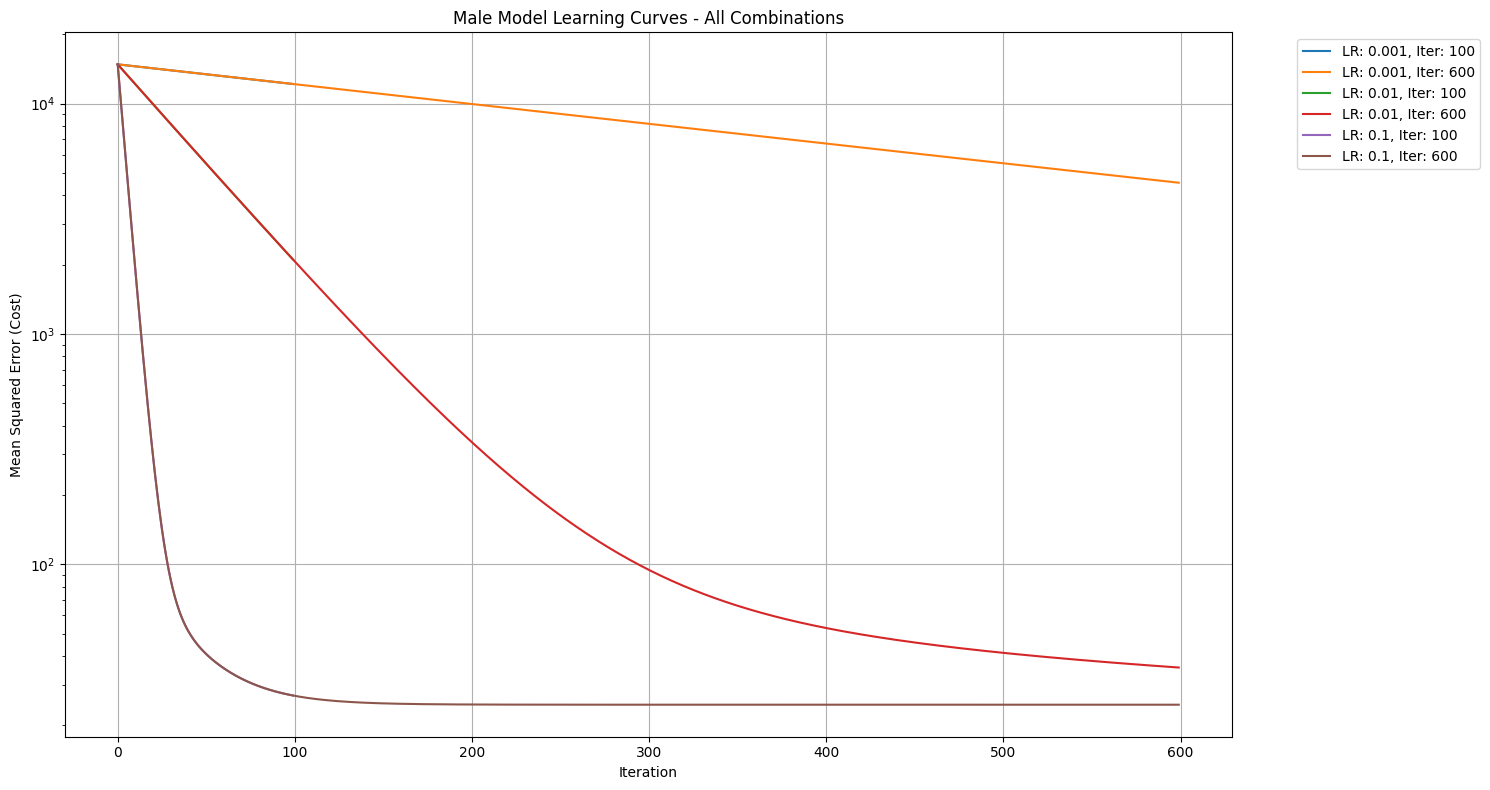

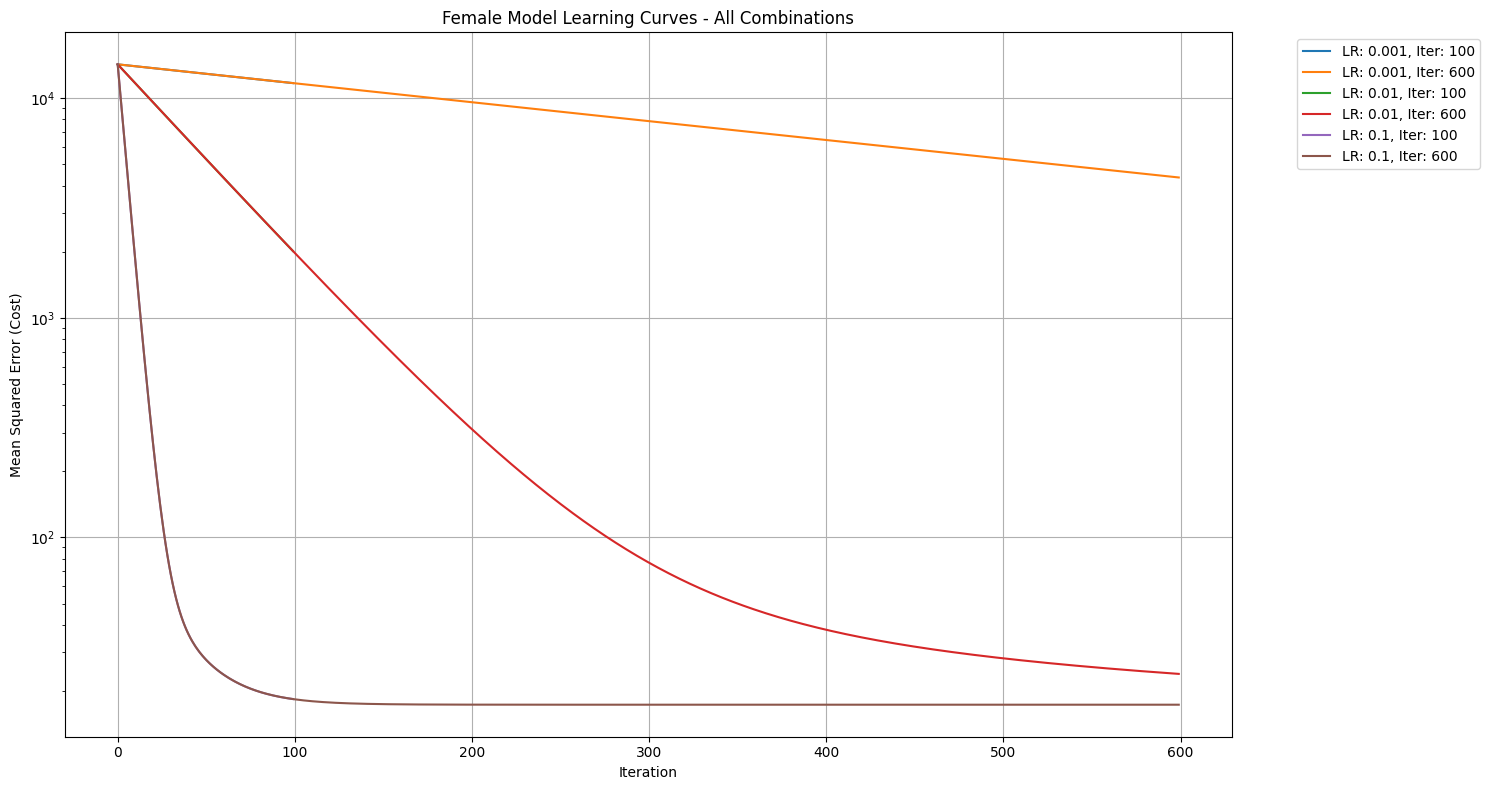


Best Parameters Found:

Male Model:
Learning Rate: 0.1
Number of Iterations: 600
Final Cost: 24.569239

Female Model:
Learning Rate: 0.1
Number of Iterations: 600
Final Cost: 17.313502


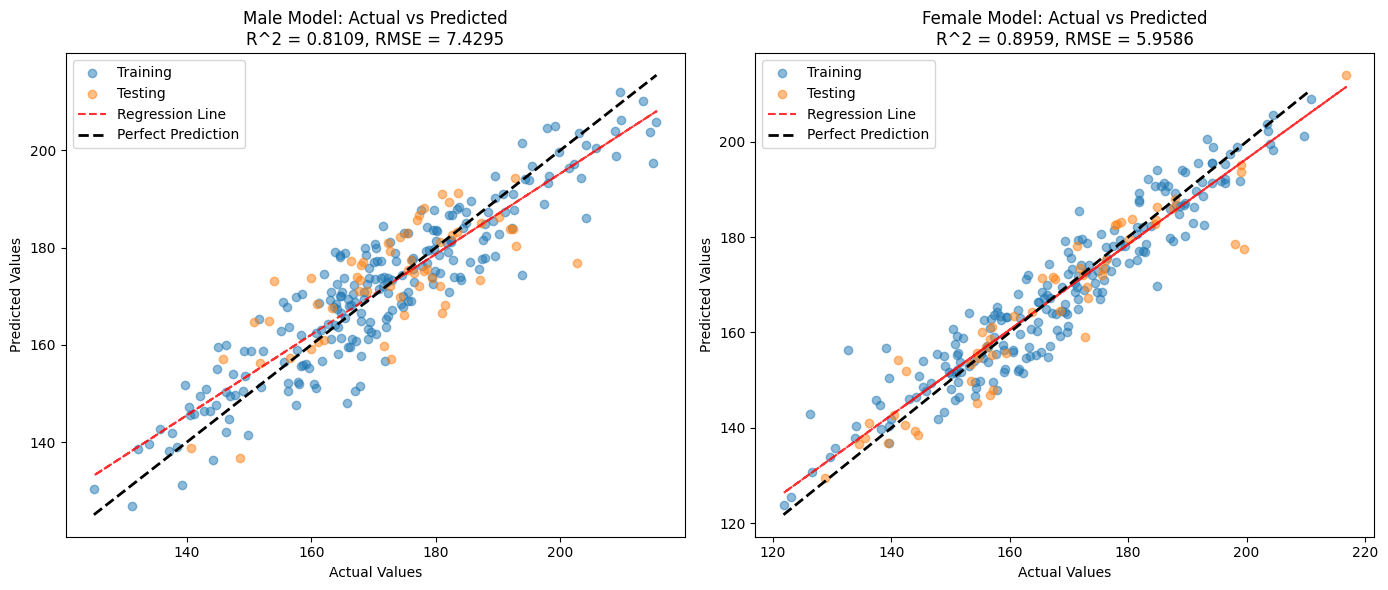

In [382]:
#separate the dataset into male and female subsets
dataset_male = dataset_reduced[dataset_reduced['Gender'] == 1]
dataset_female = dataset_reduced[dataset_reduced['Gender'] == 0]

print(f"Number of Male samples: {len(dataset_male)}")
print(f"Number of Female samples: {len(dataset_female)}")

X_male = dataset_male.drop(columns=['Final Weight (lbs)', 'Gender', 'BMR (Calories)'])
y_male = dataset_male['Final Weight (lbs)']

X_female = dataset_female.drop(columns=['Final Weight (lbs)', 'Gender', 'BMR (Calories)'])
y_female = dataset_female['Final Weight (lbs)']

test_size_ratio = 0.1 if min(len(dataset_male), len(dataset_female)) < 10 else 0.2
X_train_male, X_test_male, y_train_male, y_test_male = train_test_split(X_male, y_male, test_size=test_size_ratio, random_state=42)
X_train_female, X_test_female, y_train_female, y_test_female = train_test_split(X_female, y_female, test_size=test_size_ratio, random_state=42)


learning_rates = [0.001, 0.01, 0.1]
n_iterations_list = [100, 600]

#dictionaries to store all results
male_results = {}
female_results = {}

#training 
for lr in learning_rates:
    for n_iter in n_iterations_list:
        print(f"\nTraining with learning rate: {lr}, iterations: {n_iter}")
        
        #male model
        weights, bias, cost_history = batch_gradient_descent(X_train_male.values, y_train_male.values, lr, n_iter)
        final_cost_male = cost_history[-1]
        male_results[(lr, n_iter)] = {
            'weights': weights,
            'bias': bias,
            'cost_history': cost_history,
            'final_cost': final_cost_male
        }
        print(f"Male model final cost: {final_cost_male:.6f}")
        
        #female model
        weights, bias, cost_history = batch_gradient_descent(X_train_female.values, y_train_female.values, lr, n_iter)
        final_cost_female = cost_history[-1]
        female_results[(lr, n_iter)] = {
            'weights': weights,
            'bias': bias,
            'cost_history': cost_history,
            'final_cost': final_cost_female
        }
        print(f"Female model final cost: {final_cost_female:.6f}")

#find and print best parameters
best_male_params = min(male_results.items(), key=lambda x: x[1]['final_cost'])
best_female_params = min(female_results.items(), key=lambda x: x[1]['final_cost'])

#male model 
plt.figure(figsize=(15, 8))
for lr in learning_rates:
    for n_iter in n_iterations_list:
        cost_history = male_results[(lr, n_iter)]['cost_history']
        plt.plot(cost_history, label=f'LR: {lr}, Iter: {n_iter}')

plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (Cost)')
plt.title('Male Model Learning Curves - All Combinations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

#female model 
plt.figure(figsize=(15, 8))
for lr in learning_rates:
    for n_iter in n_iterations_list:
        cost_history = female_results[(lr, n_iter)]['cost_history']
        plt.plot(cost_history, label=f'LR: {lr}, Iter: {n_iter}')

plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (Cost)')
plt.title('Female Model Learning Curves - All Combinations')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Best Parameters Found:")
print(f"\nMale Model:")
print(f"Learning Rate: {best_male_params[0][0]}")
print(f"Number of Iterations: {best_male_params[0][1]}")
print(f"Final Cost: {best_male_params[1]['final_cost']:.6f}")

print(f"\nFemale Model:")
print(f"Learning Rate: {best_female_params[0][0]}")
print(f"Number of Iterations: {best_female_params[0][1]}")
print(f"Final Cost: {best_female_params[1]['final_cost']:.6f}")
print("="*50)

#make predictions using best models
def predict(X, weights, bias):
    return np.dot(X, weights) + bias

#make predictions
male_train_pred = predict(X_train_male.values, best_male_params[1]['weights'], best_male_params[1]['bias'])
male_test_pred = predict(X_test_male.values, best_male_params[1]['weights'], best_male_params[1]['bias'])
female_train_pred = predict(X_train_female.values, best_female_params[1]['weights'], best_female_params[1]['bias'])
female_test_pred = predict(X_test_female.values, best_female_params[1]['weights'], best_female_params[1]['bias'])

#plot regression results
plt.figure(figsize=(14, 6))

#male model regression plot
plt.subplot(1, 2, 1)
plt.scatter(y_train_male, male_train_pred, alpha=0.5, label='Training')
plt.scatter(y_test_male, male_test_pred, alpha=0.5, label='Testing')

#add regression line for male model and calculate metrics
male_all_y = np.concatenate([y_train_male, y_test_male])
male_all_pred = np.concatenate([male_train_pred, male_test_pred])
male_z = np.polyfit(male_all_y, male_all_pred, 1)
male_p = np.poly1d(male_z)
plt.plot(male_all_y, male_p(male_all_y), "r--", alpha=0.8, label='Regression Line')

#calculate r^2 and rmse for male model
male_r2_wo_BMR = r2_score(male_all_y, male_all_pred)
male_rmse_wo_BMR = np.sqrt(mean_squared_error(male_all_y, male_all_pred))

plt.plot([y_train_male.min(), y_train_male.max()], 
            [y_train_male.min(), y_train_male.max()], 
            'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Male Model: Actual vs Predicted\nR^2 = {male_r2_wo_BMR:.4f}, RMSE = {male_rmse_wo_BMR:.4f}')
plt.legend()

#female mode
plt.subplot(1, 2, 2)
plt.scatter(y_train_female, female_train_pred, alpha=0.5, label='Training')
plt.scatter(y_test_female, female_test_pred, alpha=0.5, label='Testing')

#add regression line for female model and calculate metrics
female_all_y = np.concatenate([y_train_female, y_test_female])
female_all_pred = np.concatenate([female_train_pred, female_test_pred])
female_z = np.polyfit(female_all_y, female_all_pred, 1)
female_p = np.poly1d(female_z)
plt.plot(female_all_y, female_p(female_all_y), "r--", alpha=0.8, label='Regression Line')

#calculate r^2 and rmse for female model
female_r2_wo_BMR = r2_score(female_all_y, female_all_pred)
female_rmse_wo_BMR = np.sqrt(mean_squared_error(female_all_y, female_all_pred))

plt.plot([y_train_female.min(), y_train_female.max()], 
            [y_train_female.min(), y_train_female.max()], 
            'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Female Model: Actual vs Predicted\nR^2 = {female_r2_wo_BMR:.4f}, RMSE = {female_rmse_wo_BMR:.4f}')
plt.legend()

plt.tight_layout()
plt.show()


In [388]:
# Comparing R^2 values with and without BMR

# Calculate differences in R^2 for each model with vs without BMR
print("R^2 Differences (with BMR - without BMR):")
print(f"Female Model: {female_r2_wi_BMR - female_r2_wo_BMR:.4f}")
print(f"Male Model: {male_r2_wi_BMR - male_r2_wo_BMR:.4f}")

# Calculate difference between male and female R^2 scores
print("\nR^2 Differences between Male and Female models:")
print(f"With BMR: {male_r2_wi_BMR - female_r2_wi_BMR:.4f}")
print(f"Without BMR: {male_r2_wo_BMR - female_r2_wo_BMR:.4f}")


R^2 Differences (with BMR - without BMR):
Female Model: -0.0255
Male Model: -0.0362

R^2 Differences between Male and Female models:
With BMR: -0.0957
Without BMR: -0.0850


BGD with two different model per gender
- Also without the calories, the female model is better and more accurate, but he gap is less now, of 0.01
- Also in this case, the prediction without calories is worst then di one with them, for both model.
- The best parameter remains learning_rate = 0.1 and 600 iteration (for both).

# **TASK5. On this task you are going to reason on the approaches based on the dataset_reduced. Do the gender-stratified approach (task 4) lead to better performances with respect to the global approach (task 3)? For this task, measure how well each different approach developed above on dataset_reduced is capable of predicting the Final Weight (lbs) (under the conditions specified in the preamble) over the two genders present in the dataset. The performances to compare are the ones calculated only on test samples related to each specific gender. Visualize the obtained results.**

With Calories

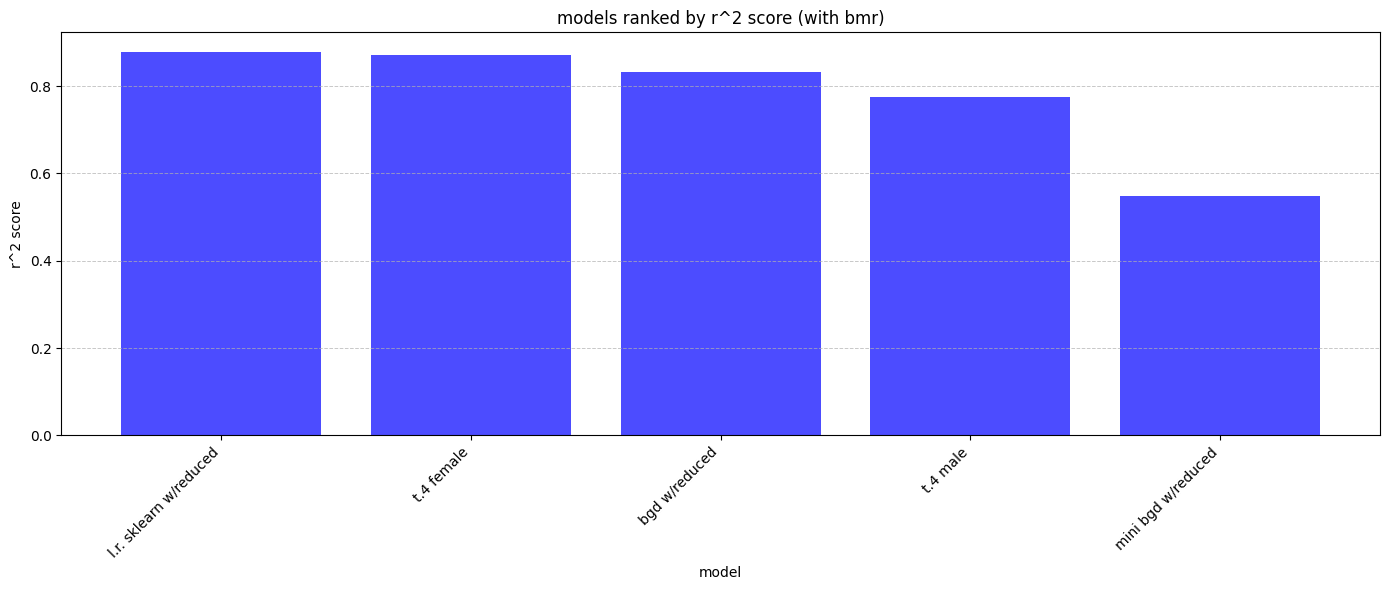


model rankings by r^2 score:
1. l.r. sklearn w/reduced: 0.8791
2. t.4 female: 0.8705
3. bgd w/reduced: 0.8311
4. t.4 male: 0.7747
5. mini bgd w/reduced: 0.5483


In [393]:
#creating a list of labels and corresponding r^2 values
labels = [
    'l.r. sklearn w/reduced',
    'bgd w/reduced', 
    'mini bgd w/reduced',
    't.4 female',
    't.4 male'
]

r2_values = [
    r2_with_calories,
    test_r2_bga,
    best_r2_mb, 
    female_r2_wi_BMR,
    male_r2_wi_BMR
]

#create list of tuples with labels and values
model_scores = list(zip(labels, r2_values))

#sort by r2 score in descending order
model_scores.sort(key=lambda x: x[1], reverse=True)

#plot sorted values
plt.figure(figsize=(14, 6))
x = range(len(model_scores))

plt.bar(x, [score for _, score in model_scores], color='blue', alpha=0.7)
plt.xticks(x, [label for label, _ in model_scores], rotation=45, ha='right')
plt.xlabel('model')
plt.ylabel('r^2 score')
plt.title('models ranked by r^2 score (with bmr)')
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()

plt.show()

#print ranking
print("\nmodel rankings by r^2 score:")
for i, (model, score) in enumerate(model_scores, 1):
    print(f"{i}. {model}: {score:.4f}")


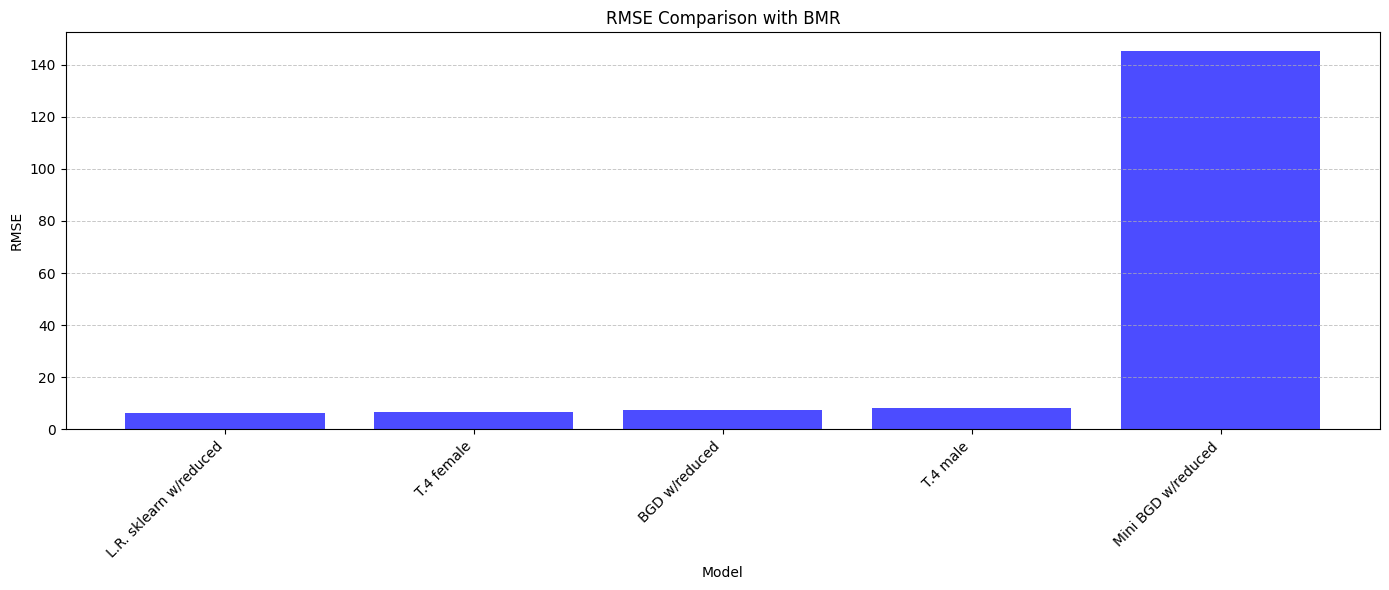


Model rankings by RMSE score:
1. L.R. sklearn w/reduced: 6.1604
2. T.4 female: 6.6483
3. BGD w/reduced: 7.2811
4. T.4 male: 8.1091
5. Mini BGD w/reduced: 145.1396

Best performing model: L.R. sklearn w/reduced
Best RMSE value: 6.1604


In [394]:
#creating a list of labels and corresponding rmse values
labels = [
    'L.R. sklearn w/reduced',
    'BGD w/reduced',
    'Mini BGD w/reduced',
    'T.4 female',
    'T.4 male'
]

rmse_values = [
    rmse_with_calories,
    test_rmse_bga,
    best_mse_mb,
    female_rmse_wi_BMR,
    male_rmse_wi_BMR
]

#create list of tuples with labels and values
model_scores = list(zip(labels, rmse_values))

#sort by rmse score in ascending order (lower is better)
model_scores.sort(key=lambda x: x[1])

#plotting the rmse values for different models
plt.figure(figsize=(14, 6))
x = range(len(model_scores))

plt.bar(x, [score for _, score in model_scores], color='blue', alpha=0.7)
plt.xticks(x, [label for label, _ in model_scores], rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison with BMR')
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()

#displaying the plot
plt.show()

#print ranking
print("\nModel rankings by RMSE score:")
for i, (model, score) in enumerate(model_scores, 1):
    print(f"{i}. {model}: {score:.4f}")

#find best rmse value and corresponding model
best_model, best_rmse = model_scores[0]
print(f"\nBest performing model: {best_model}")
print(f"Best RMSE value: {best_rmse:.4f}")


With Calories: for compare the performance this is a Bar Plot of the R^2 and RMSE of the requested models.
- the best one is the Linear regression with sklearn, that is really close to the model made only with women sample.
- the worst one is the mini batch.

Without Calories:

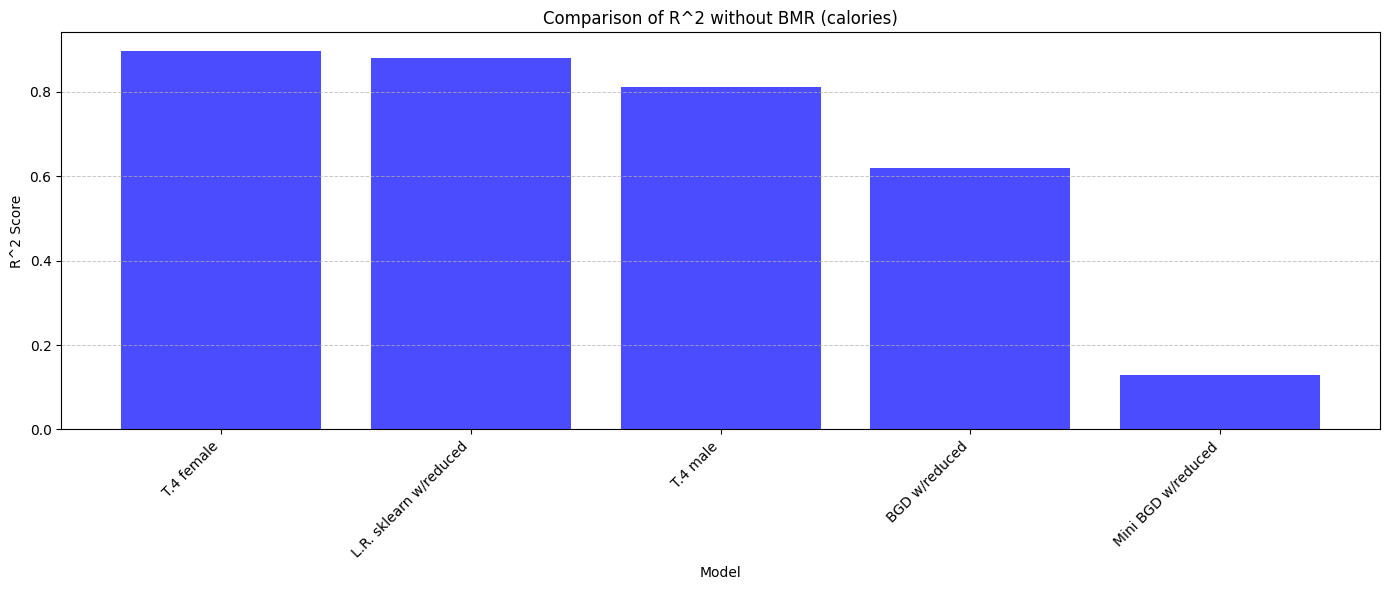


Model rankings by R^2 score:
1. T.4 female: 0.8959
2. L.R. sklearn w/reduced: 0.8789
3. T.4 male: 0.8109
4. BGD w/reduced: 0.6189
5. Mini BGD w/reduced: 0.1293

Best performing model: T.4 female
Best R^2 value: 0.8959


In [396]:
#creating a list of labels and corresponding r^2 values
labels = [
    'L.R. sklearn w/reduced',
    'BGD w/reduced', 
    'Mini BGD w/reduced',
    'T.4 female',
    'T.4 male'
]

r2_values = [
    r2_without_calories,
    test_r2_bga_wo,
    best_r2_mb_wo, 
    female_r2_wo_BMR,
    male_r2_wo_BMR
]

#create list of tuples with labels and values
model_scores = list(zip(labels, r2_values))

#sort by r2 score in descending order (higher is better)
model_scores.sort(key=lambda x: x[1], reverse=True)

#plotting the r^2 values for different models
plt.figure(figsize=(14, 6))
x = range(len(model_scores))

plt.bar(x, [score for _, score in model_scores], color='blue', alpha=0.7)
plt.xticks(x, [label for label, _ in model_scores], rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('R^2 Score')
plt.title('Comparison of R^2 without BMR (calories)')
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()

#displaying the plot
plt.show()

#print ranking
print("\nModel rankings by R^2 score:")
for i, (model, score) in enumerate(model_scores, 1):
    print(f"{i}. {model}: {score:.4f}")

#find best r^2 value and corresponding model
best_model, best_r2 = model_scores[0]
print(f"\nBest performing model: {best_model}")
print(f"Best R^2 value: {best_r2:.4f}")


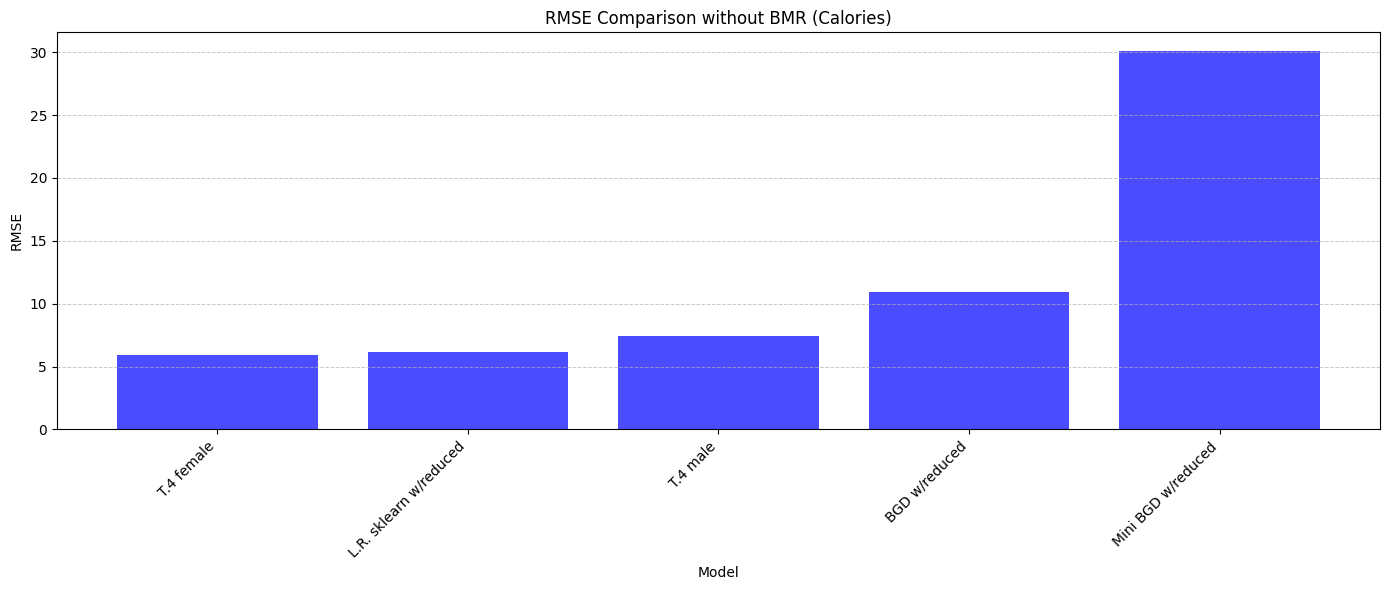


Best performing model: T.4 female
Best RMSE value: 5.9586

Model Rankings by RMSE (lower is better):
1. T.4 female: 5.9586
2. L.R. sklearn w/reduced: 6.1652
3. T.4 male: 7.4295
4. BGD w/reduced: 10.9386
5. Mini BGD w/reduced: 30.0756


In [395]:
#creating a list of labels and corresponding rmse values
labels = [
    'L.R. sklearn w/reduced',
    'BGD w/reduced',
    'Mini BGD w/reduced', 
    'T.4 female',
    'T.4 male'
]

rmse_values = [
    rmse_without_calories,
    test_rmse_bga_wo,
    best_rmse_mb_wo,
    female_rmse_wo_BMR,
    male_rmse_wo_BMR
]

#create list of tuples with labels and values
model_scores = list(zip(labels, rmse_values))

#sort by rmse score in ascending order (lower is better)
model_scores.sort(key=lambda x: x[1])

#plotting the rmse values for different models
plt.figure(figsize=(14, 6))
x = range(len(model_scores))

plt.bar(x, [score for _, score in model_scores], color='blue', alpha=0.7)
plt.xticks(x, [label for label, _ in model_scores], rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison without BMR (Calories)')
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()

#displaying the plot
plt.show()

#find best rmse value and corresponding model
best_rmse_idx = rmse_values.index(min(rmse_values))
print(f"\nBest performing model: {labels[best_rmse_idx]}")
print(f"Best RMSE value: {min(rmse_values):.4f}")

#print ranking
print("\nModel Rankings by RMSE (lower is better):")
for i, (model, score) in enumerate(model_scores, 1):
    print(f"{i}. {model}: {score:.4f}")


Without Calories: for compare the performance this is a Bar Plot of the R^2 and RMSE of the requested models.
- The best one is the female model developed in the task 4, with a gap from the Linear regression with sklearn that is bigger, compared to the gap between the two in the model with calories
- R^2 of the female model, is also the bigger one of the model developed with dataset_reduced.

# **TASK6. Provide a final discussion on the results obtained above.**

After doing all the requested tasks:

1. Load and Explore the Dataset
    - handle nan
    - handle outliers
    - handle categorical value

2. Prepare Dataset for Linear Regression
    a. plot all the numerical features
    b. apply a min-max scaler on the numerical variables
    c. encode the categorical values with one hot encoding and ordinal encoded transformation
    d. evaluate dimensionality reduction using univariate, iterative, and model-based feature selection methods
    e. define a dataset with the features selected by the methods above

3. Build Supervised System Using Linear Regression
    a. With sklearn L.R.:
        - with BMR (Calories) R^2 = 0.8791
        - without BMR (Calories) R^2 = 0.8789
        so the difference between the two models is not big.

    b. With BGD
        - with BMR (Calories) R^2 = 0.8311 (600 iterations, lr = 0.1)
        - without BMR (Calories) R^2 = 0.6189 (600 iterations, lr = 0.1)
        The difference between the two model now is high, so the BGD, with a little amount of feature, if also the BMR (Calories) are removed, it does not gave great results.

    c. Mini-Batch Gradient Descent (max batch size 128).
        - with BMR (Calories) R^2 = 0.5483 (n = 0.1, size = 32)
        - without BMR (Calories) R^2 = 0.1293 (n = 0.01, size = 32)
        The Mini-Batch does not fit well for this dataset with the Min-Max, but with a standardization gave even worse results, especially without BMR (found negative R^2).

    d. Augment dataset with interaction or polynomial features, apply Batch Gradient Descent.
        - with BMR (Calories) R^2 = 0.8362 (600 iterations, lr = 0.1)
        - without BMR (Calories) R^2 = 0.8532 (600 iteratios, lr = 0.1)
        With the dataset_augmented the results are inverted, so the model without the calories performes better than the one with them.

    e. Compare learning curves of Gradient Descent approaches.
        - In this comparison it is possible to see that of the all batch based, the best performer is the one with the dataset augmented without the BMR (calories); with a final cost of 27.026661

    f. Lasso Regression with dataset_augmented, analyze feature importance across different α values.
        - with BMR (Calories) R^2 = 0.8726
        - without BMR (Calories) R^2 = 0.8721
        For the Lasso regression is better the dataset with the calories (but the two models are really close each other). The choice of the features change a lot when the dataset does not has the BMR, because in that case the 'Daily Caloric Surplus/Deficit' has a coefficent really low.

    g. Ridge Regression with dataset_augmented, identify best α for generalization.
        - with BMR (Calories) Best alpha = 0.0756
        - without BMR (Calories) Best alpha = 0.0163
        With the ridge the gap between the two R^2 is very little (0.00001), so the ridge regression is not really influenced by the presence of the BMR (Calories).  

4. Gender-Stratified Models
    (Best lr for everyone is 0.1 with 600 iterations)
    - Male R^2 with BMR = 0.7747
    - Male R^2 withoout BMR = 0.8109

    - Female R^2 with BMR = 0.8705
    - FEmale R^2 without BMR = 0.8959

    for the gender model, both are performing better without the calories, in particular, the female model without BMR, is the best performer in terms of R^2 compared to the other models that use the dataset reduced.

5. Performance Comparison of the models that use the dataset_reduced
    - best with calories: sklearn (0.8791)
    - best without calories: Famale (0.8959)

From these analysis, is possible to say that after doing the Min Max scaler on the dataset, and after the encoding of the categorical features, the best model is the female model without the BMR (Calories), so if the rows in which the 'final weight' is to be found has as gender female, the best way to do that is with the BGD of the female with the reduced dataset.

If the gender is male, the best way is with the sklearn Linear regression, with the reduced_dataset, beacuse it has the R^2 higher.